Purpose: Look at the results of maSigPro run on each genotype of Y. gloriosa.<br>
Author: Anna Pardo<br>
Date initiated: Nov. 14, 2025

In [75]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
import json

In [2]:
# load CAM gene annotations
cam = pd.read_csv("../degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")

In [3]:
# load TPM data
mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")
mdtpm.head()

/tmp/ipykernel_27384/3237519056.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.000000,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
1,Y10,2AB,1.5,W,3.0,gloriosa,40.070758,3.628454,0.0,14.918115,...,0.713535,2.197522,15.695904,1.193256,10.172780,0.000000,2.214483,12.125756,0.0,0.000000
2,Y100,2AB,6.5,W,23.0,gloriosa,47.402599,5.201760,0.0,17.406497,...,0.314746,2.261806,21.742515,1.798380,10.256681,1.748663,2.075757,25.215640,0.0,1.838780
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.000000,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.000000,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418


In [4]:
# define a function to load & summarize the data for a given genotype
def load_sum_gt(gt):
    if gt in ["all","gt37"]:
        if gt=="all":
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_18-Nov.tsv",sep="\t",header="infer")
        else:
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_17-Nov.tsv",sep="\t",header="infer")
    else:
        gtc = pd.read_csv("./Yg"+gt+"_hclust_k6_clusters.txt",sep="\t",header="infer")
    sum1 = gtc.groupby("cluster").count().reset_index().rename(columns={"GeneID":"n_genes_"+gt})
    gtcam = cam.merge(gtc)
    camsum = gtcam.groupby("cluster").count().reset_index()[["cluster","GeneID"]].rename(columns={"GeneID":"n_genes_"+gt})
    d = {"clusters":gtc,"CAMgenes":gtcam,"all_summary":sum1,"CAM_summary":camsum}
    return d

In [5]:
# instead of loading them one at a time: set up a dict of dicts
allgt = {}
for f in os.listdir("./"):
    if f.startswith("Yg"):
        g = f.split("_")[0].lstrip("Yg")
        allgt[g] = load_sum_gt(g)
    elif f.startswith("hck6"):
        g = f.split("_")[2]
        df = load_sum_gt(g)
        if g=="gt37":
            g = g.lstrip("gt")
        allgt[g] = df

In [34]:
len(allgt.keys())

18

In [9]:
allgt["all"]["CAM_summary"]

,cluster,n_genes_all
0,1,13
1,2,14
2,3,4
3,4,2
4,5,3
5,6,26


In [25]:
# make a function to put together the summaries for all genotypes into a nice table (either all_summary or CAM_summary)
def make_sumtbl(sumtype):
    dflist = []
    for v in allgt.values():
        dflist.append(v[sumtype])
    df = reduce(lambda x, y: pd.merge(x, y, on = 'cluster',how="outer"), dflist)
    df = df.sort_values(by="cluster",ascending=True)
    # set up information about the totals
    dft = df.set_index("cluster").transpose()
    dft["Total"] = dft.sum(axis=1)
    dfrt = dft.transpose().sort_values(by="Total",axis=1).reset_index()
    return dfrt

In [26]:
camtbl = make_sumtbl("CAM_summary")

In [12]:
camtbl

,cluster,n_genes_53,n_genes_Eudy,n_genes_13,n_genes_52,n_genes_48,n_genes_G,n_genes_19,n_genes_46,n_genes_56,n_genes_45,n_genes_18,n_genes_70,n_genes_1AB,n_genes_55,n_genes_51,n_genes_2AB,n_genes_all
0,1,NaN,NaN,1.0,4.0,2.0,5.0,3.0,2.0,2.0,6.0,3.0,1.0,2.0,4.0,3.0,8.0,13.0
1,2,1.0,1.0,5.0,NaN,NaN,4.0,NaN,NaN,2.0,7.0,10.0,5.0,13.0,11.0,12.0,9.0,14.0
2,3,1.0,1.0,NaN,4.0,1.0,1.0,5.0,4.0,11.0,NaN,2.0,11.0,7.0,NaN,3.0,13.0,4.0
3,4,NaN,4.0,3.0,NaN,2.0,NaN,3.0,NaN,3.0,5.0,8.0,NaN,2.0,4.0,12.0,7.0,2.0
4,5,NaN,1.0,NaN,NaN,5.0,NaN,2.0,2.0,2.0,3.0,5.0,9.0,4.0,12.0,2.0,4.0,3.0
5,6,NaN,NaN,NaN,1.0,1.0,2.0,NaN,6.0,NaN,1.0,NaN,3.0,5.0,5.0,11.0,3.0,26.0
6,Total,2.0,7.0,9.0,9.0,11.0,12.0,13.0,14.0,20.0,22.0,28.0,29.0,33.0,36.0,43.0,44.0,62.0


In [27]:
clusttbl = make_sumtbl("all_summary")

In [61]:
clusttbl

,cluster,n_genes_G,n_genes_13,n_genes_53,n_genes_52,n_genes_48,n_genes_Eudy,n_genes_19,n_genes_46,n_genes_56,n_genes_45,n_genes_1AB,n_genes_70,n_genes_18,n_genes_55,n_genes_2AB,n_genes_51,n_genes_gt37,n_genes_all
0,1,979,902,319,1315,1330,1796,1373,2699,2044,1790,1410,4521,4885,4992,6704,11456,5188,12226
1,2,914,797,656,1607,534,1655,1276,1857,3602,3884,4846,2945,6775,5331,3929,9976,6548,10371
2,3,542,676,882,1358,1904,1229,2848,2076,3198,1542,4203,5846,1959,3800,8360,4740,8517,1974
3,4,622,1026,1071,780,1431,2395,2051,749,2535,3375,2699,2857,4629,3099,5074,8313,10158,4055
4,5,153,209,428,629,1163,976,1982,1821,915,1795,3834,4037,4963,7942,2923,4714,9207,3944
5,6,573,280,777,489,601,820,1498,2178,708,3720,2273,2461,915,6734,5465,3031,6965,32834
6,Total,3783,3890,4133,6178,6963,8871,11028,11380,13002,16106,19265,22667,24126,31898,32455,42230,46583,65404


In [62]:
# save clusttbl
clusttbl.to_csv("./n_genes_in_clusters_table.csv",sep=",",header=True,index=False)

In [28]:
# code to reformat data for plotting
def make_plotdata(tbl,name):
    # where name = CAM or all
    c = list(tbl.columns)
    c.remove("cluster")
    t = pd.melt(tbl,id_vars="cluster",value_vars=c).rename(columns={"variable":"genotype","value":"n_"+name+"_genes"})
    # format genotype col
    t["genotype"] = t["genotype"].apply(lambda x: x.lstrip("n_genes_"))
    return t.fillna(value=0)

In [29]:
longcam = make_plotdata(camtbl,"CAM")

In [30]:
longall = make_plotdata(clusttbl,"all")

In [31]:
# merge longcam & longall
plot = longcam.merge(longall)
plot.head()

,cluster,genotype,n_CAM_genes,n_all_genes
0,1,53,0.0,319
1,2,53,1.0,656
2,3,53,1.0,882
3,4,53,0.0,1071
4,5,53,0.0,428


In [32]:
plot["n_CAM_genes"] = plot["n_CAM_genes"].astype(int)

In [33]:
plot["genotype"] = plot["genotype"].replace(to_replace="t37",value="37")

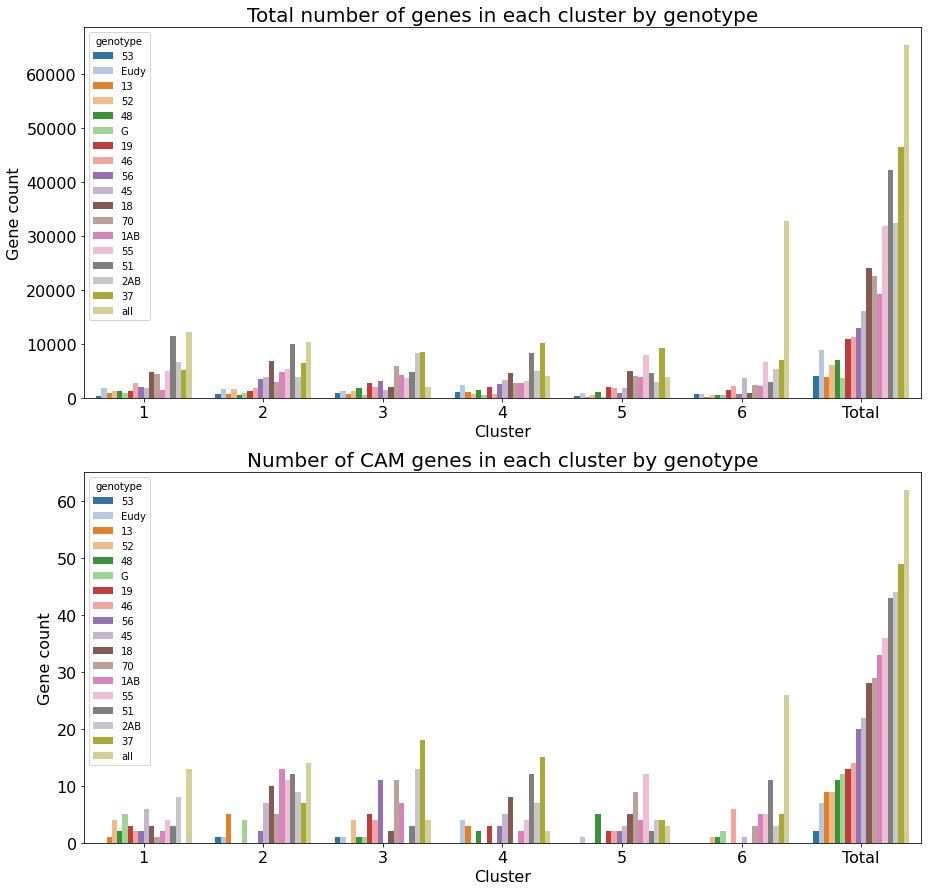

In [156]:
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(15,15))

sns.barplot(ax=ax[0],data=plot,x="cluster",y="n_all_genes",hue="genotype",palette="tab20")
ax[0].set_title("Total number of genes in each cluster by genotype",fontsize=20)
ax[0].tick_params(axis="both",which="major",labelsize=16)
ax[0].set_xlabel("Cluster",fontsize=16)
ax[0].set_ylabel("Gene count",fontsize=16)

sns.barplot(ax=ax[1],data=plot,x="cluster",y="n_CAM_genes",hue="genotype",palette="tab20")
ax[1].set_title("Number of CAM genes in each cluster by genotype",fontsize=20)
ax[1].tick_params(axis="both",which="major",labelsize=16)
ax[1].set_xlabel("Cluster",fontsize=16)
ax[1].set_ylabel("Gene count",fontsize=16)

plt.savefig("./first17genotypes_clustered_genecounts_summary.png",dpi=200,bbox_inches="tight")

## Section 1a: Examine CAM genes in results

In [157]:
allgt["G"].keys()

dict_keys(['clusters', 'CAMgenes', 'all_summary', 'CAM_summary'])

In [164]:
allgt["all"]["CAMgenes"].groupby("gene_abbr").count().reset_index()[["gene_abbr","GeneID"]].to_csv("./tsCAMgenes_summary_allgt.csv",sep=",",header=True,index=False)

In [63]:
allcam = allgt["all"]["CAMgenes"]

In [165]:
allcam["cluster"].unique()

array([2, 1, 3, 4, 5, 6])

In [74]:
allcam[allcam["gene_abbr"]=="bCA5"]

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,cluster
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,2
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,2
38,YufilH1023220m.g,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,6
39,YufilH1042055m.g,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,6


In [171]:
cam53 = allgt["53"]["CAMgenes"]

In [172]:
cam53

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,cluster
0,Yucal.05G072500.v2.1,OG0001083,CAM-dark,phosphoenolpyruvate carboxylase kinase,PPCK,2
1,Yucal.05G072600.v2.1,OG0001083,CAM-dark,phosphoenolpyruvate carboxylase kinase,PPCK,3


In [173]:
cam37 = allgt["37"]["CAMgenes"]

In [175]:
# create a table of CAM genes & save it for later
## step 1: add a genotype column to each CAM genes table
dflist = []
for k,v in allgt.items():
    cdf = v["CAMgenes"]
    cdf["genotype"] = k
    dflist.append(cdf)

In [177]:
all_tscam = pd.concat(dflist)

In [178]:
all_tscam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,cluster,genotype
0,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,6,G
1,Yucal.07G108400.v2.1,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,2,G
2,Yucal.07G108500.v2.1,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,2,G
3,Yucal.03G005000.v2.1,OG0001083,CAM-dark,phosphoenolpyruvate carboxylase kinase,PPCK,2,G
4,Yucal.04G178900.v2.1,OG0001083,CAM-dark,phosphoenolpyruvate carboxylase kinase,PPCK,1,G


In [179]:
all_tscam.to_csv("./timestructured_CAMgenes_cluster_info.txt",sep="\t",header=True,index=False)

## Section 2: Plot cluster expression profiles (TPM)

In [20]:
# define a function to plot a given cluster at a given subplot axis
def plot_profile(c,cpdf,axc,a,tf):
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat")
    lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,lim,where=t>=xthresh,color="gray",alpha=0.3)
    a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=12)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=12)
    a[axc].set_title("Cluster "+str(c),fontsize=tf)

In [6]:
# subset to only certain time points (ZT 1,5,9,13,17,21)
zttpm = mdtpm[mdtpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]
zttpm.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.0,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.0,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.0,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418
5,Y104,1AB,6.0,W,21.0,gloriosa,54.385723,5.745473,0.0,17.707487,...,0.0,1.325587,20.929404,2.159383,7.363694,0.000000,2.504658,15.673893,0.0,0.000000
6,Y105,18,6.0,W,21.0,gloriosa,47.391406,8.458668,0.0,15.536940,...,0.0,7.491513,2.153592,6.520598,14.513037,2.782378,2.331412,20.726688,0.0,0.000000


In [7]:
# fix genotype column
zttpm["genotype"]=zttpm["genotype"].astype(str)
zttpm["genotype"].unique()

/tmp/ipykernel_27384/2298254194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zttpm["genotype"]=zttpm["genotype"].astype(str)


array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [23]:
# make a function to create a plotting dataframe for a given cluster & genotype
def plottpm(tpm,c,gt):
    cinfo = allgt[gt]["clusters"]
    cinfo = cinfo[cinfo["cluster"]==c]
    cgenes = list(cinfo["GeneID"].unique())
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    # subset to just one genotype
    pgt = pwide[pwide["genotype"]==gt]
    plong = pd.melt(pgt,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    return plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)

In [22]:
allgt.keys()

dict_keys(['G', 'Eudy', '13', '45', '19', '51', '2AB', '52', '46', '70', '48', '55', '18', '53', '56', '1AB'])

In [23]:
test = plottpm(zttpm,1,"G")

In [24]:
max(test["TPM"])

3513.278478061611

In [25]:
tsort = test.sort_values(by="TPM",ascending=True)

In [26]:
tsort.head()

,sample_name,genotype,treat,ZT,GeneID,TPM
28079,Y406,G,D,17.0,YufilH1048878m.g,0.0
30824,Y356,G,W,1.0,YufilH1063902m.g,0.0
30825,Y357,G,W,5.0,YufilH1063902m.g,0.0
30826,Y358,G,W,9.0,YufilH1063902m.g,0.0
30827,Y359,G,W,13.0,YufilH1063902m.g,0.0


In [27]:
tsort.tail()

,sample_name,genotype,treat,ZT,GeneID,TPM
8658,Y400,G,D,17.0,Yucal.07G084600.v2.1,2102.375733
8663,Y407,G,D,21.0,Yucal.07G084600.v2.1,2396.601261
8660,Y402,G,D,1.0,Yucal.07G084600.v2.1,2530.168961
8661,Y406,G,D,17.0,Yucal.07G084600.v2.1,2595.396915
16067,Y396,G,D,1.0,Yucal.18G084800.v2.1,3513.278478


In [28]:
# make a function to plot the same cluster for all genotypes
def plot_c_bygt(c,nr,nc,w,h,tpm=zttpm):
    # nr = nrows
    # nc = ncols
    # h = plot height
    # w = plot width
    
    fig,ax = plt.subplots(nrows=nr,ncols=nc,figsize=(w,h))
    
    r=0
    j=0
    
    for g in allgt.keys():
        p = plottpm(tpm,c,g)
        plot_profile(str(c)+", genotype "+g,p,(r,j),ax)
        
        if j!= nc-1:
            j+=1
        else:
            j=0
            r+=1
            
    plt.savefig("./genotype_profile_plots/cluster"+str(c)+"_bygenotype.png",dpi=200,bbox_inches="tight")
    plt.savefig("./genotype_profile_plots/cluster"+str(c)+"_bygenotype.pdf",dpi=200,bbox_inches="tight")
    plt.savefig("./genotype_profile_plots/cluster"+str(c)+"_bygenotype.svg",dpi=200,bbox_inches="tight")

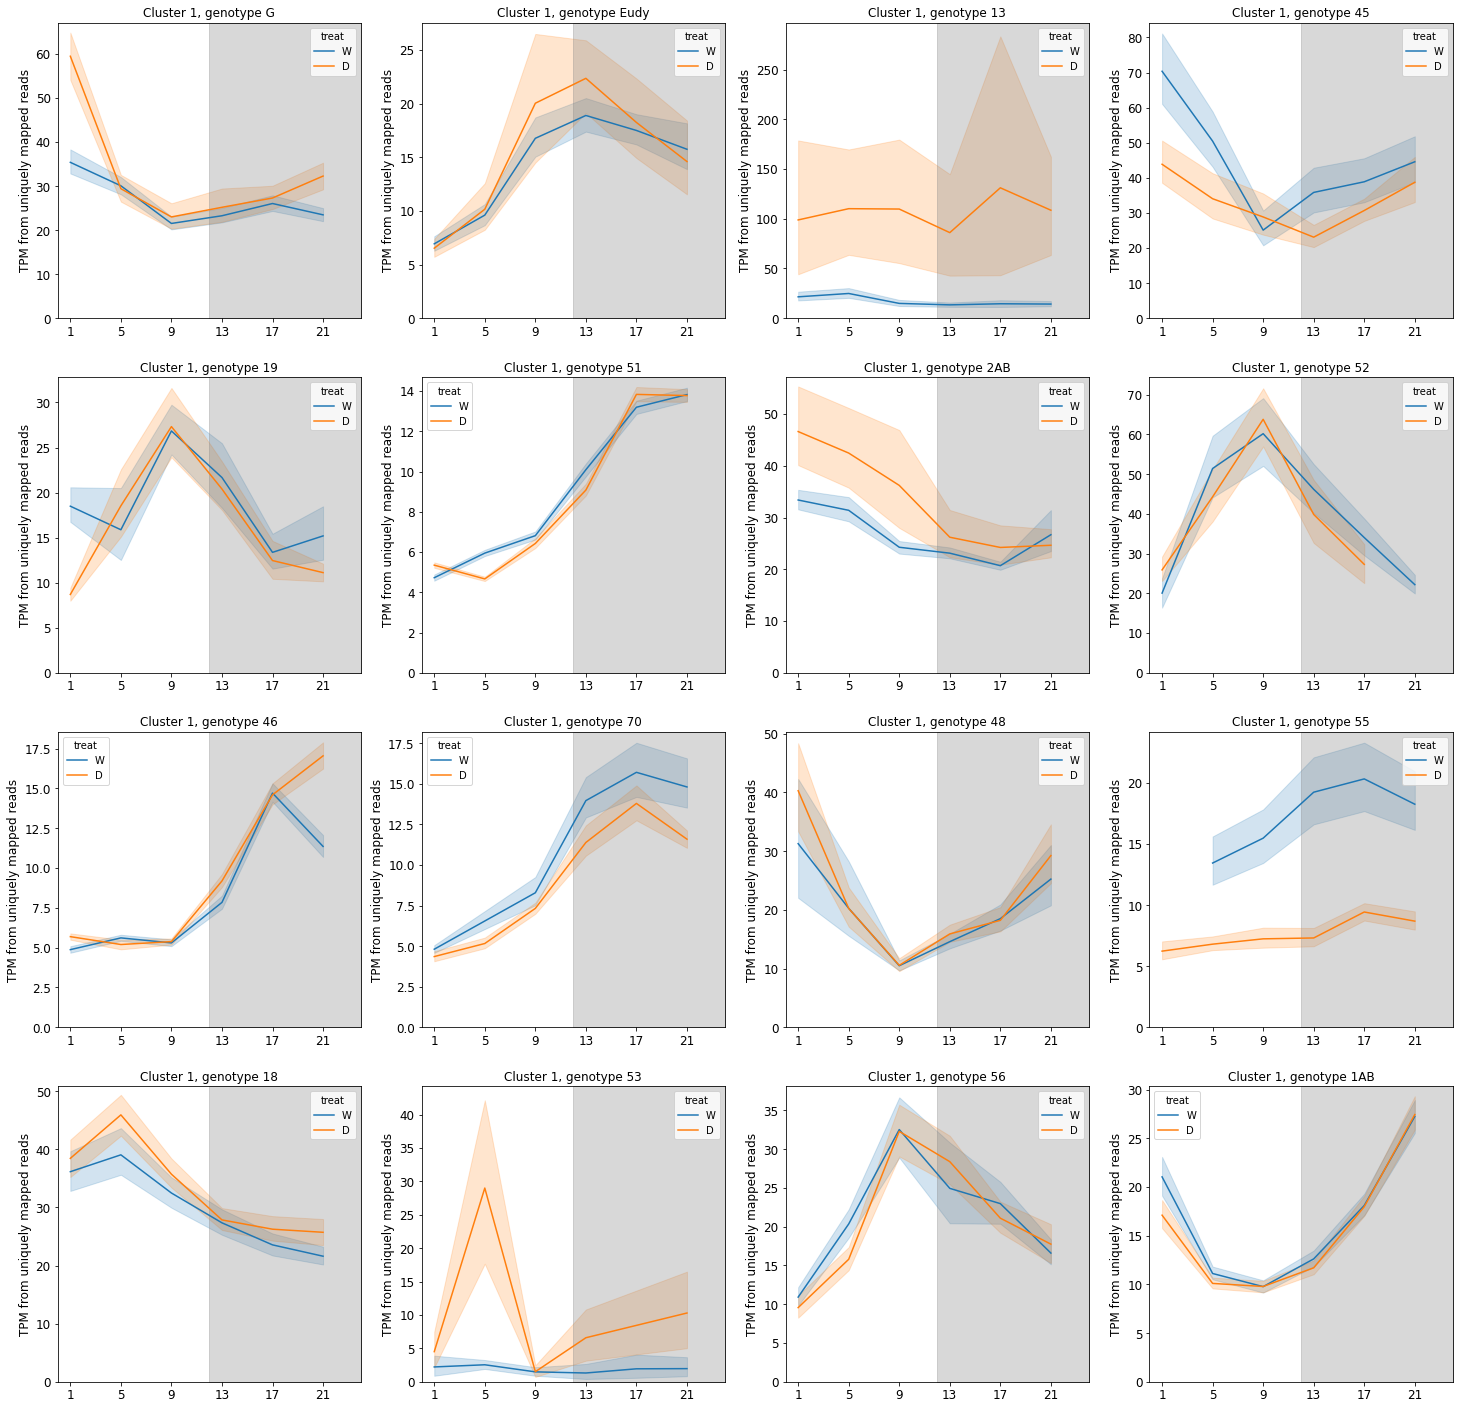

In [29]:
plot_c_bygt(1,nr=4,nc=4,w=25,h=25)

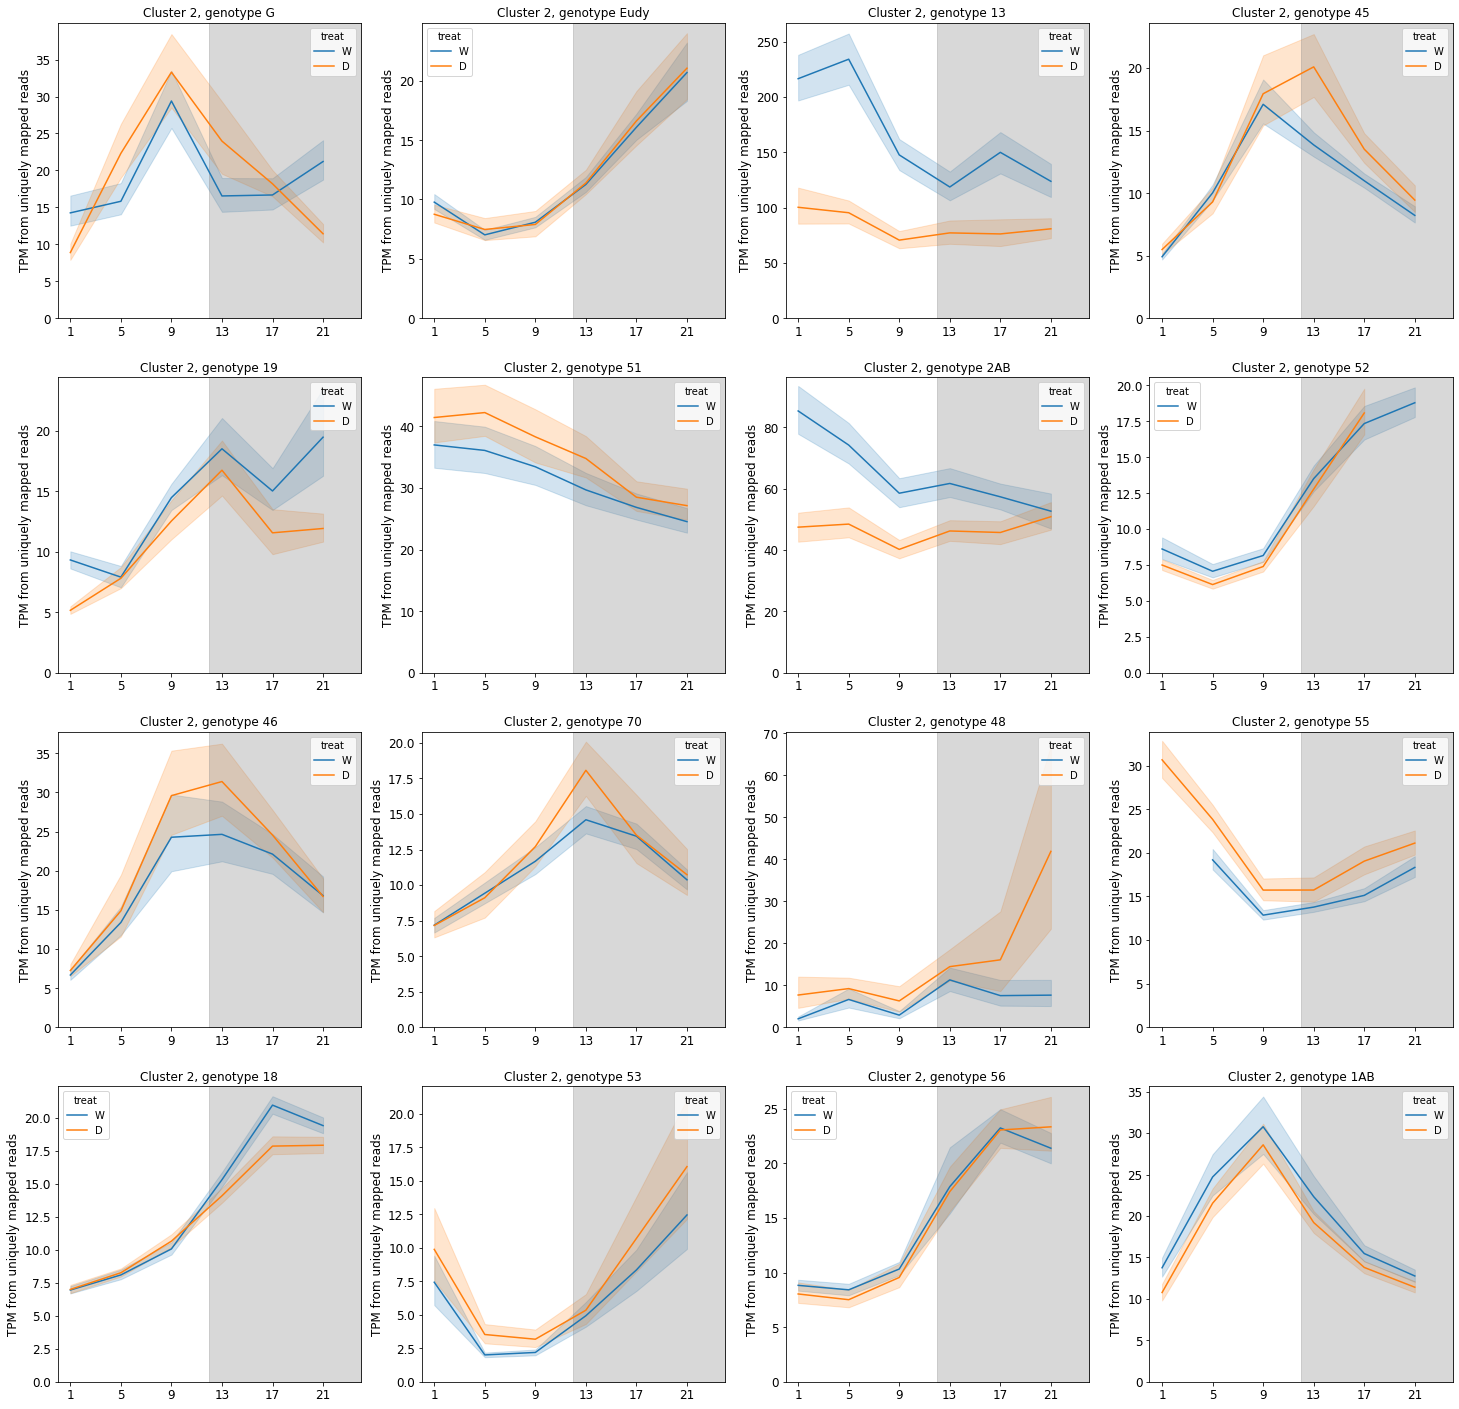

In [30]:
plot_c_bygt(2,nr=4,nc=4,w=25,h=25)

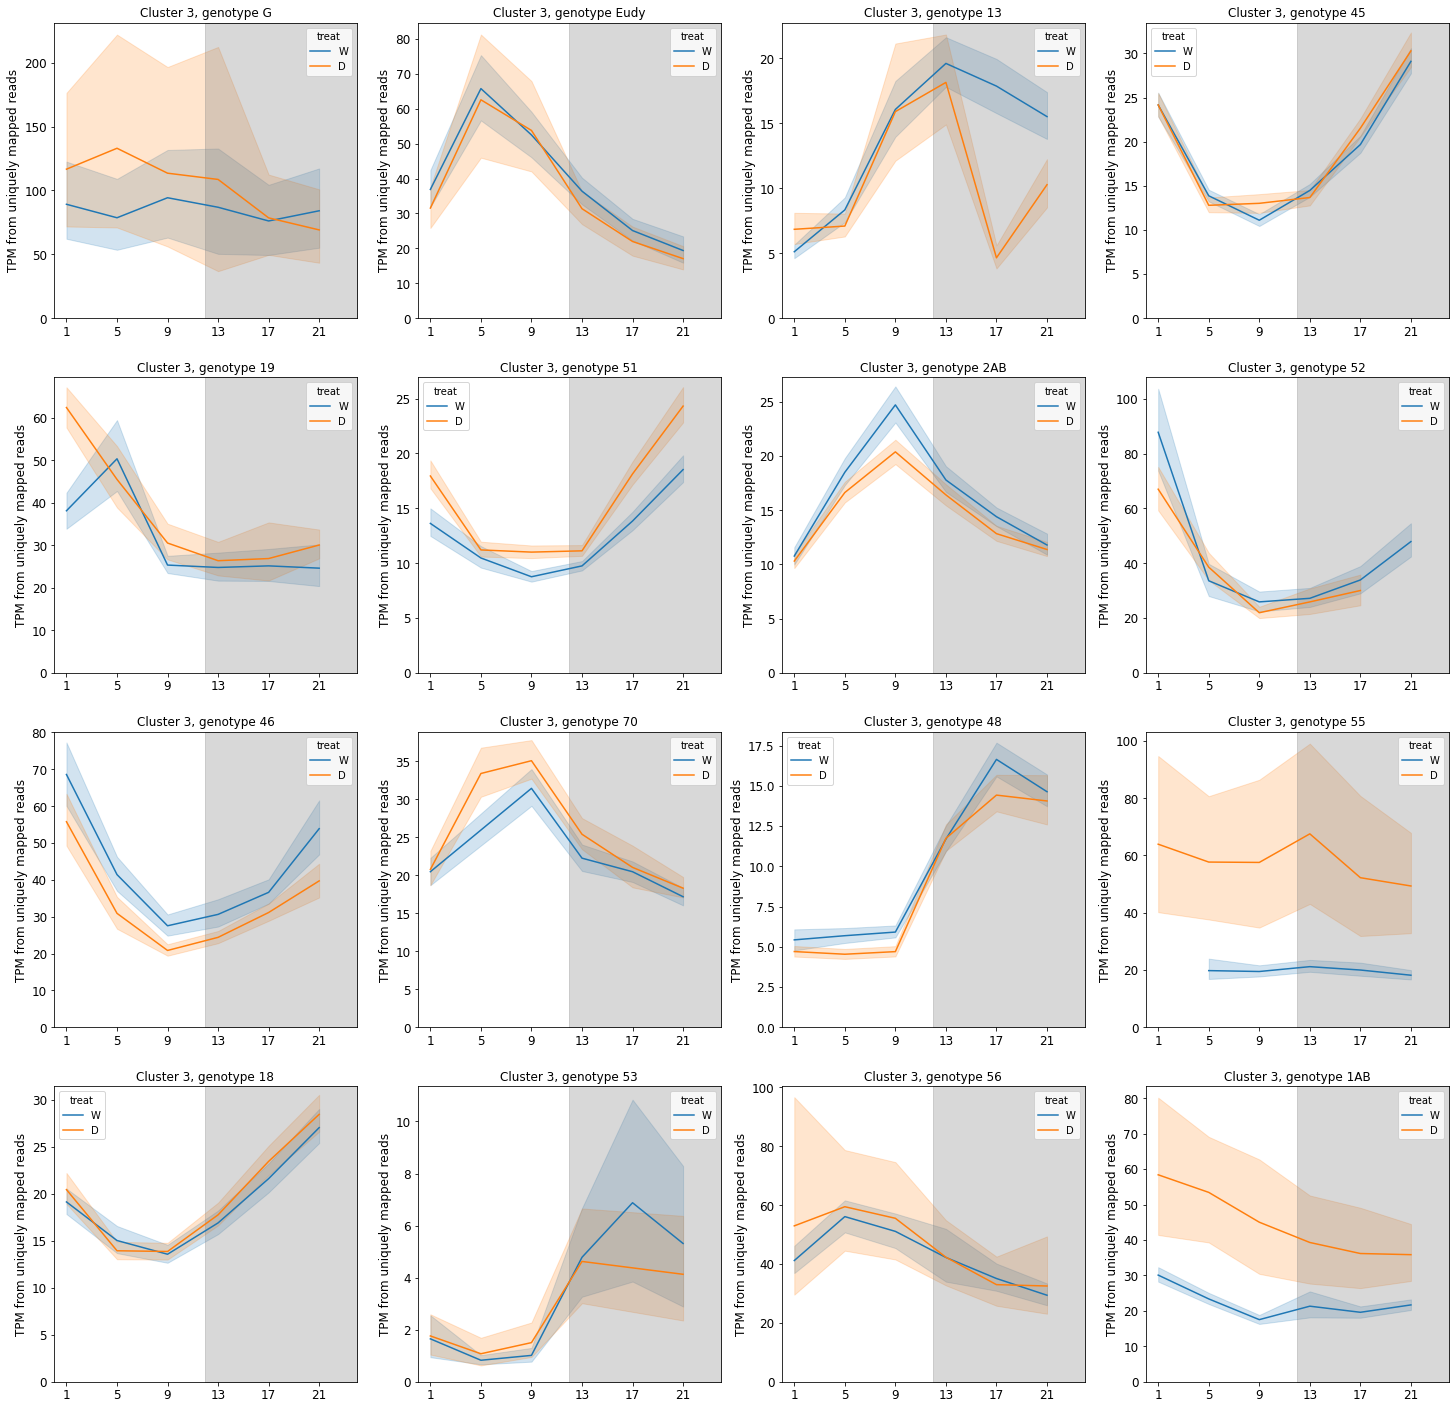

In [31]:
plot_c_bygt(3,nr=4,nc=4,w=25,h=25)

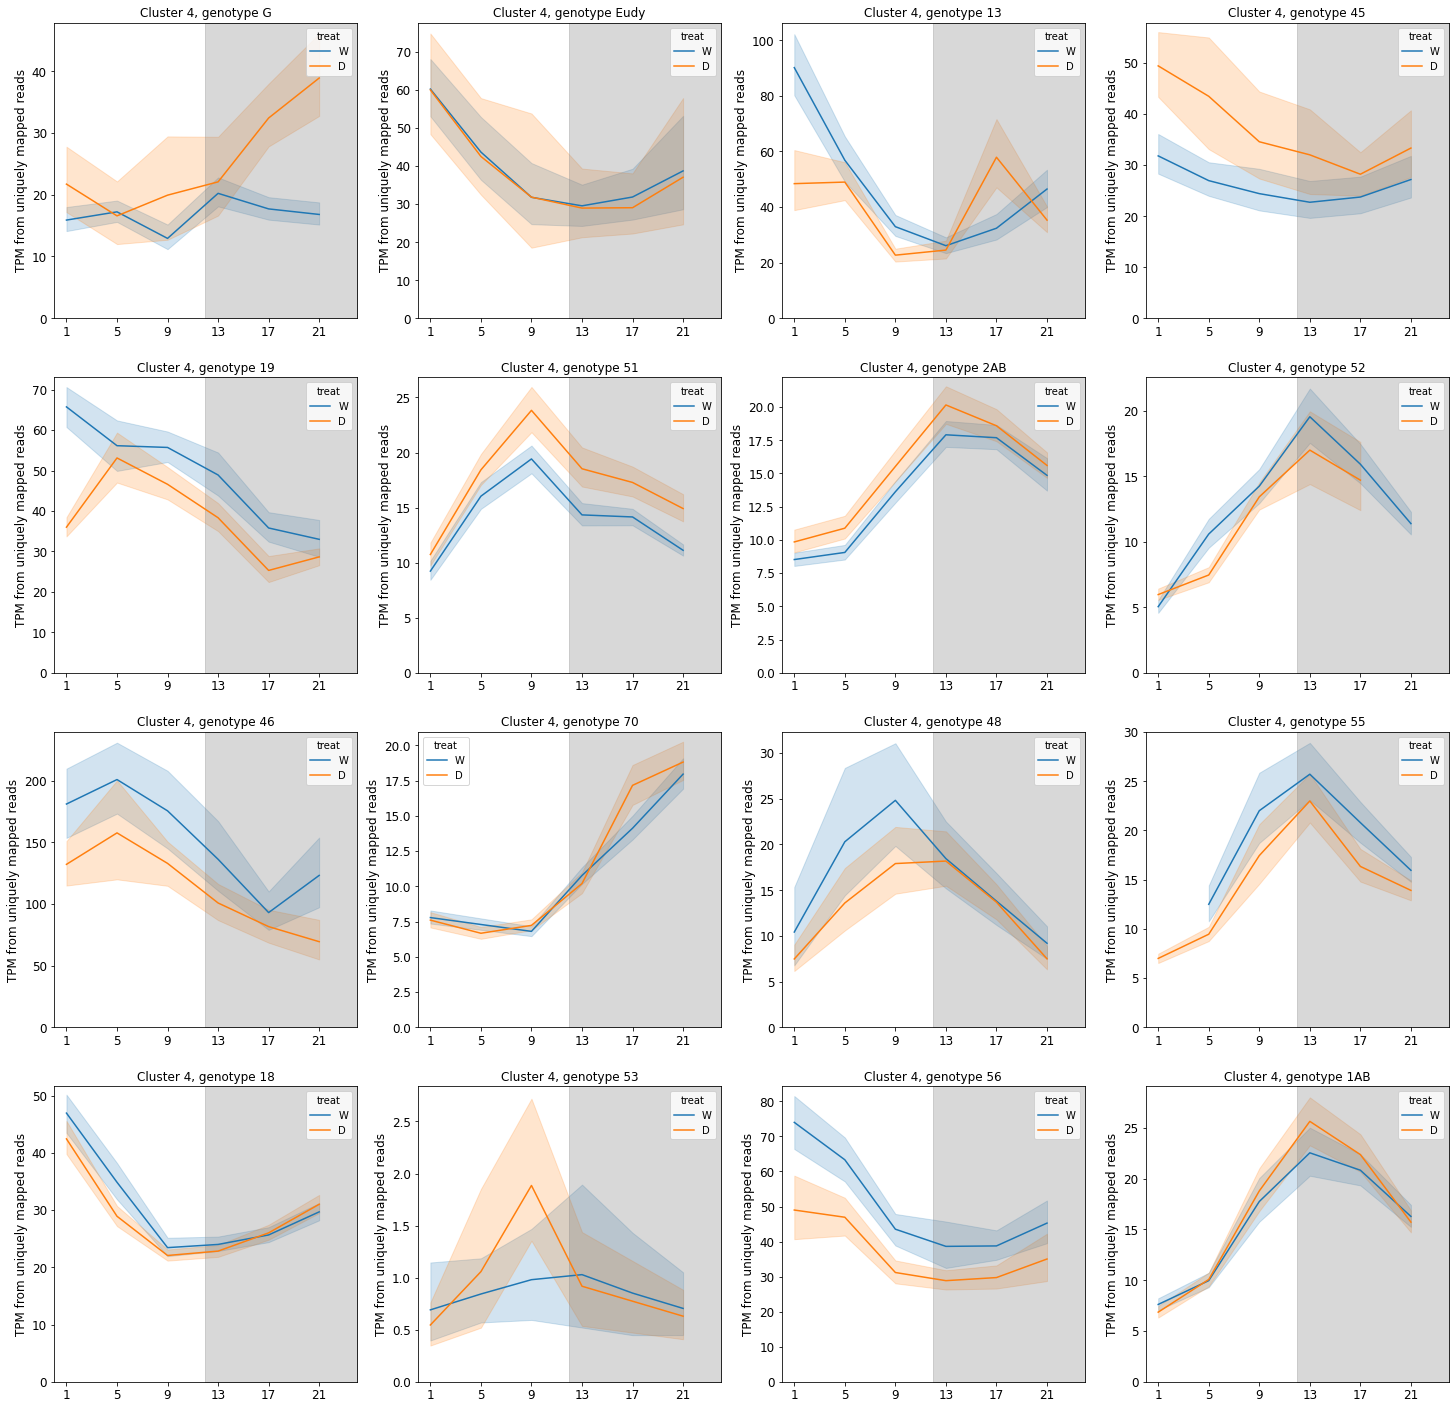

In [32]:
plot_c_bygt(4,nr=4,nc=4,w=25,h=25)

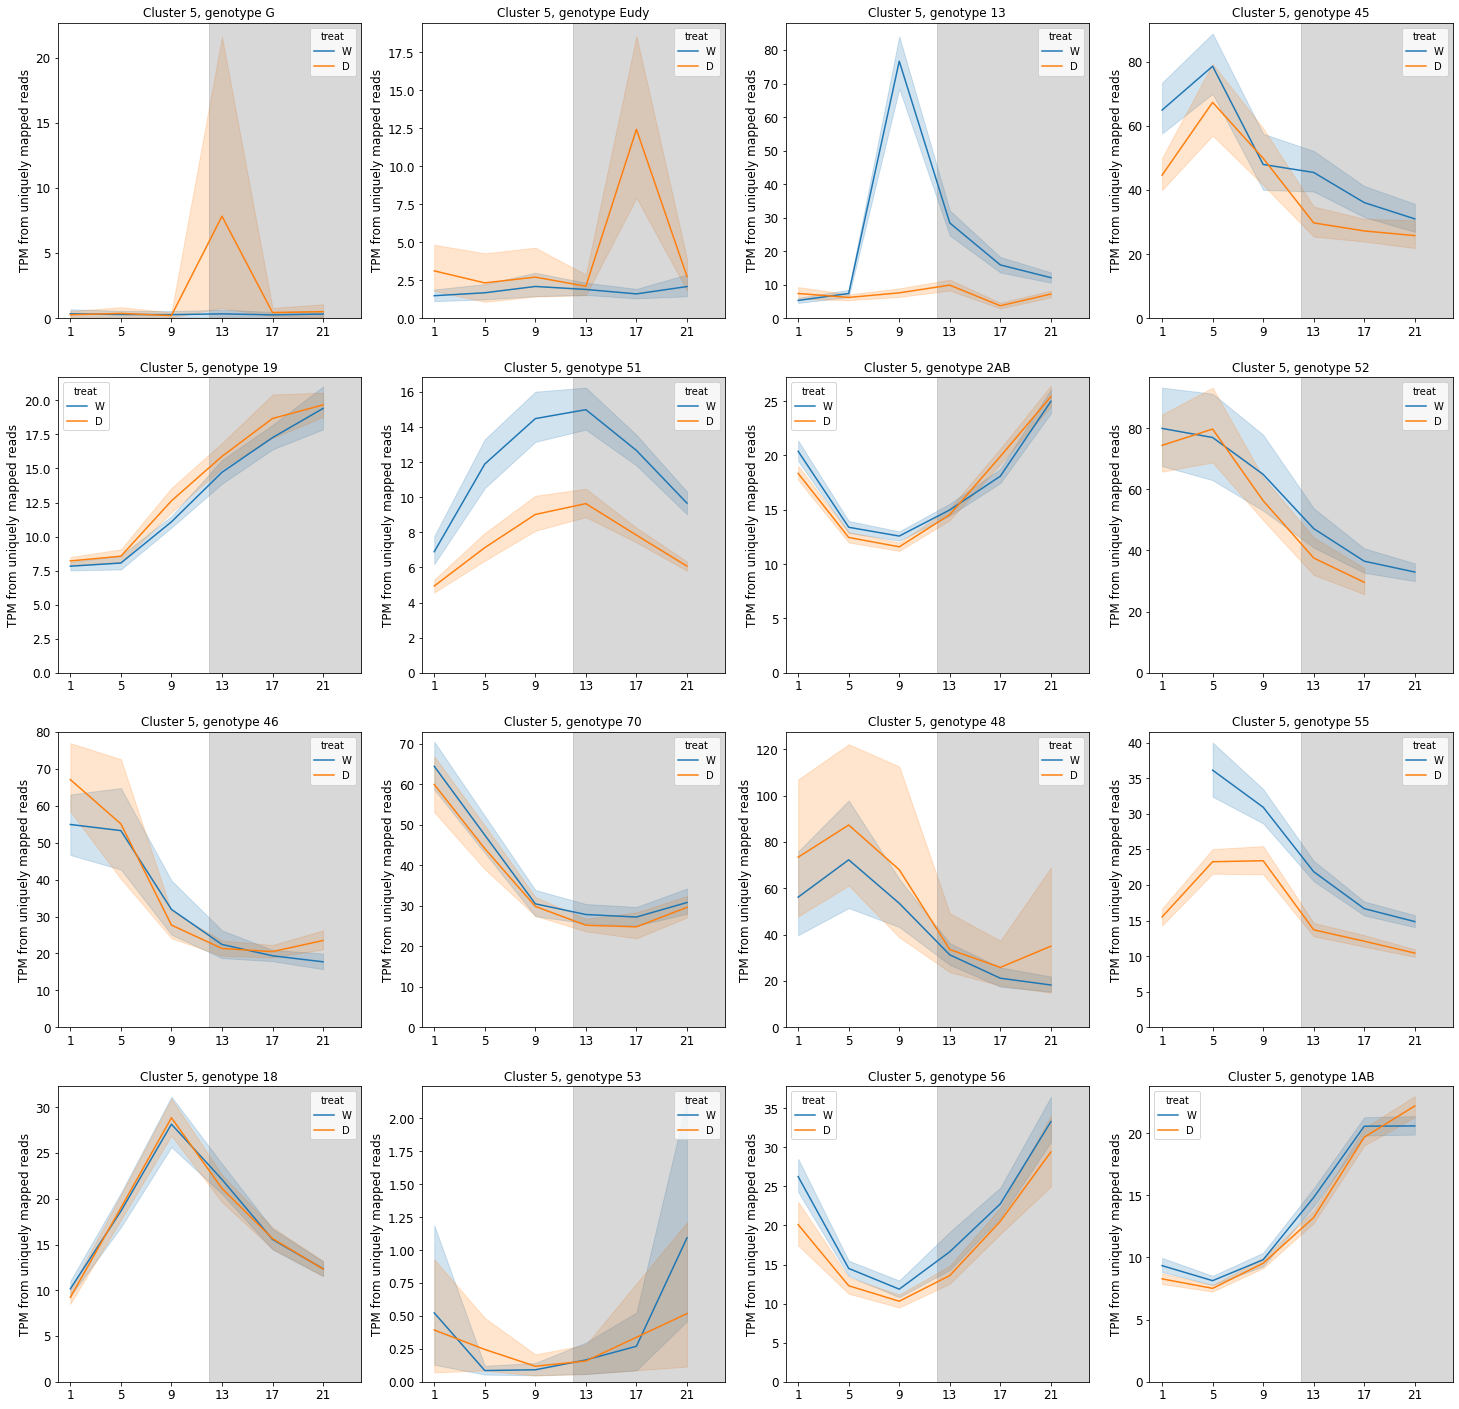

In [33]:
plot_c_bygt(5,nr=4,nc=4,w=25,h=25)

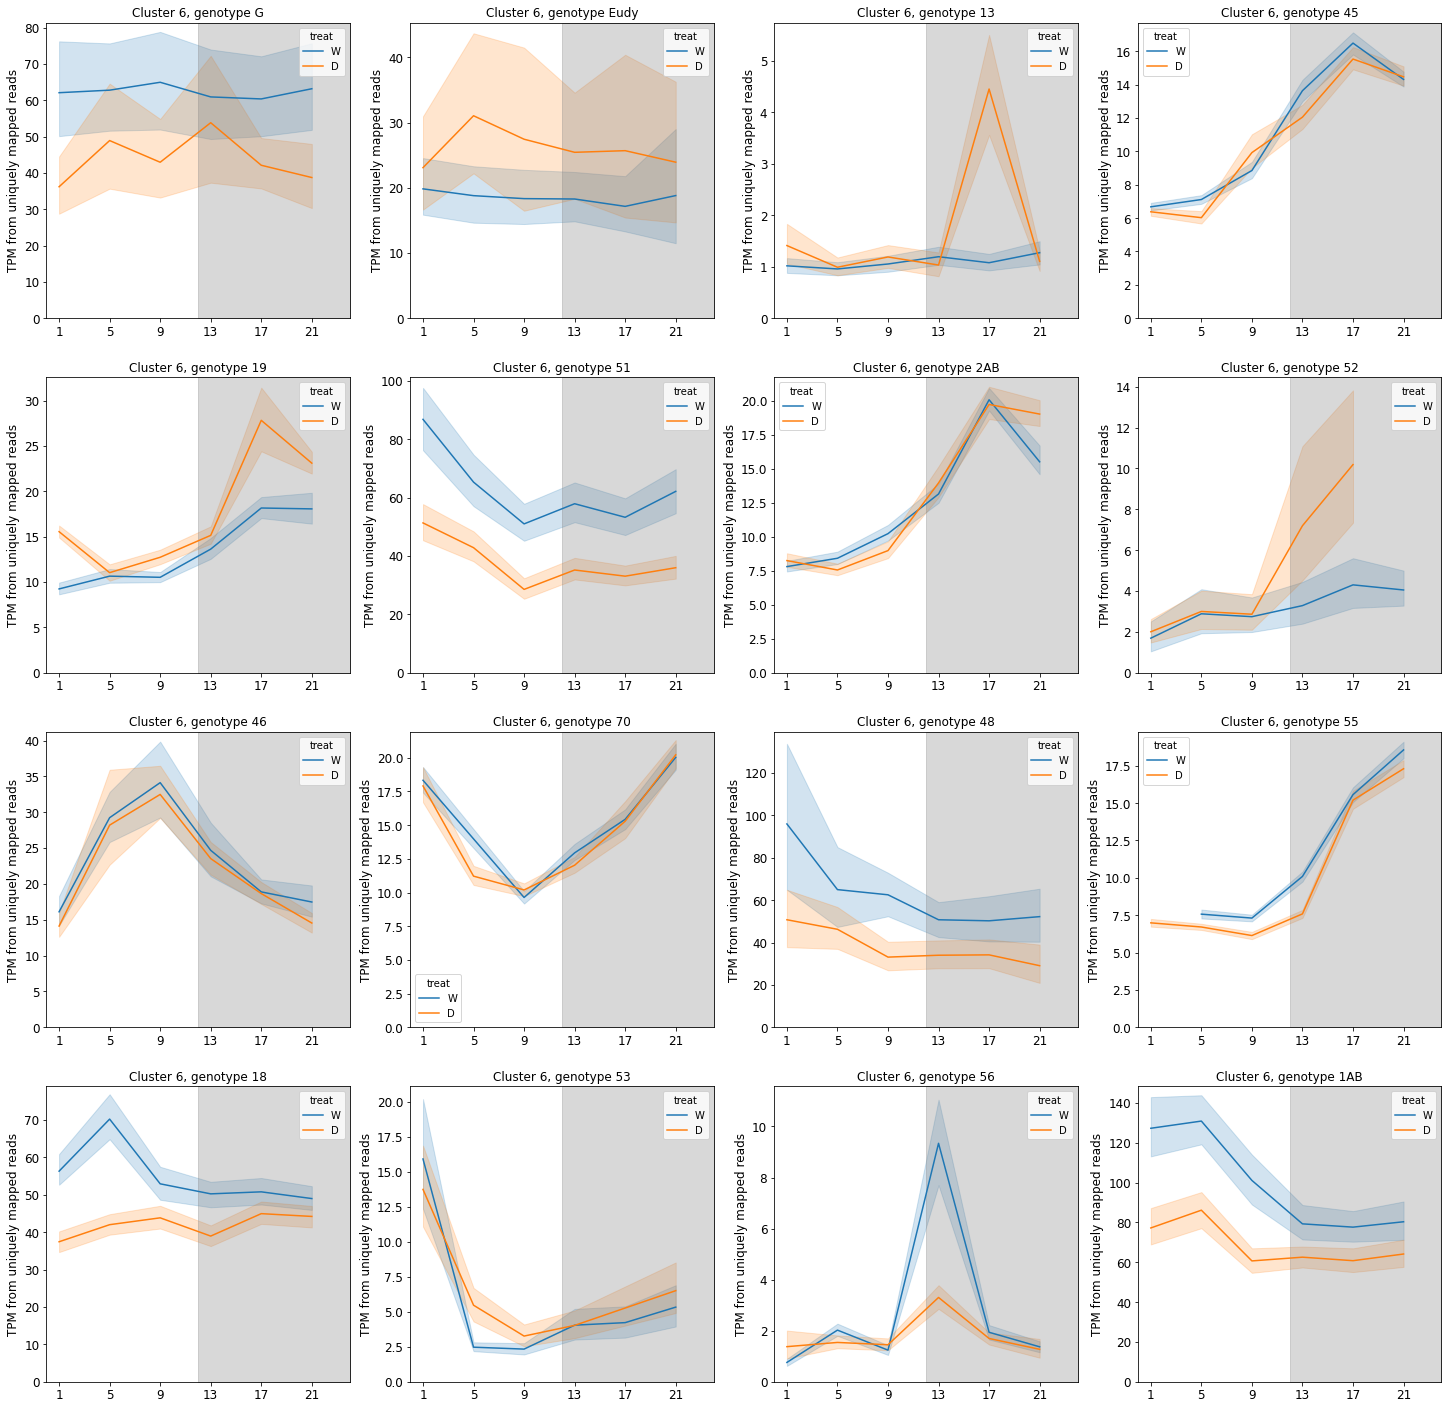

In [34]:
plot_c_bygt(6,nr=4,nc=4,w=25,h=25)

## Section 3: Find clusters that are similar across all genotypes

In [17]:
zttpm.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.0,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.0,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.0,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418
5,Y104,1AB,6.0,W,21.0,gloriosa,54.385723,5.745473,0.0,17.707487,...,0.0,1.325587,20.929404,2.159383,7.363694,0.000000,2.504658,15.673893,0.0,0.000000
6,Y105,18,6.0,W,21.0,gloriosa,47.391406,8.458668,0.0,15.536940,...,0.0,7.491513,2.153592,6.520598,14.513037,2.782378,2.331412,20.726688,0.0,0.000000


In [49]:
test.head()

,sample_name,genotype,treat,ZT,GeneID,TPM
0,Y1,18,W,1.0,Yucal.01G000100.v2.1,34.002815
88828,Y57,18,W,13.0,YufilH1006446m.g,0.441926
88852,Y19,18,W,5.0,YufilH1006548m.g,0.000000
88837,Y105,18,W,21.0,YufilH1006548m.g,0.490587
88836,Y1,18,W,1.0,YufilH1006548m.g,0.081737


In [48]:
t = test.groupby(["treat","ZT"]).mean().reset_index()
t

,treat,ZT,TPM
0,D,1.0,38.450841
1,D,5.0,45.934668
2,D,9.0,35.728250
3,D,13.0,27.858302
4,D,17.0,26.260219
5,D,21.0,25.727165
6,W,1.0,36.157863
7,W,5.0,39.057208
8,W,9.0,32.486539
9,W,13.0,27.353461


In [52]:
max(t["TPM"])

45.93466799115555

In [24]:
## start by finding clusters where expression peaks at the same time point
# for each cluster in each genotype: find the peak expression ZT for W and for D
def peaktpm(c,gt,tpm=zttpm):
    df = plottpm(tpm,c,gt)
    mdf = df.groupby(["treat","ZT"]).mean().reset_index()
    dfd = {"treat":[],"ZT":[],"meanTPM":[],"genotype":[],"cluster":[]}
    for i in ["D","W"]:
        dfd["treat"].append(i)
        tdf = mdf[mdf["treat"]==i]
        maxtdf = tdf[tdf["TPM"]==max(tdf["TPM"])]
        dfd["ZT"].append(maxtdf.iloc[0,1])
        dfd["meanTPM"].append(maxtdf.iloc[0,2])
        dfd["genotype"].append(gt)
        dfd["cluster"].append(c)
    return pd.DataFrame(dfd)

In [25]:
dflist = []
for i in range(1,7):
    for j in allgt.keys():
        dflist.append(peaktpm(i,j))

ValueError: max() arg is an empty sequence

In [55]:
allpeaks = pd.concat(dflist)

In [56]:
allpeaks.sort_values(by="ZT",inplace=True)

In [57]:
allpeaks.head()

,treat,ZT,meanTPM,genotype,cluster
0,D,1.0,59.489284,G,1
1,W,1.0,85.356752,2AB,2
0,D,1.0,30.670179,55,2
0,D,1.0,62.445286,19,3
0,D,1.0,67.028468,52,3


In [58]:
dpeaks = allpeaks[allpeaks["treat"]=="D"].sort_values(by="ZT")
wpeaks = allpeaks[allpeaks["treat"]=="W"].sort_values(by="ZT")

In [60]:
allpeaks["ZT"].unique()

array([ 1.,  5.,  9., 13., 17., 21.])

In [61]:
dpeaks["ZT"].unique()

array([ 1.,  5.,  9., 13., 17., 21.])

In [62]:
wpeaks["ZT"].unique()

array([ 1.,  5.,  9., 13., 17., 21.])

In [64]:
# for each treatment, make a dict where key=ZT, value={genotype:cluster} dict (indicating the cluster with a peak at that ZT)
def ztclusters(maxdf,zt):
    ztdf = maxdf[maxdf["ZT"]==zt]
    d = {}
    for i in range(len(ztdf.index)):
        d[ztdf.iloc[i,3]] = ztdf.iloc[i,4]
    return d

In [65]:
clusters_by_peak = {}
for i in ["W","D"]:
    df = allpeaks[allpeaks["treat"]==i]
    clusters_by_peak[i] = {}
    for z in df["ZT"].unique():
        clusters_by_peak[i][z] = ztclusters(df,z)

In [66]:
clusters_by_peak

{'W': {1.0: {'2AB': 1,
   '52': 5,
   '46': 5,
   'Eudy': 6,
   '13': 4,
   '45': 1,
   '19': 4,
   '18': 4,
   '53': 6,
   '48': 1,
   '51': 2,
   'G': 1,
   '56': 4,
   '70': 5,
   '1AB': 3},
  5.0: {'19': 3,
   '53': 1,
   '18': 6,
   '56': 3,
   '46': 4,
   'Eudy': 3,
   '45': 5,
   '48': 5,
   '55': 2,
   '13': 2,
   '1AB': 6},
  9.0: {'48': 4,
   '19': 1,
   '13': 5,
   'Eudy': 5,
   '51': 4,
   '52': 1,
   '18': 5,
   'G': 2,
   '70': 3,
   '56': 1,
   '1AB': 2,
   '46': 6,
   '2AB': 3,
   '45': 2},
  13.0: {'55': 3,
   '53': 4,
   '56': 6,
   '46': 2,
   'Eudy': 1,
   '51': 5,
   '1AB': 4,
   '48': 2,
   '70': 2,
   '2AB': 4,
   '13': 3,
   '52': 4,
   'G': 4},
  17.0: {'53': 3,
   '18': 2,
   '52': 6,
   '45': 6,
   '19': 6,
   '48': 3,
   '2AB': 6,
   '55': 1,
   '46': 1,
   '70': 1,
   '56': 2},
  21.0: {'70': 4,
   '45': 3,
   '55': 6,
   '51': 1,
   '53': 5,
   '19': 5,
   '52': 2,
   '2AB': 5,
   '1AB': 5,
   '18': 3,
   '56': 5,
   '13': 6,
   'Eudy': 2}},
 'D': {1.0: {'

In [67]:
# also make a similar dict for total maximum, regardless of treatment
cbypeak_all = {}
for z in allpeaks["ZT"].unique():
    cbypeak_all[z] = ztclusters(allpeaks,z)

In [68]:
cbypeak_all

{1.0: {'G': 1,
  '2AB': 1,
  '55': 2,
  '19': 4,
  '52': 5,
  '46': 5,
  '1AB': 3,
  'Eudy': 6,
  '13': 2,
  '45': 1,
  '18': 4,
  '56': 4,
  '53': 6,
  '48': 1,
  '51': 2,
  '70': 5},
 5.0: {'19': 4,
  '53': 1,
  '18': 6,
  '56': 3,
  '1AB': 6,
  '46': 4,
  'Eudy': 3,
  '45': 5,
  '52': 5,
  '48': 5,
  '55': 2,
  '13': 2,
  '51': 2,
  'G': 3},
 9.0: {'18': 5,
  '48': 4,
  '55': 5,
  'G': 2,
  '19': 1,
  '13': 5,
  'Eudy': 5,
  '52': 1,
  '51': 4,
  '53': 4,
  '70': 3,
  '56': 1,
  '1AB': 2,
  '46': 6,
  '2AB': 3,
  '45': 2},
 13.0: {'55': 3,
  '53': 3,
  '56': 6,
  '1AB': 4,
  '13': 3,
  'Eudy': 1,
  '46': 2,
  '19': 2,
  '51': 5,
  '45': 2,
  'G': 4,
  '48': 2,
  '70': 2,
  '2AB': 4,
  '52': 4},
 17.0: {'52': 2,
  '53': 3,
  '18': 6,
  '45': 6,
  '2AB': 6,
  '19': 6,
  '51': 1,
  '48': 3,
  '13': 1,
  '55': 1,
  '46': 1,
  '70': 1,
  'Eudy': 5,
  '56': 2},
 21.0: {'45': 3,
  '53': 5,
  '70': 4,
  '55': 6,
  '56': 5,
  '51': 1,
  '19': 5,
  'Eudy': 2,
  '46': 1,
  '48': 2,
  '52': 2,


In [151]:
# make a function to plot these sets of clusters together (to confirm their similarity)
def plot_set_profile(d,zt,treatment="all",tpm=zttpm):
    ## things to set up based on parameters:
    # nr = nrows
    # nc = ncols
    # h = plot height
    # w = plot width
    
    # argument: treatment can be equal to "None", "W", or "D"
    
    
    # set up nr & nc
    setdict = d[zt]
    nplots = len(setdict.keys())
    if nplots % 4 == 0:
        nc = 4
        nr = int(nplots/4)
    else:
        if nplots % 3 == 0:
            nc = 3
            nr = int(nplots/3)
        else:
            nc = 3
            nr = int((nplots/3)+1)
            
    # set up w & h depending on nc & nr
    w = 10*nc
    h = 10*nr
    # set up font sizes depending on nc & nr
    if nc==4:
        stf = 36
        tf = 24
    else:
        stf = 26
        tf = 20
    
    fig,ax = plt.subplots(nrows=nr,ncols=nc,figsize=(w,h))
    
    r=0
    j=0
    
    # plot each cluster from setdict
    for g,c in setdict.items():
        p=plottpm(tpm,c,g)
        plot_profile(str(c)+", genotype "+g,p,(r,j),ax,tf)
        
        if j!= nc-1:
            j+=1
        else:
            j=0
            r+=1
            
    # remove extraneous empty plot axes
    if nplots!=(nr*nc):
        fig.delaxes(ax[nr-1,nc-1])
        if (nr*nc)-nplots==2:
            fig.delaxes(ax[nr-1,nc-2])
            
    # set up the suptitle
    if treatment=="all":
        st = "Clusters with maximum average expression at ZT "+str(zt)
    else:
        st = "Clusters with maximum average expression ("+treatment+") at ZT"+str(zt)
    plt.suptitle(st,fontsize=stf,y=0.915)
    
    filename = "./genotype_profile_plots/profmaxnew"+treatment+"_ZT"+str(zt)
    plt.savefig(filename+".png",dpi=200,bbox_inches="tight")
    plt.savefig(filename+".pdf",dpi=200,bbox_inches="tight")
    plt.savefig(filename+".svg",dpi=200,bbox_inches="tight")

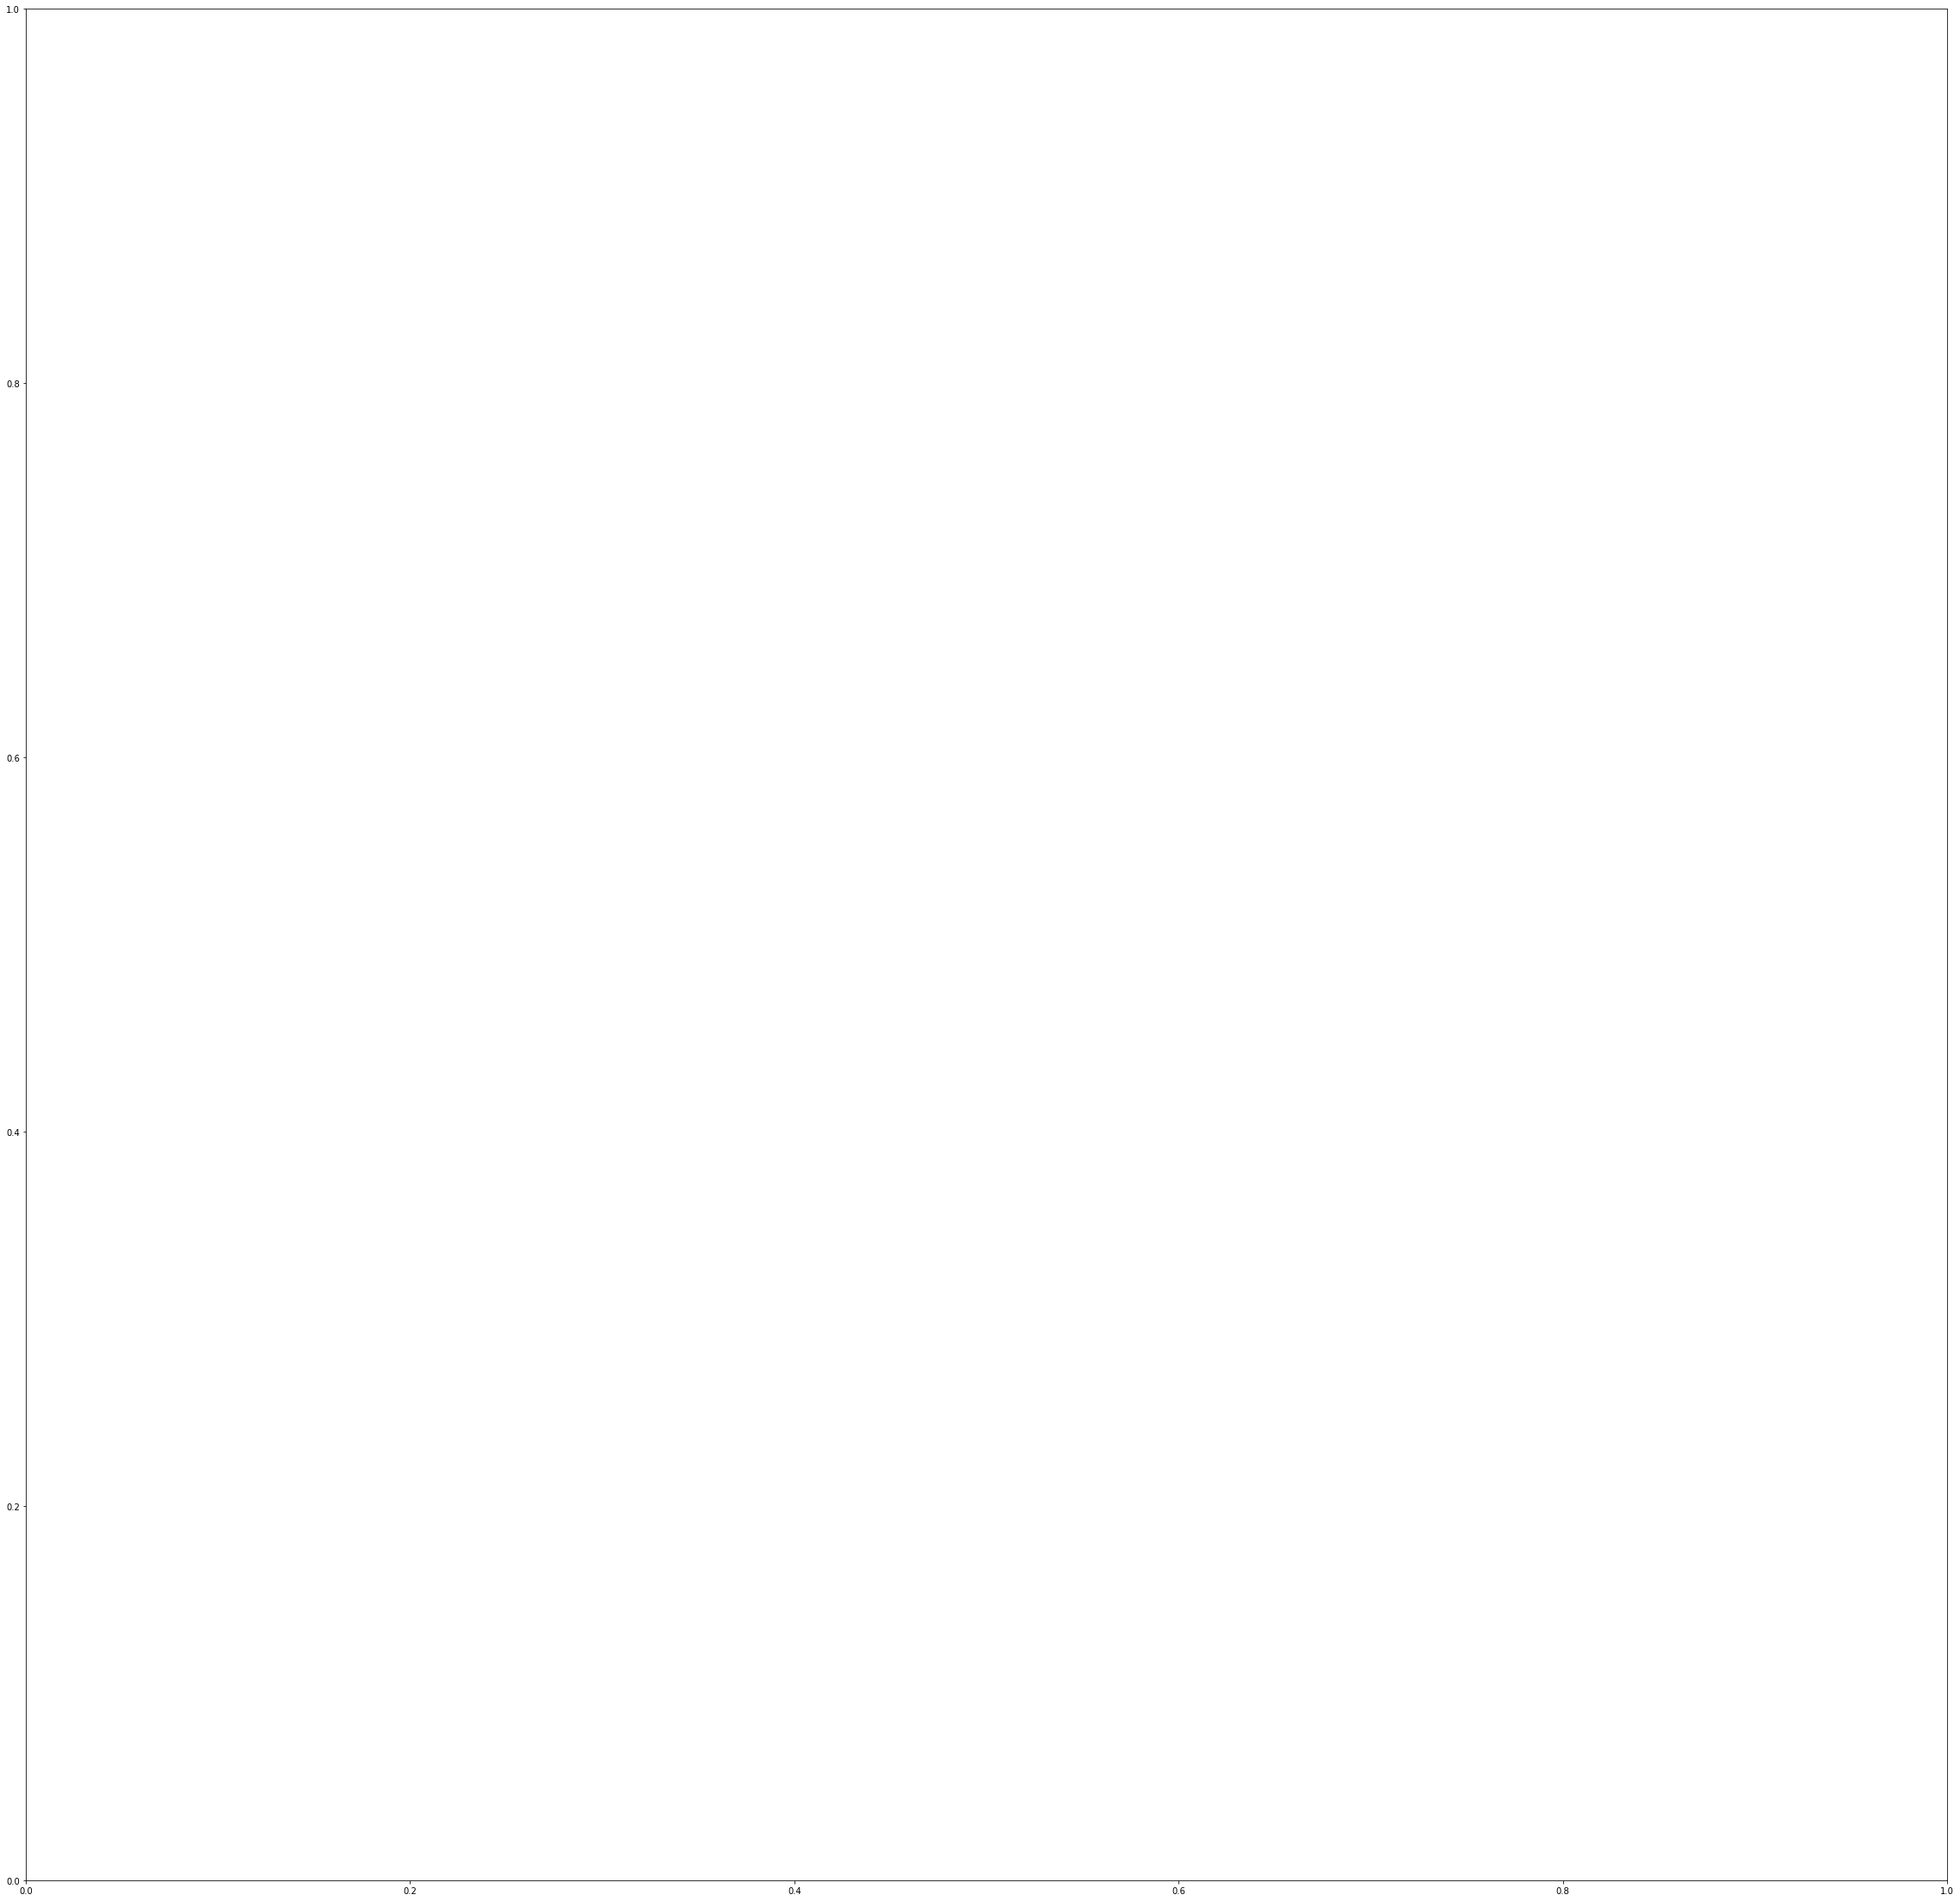

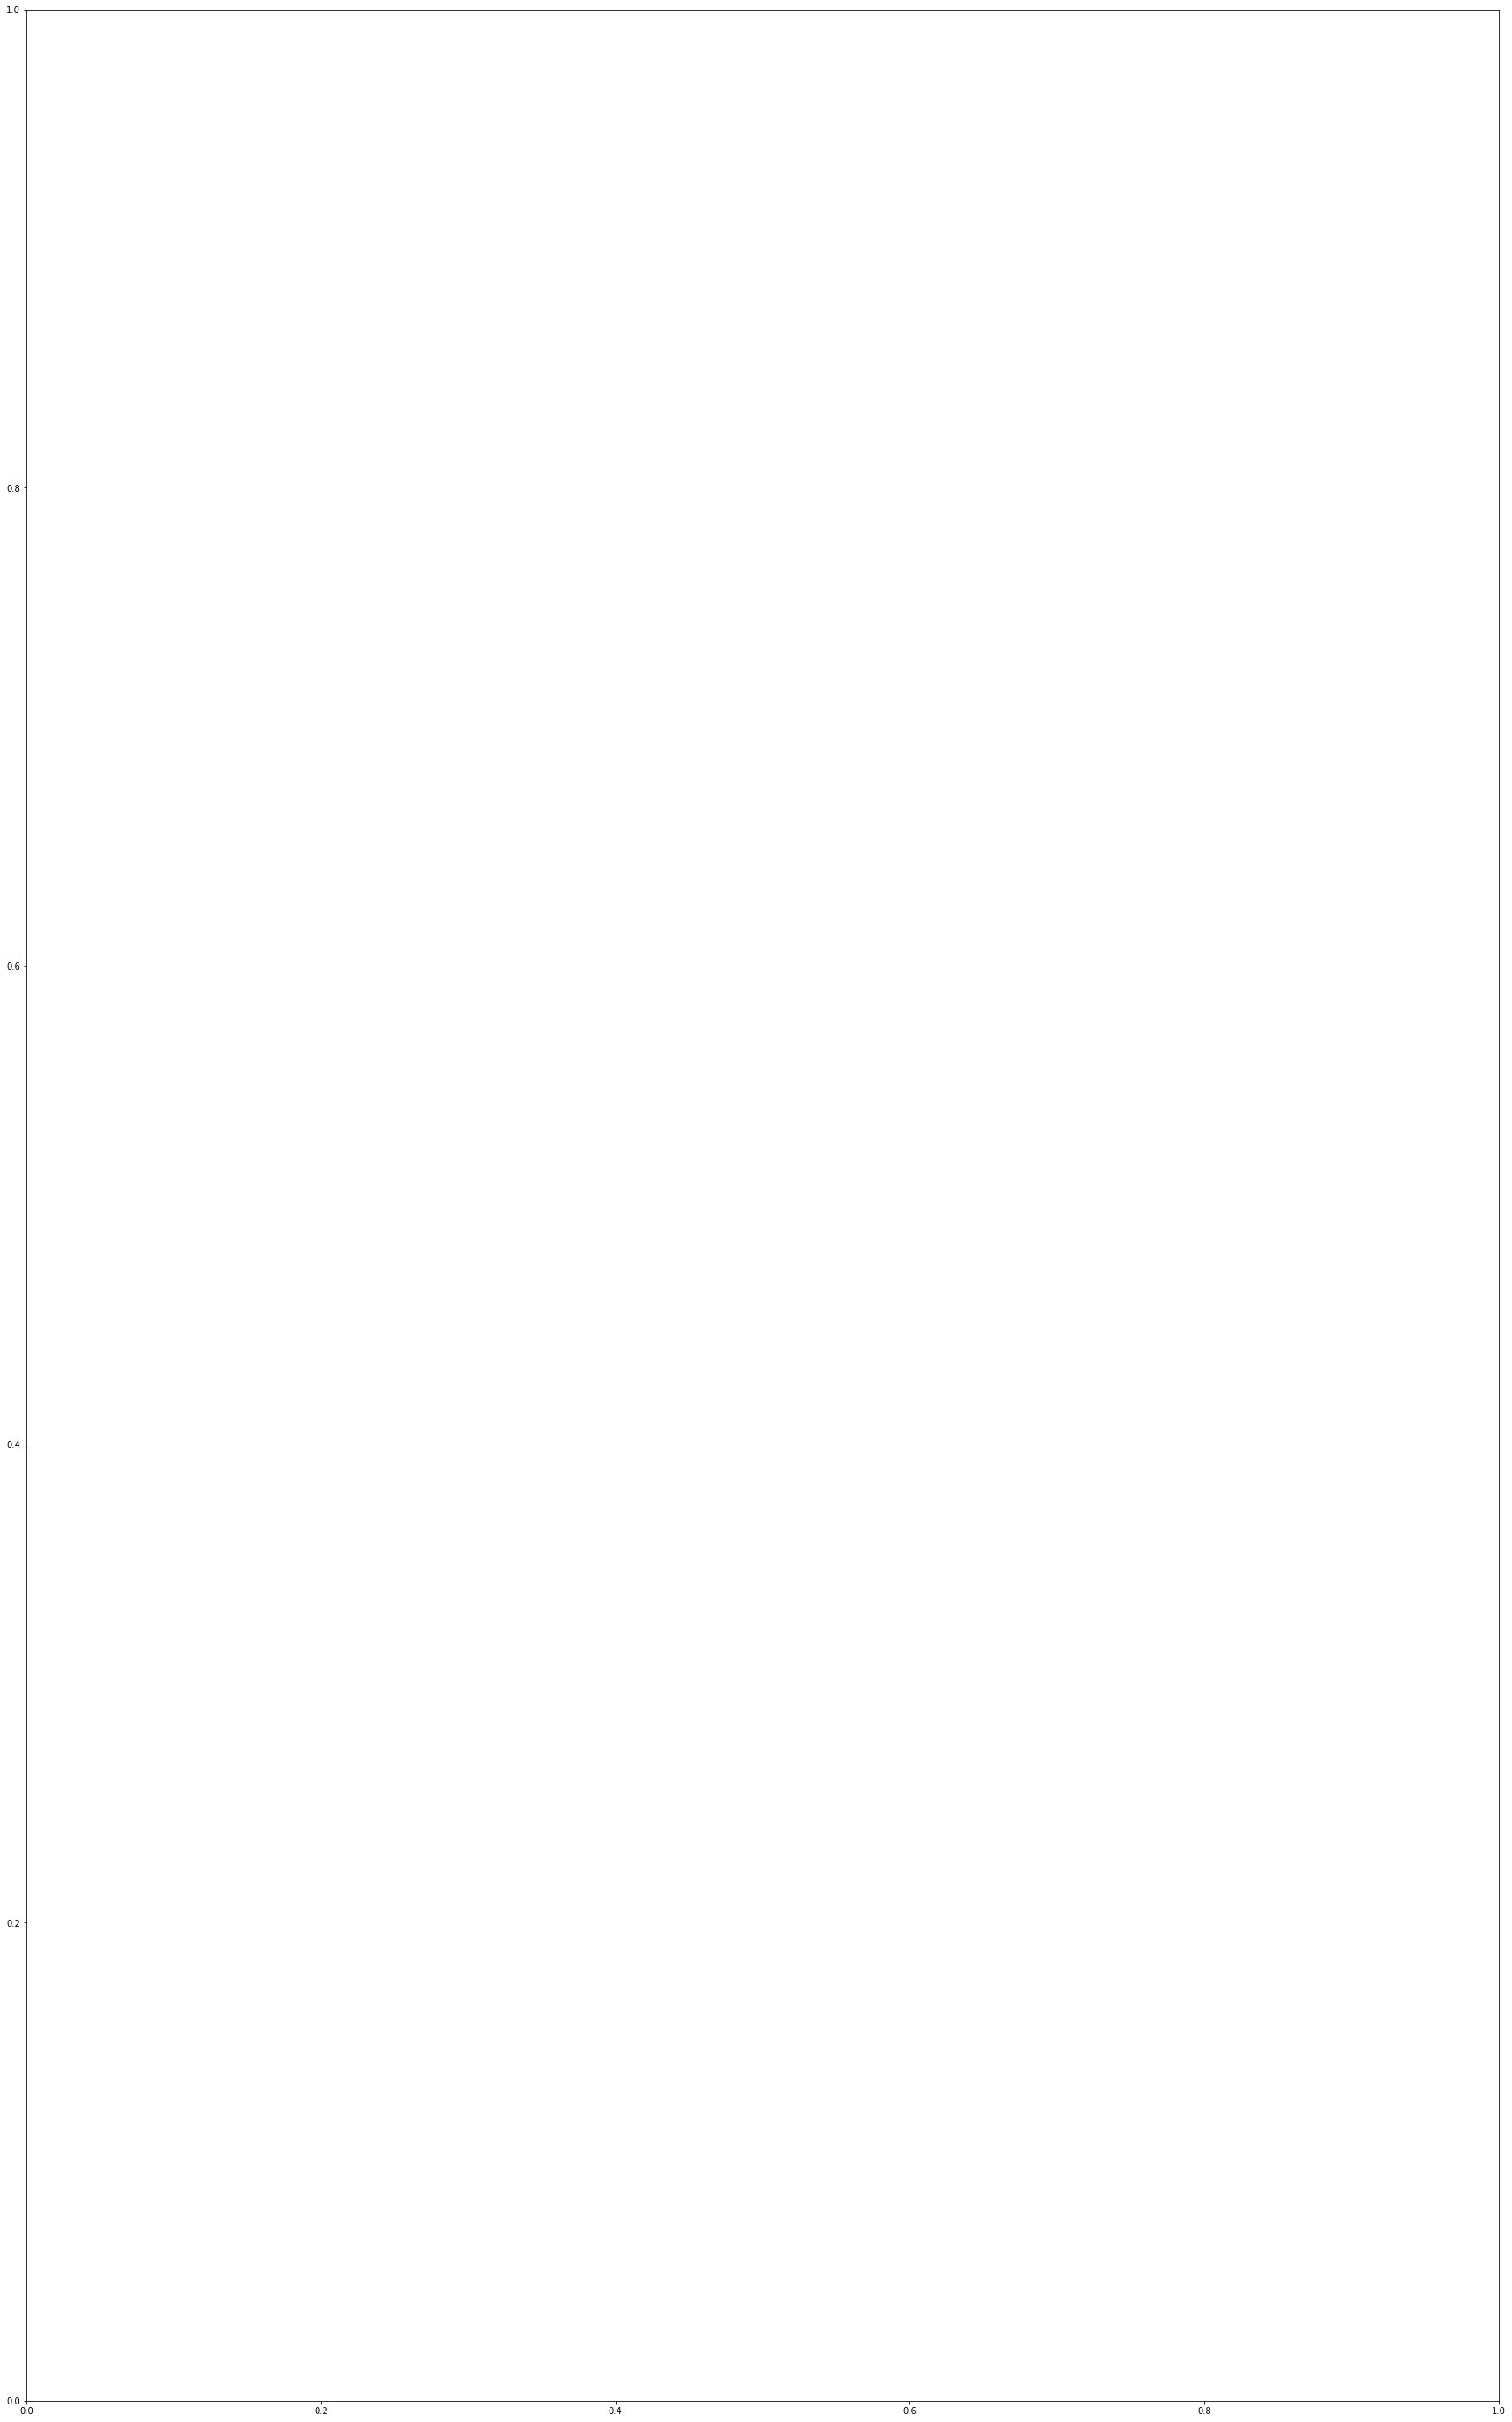

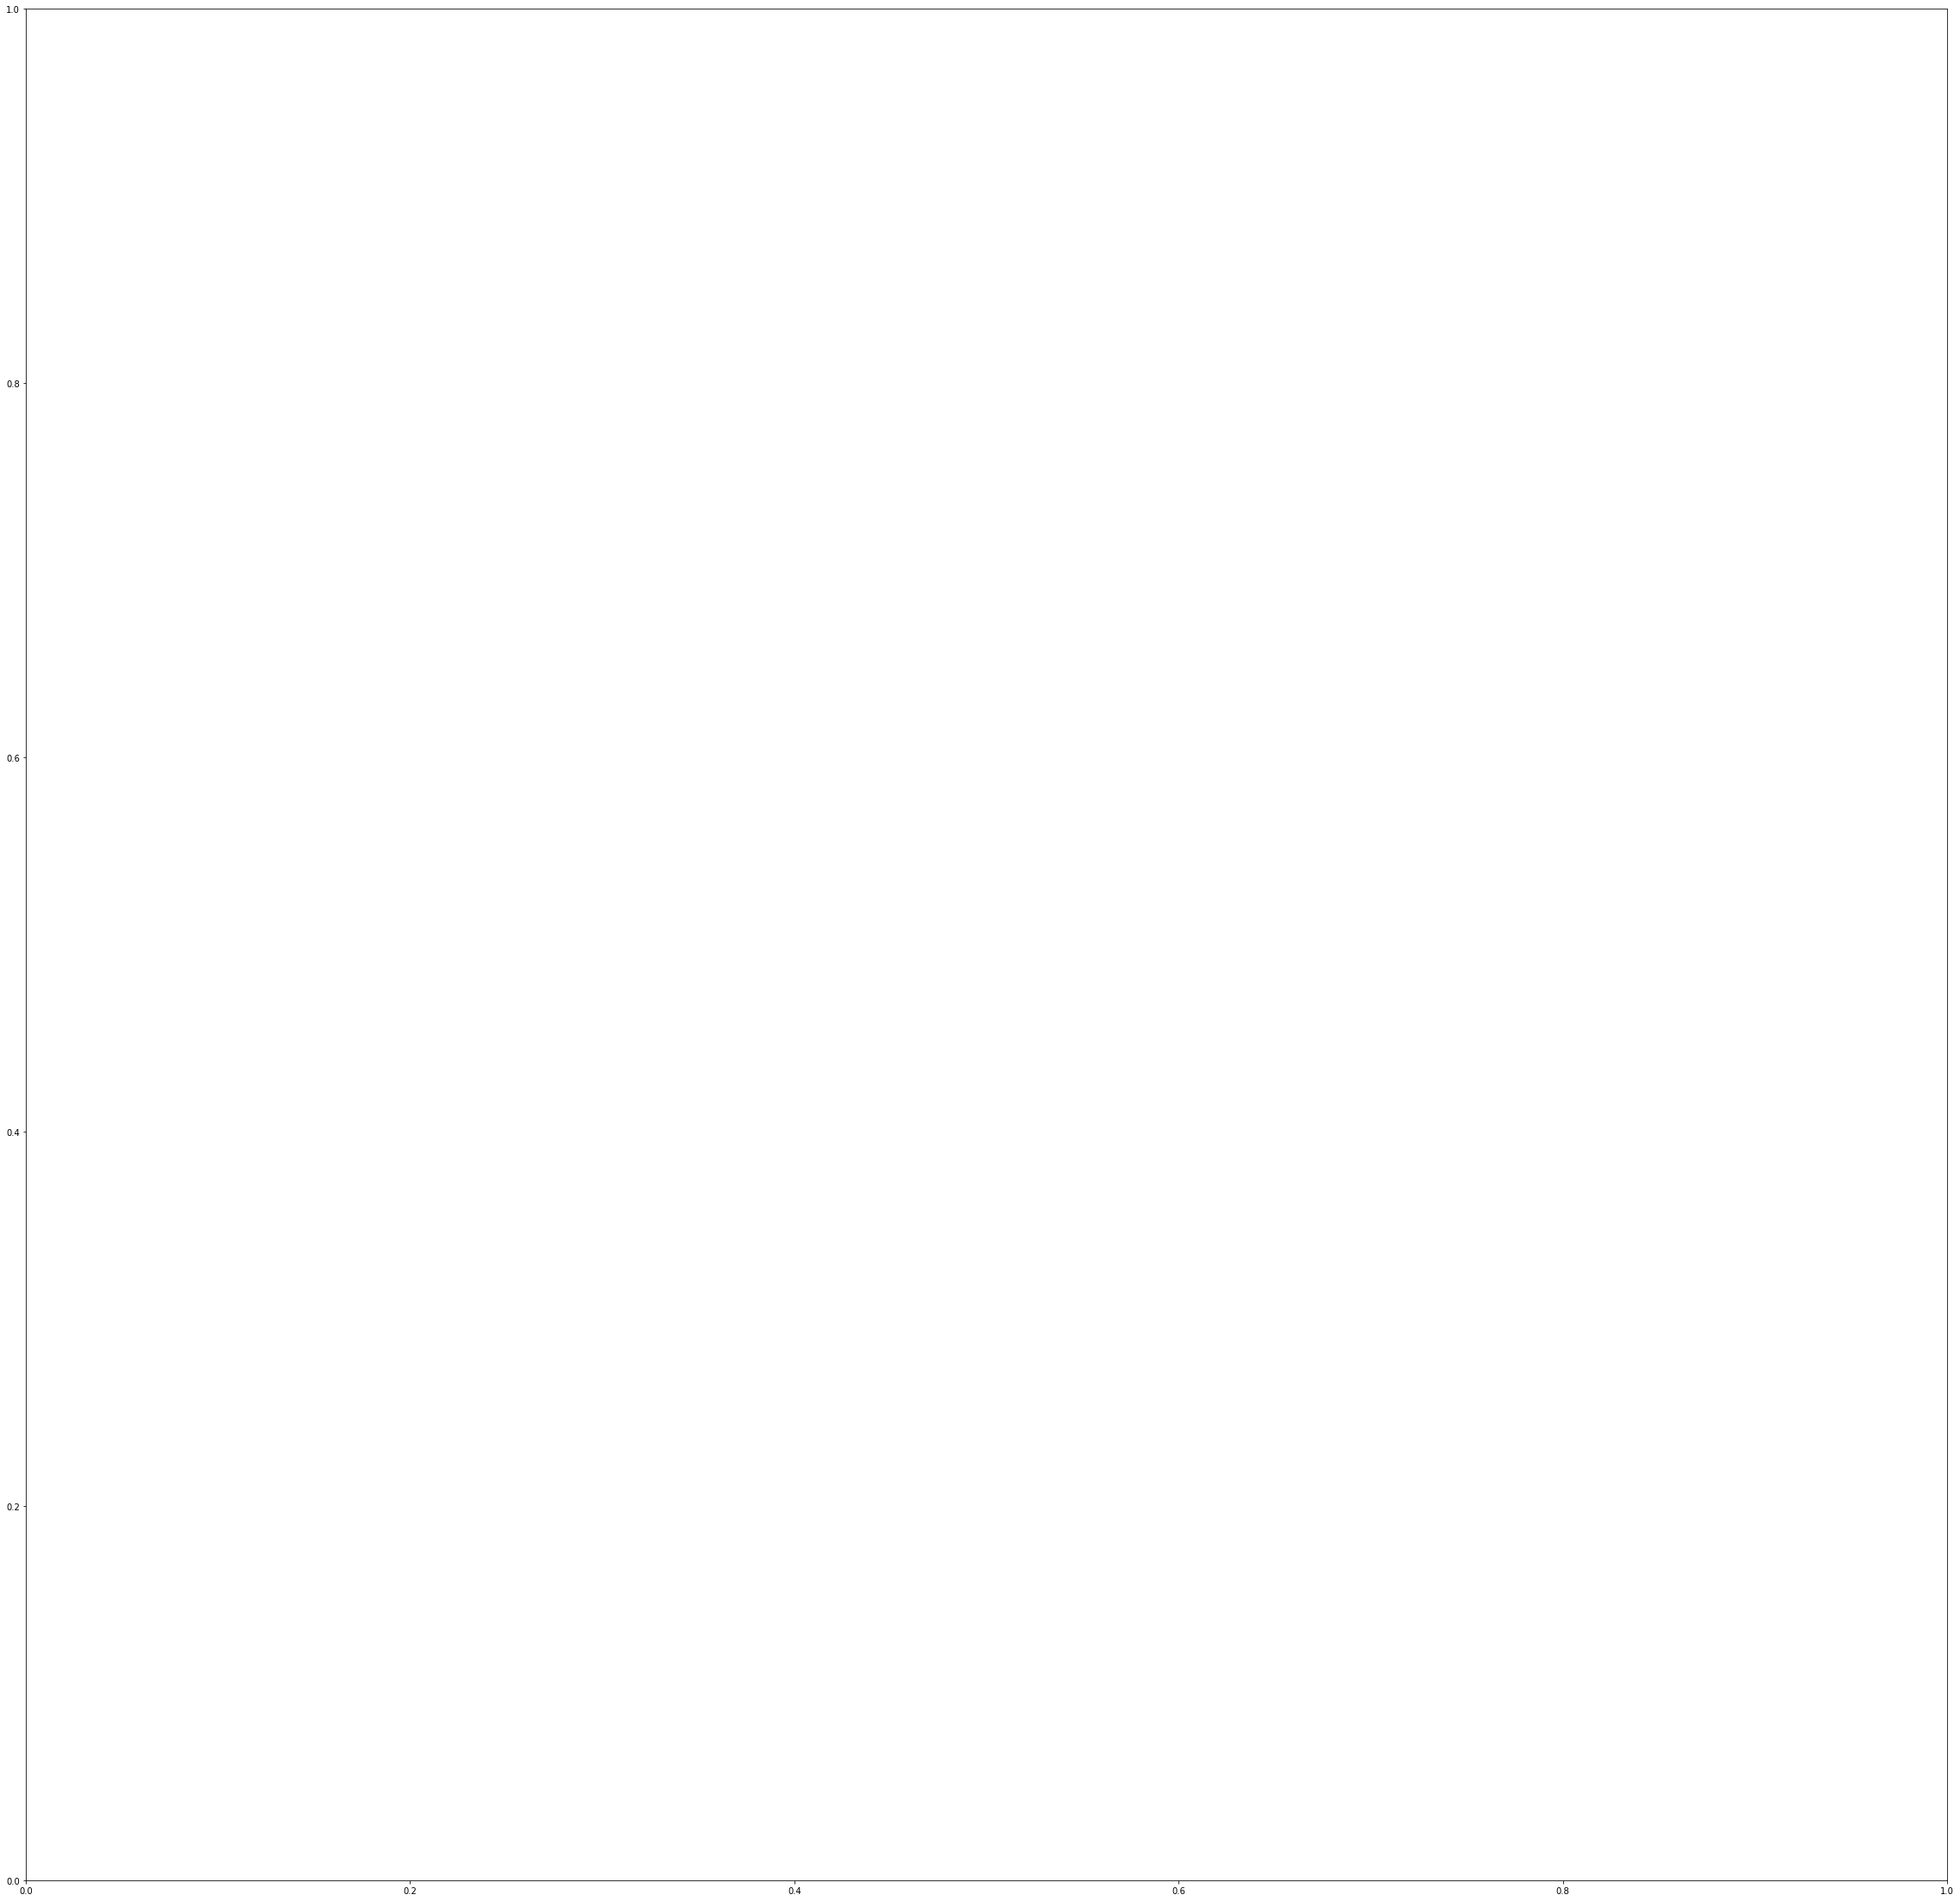

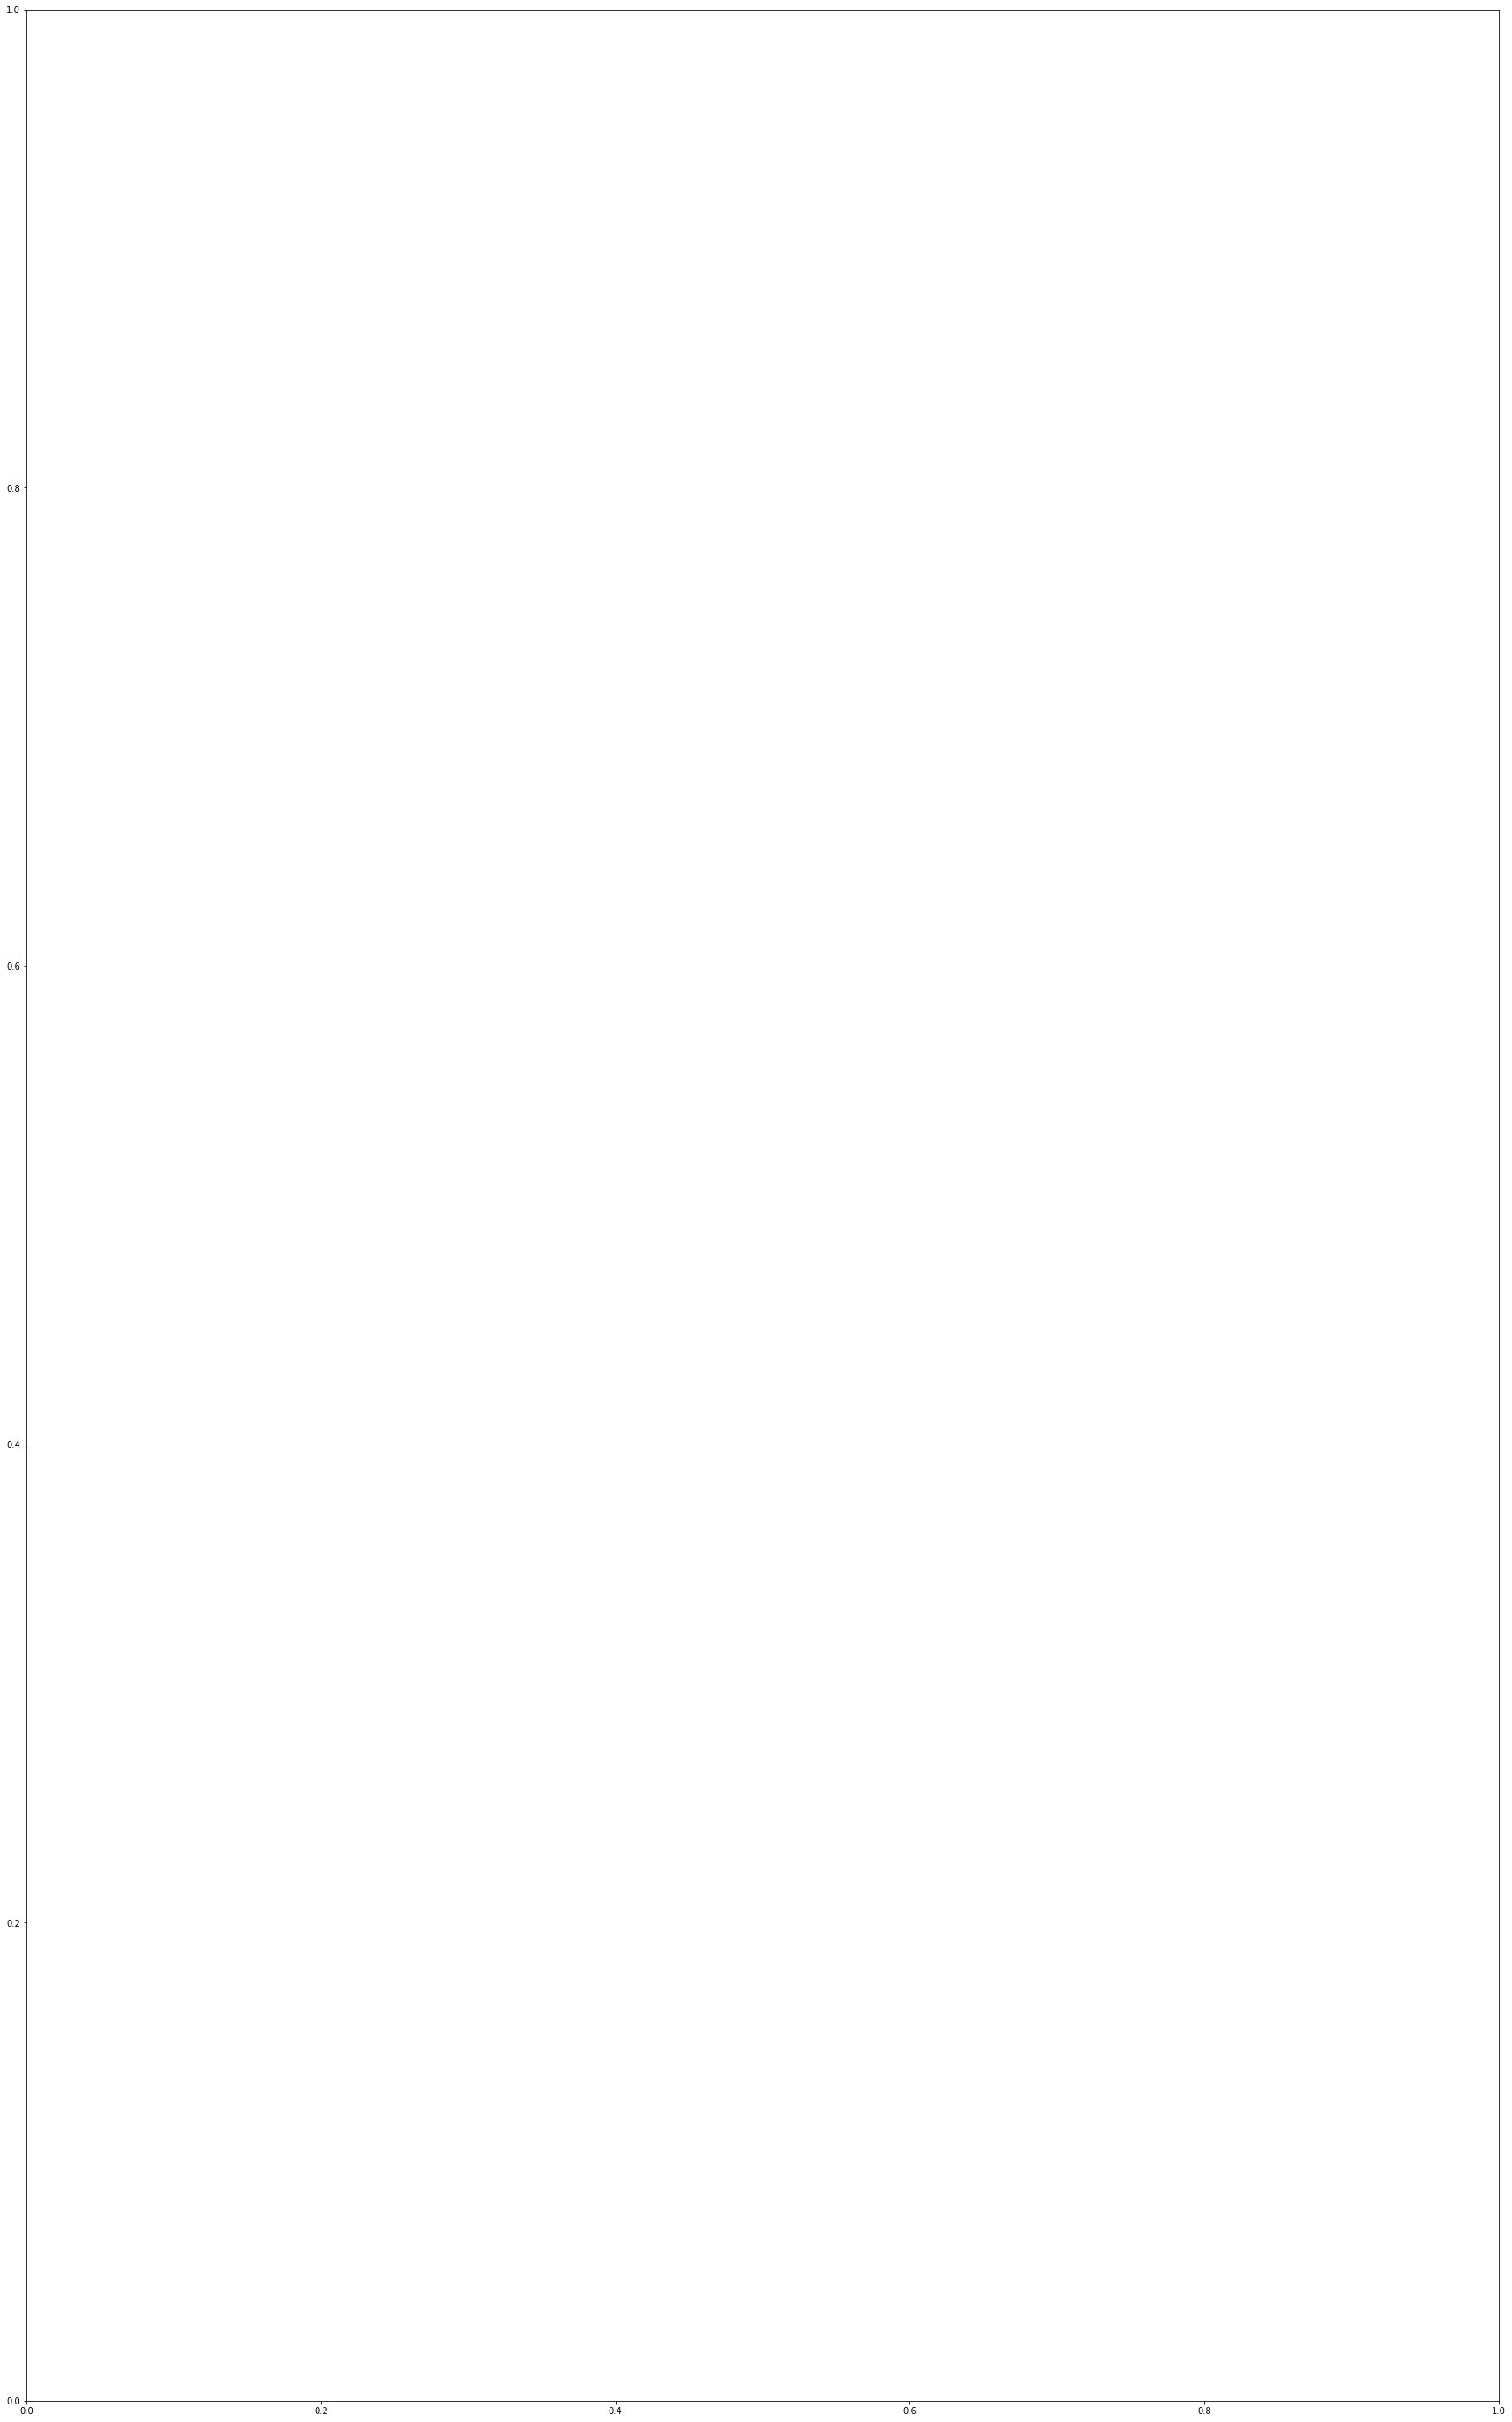

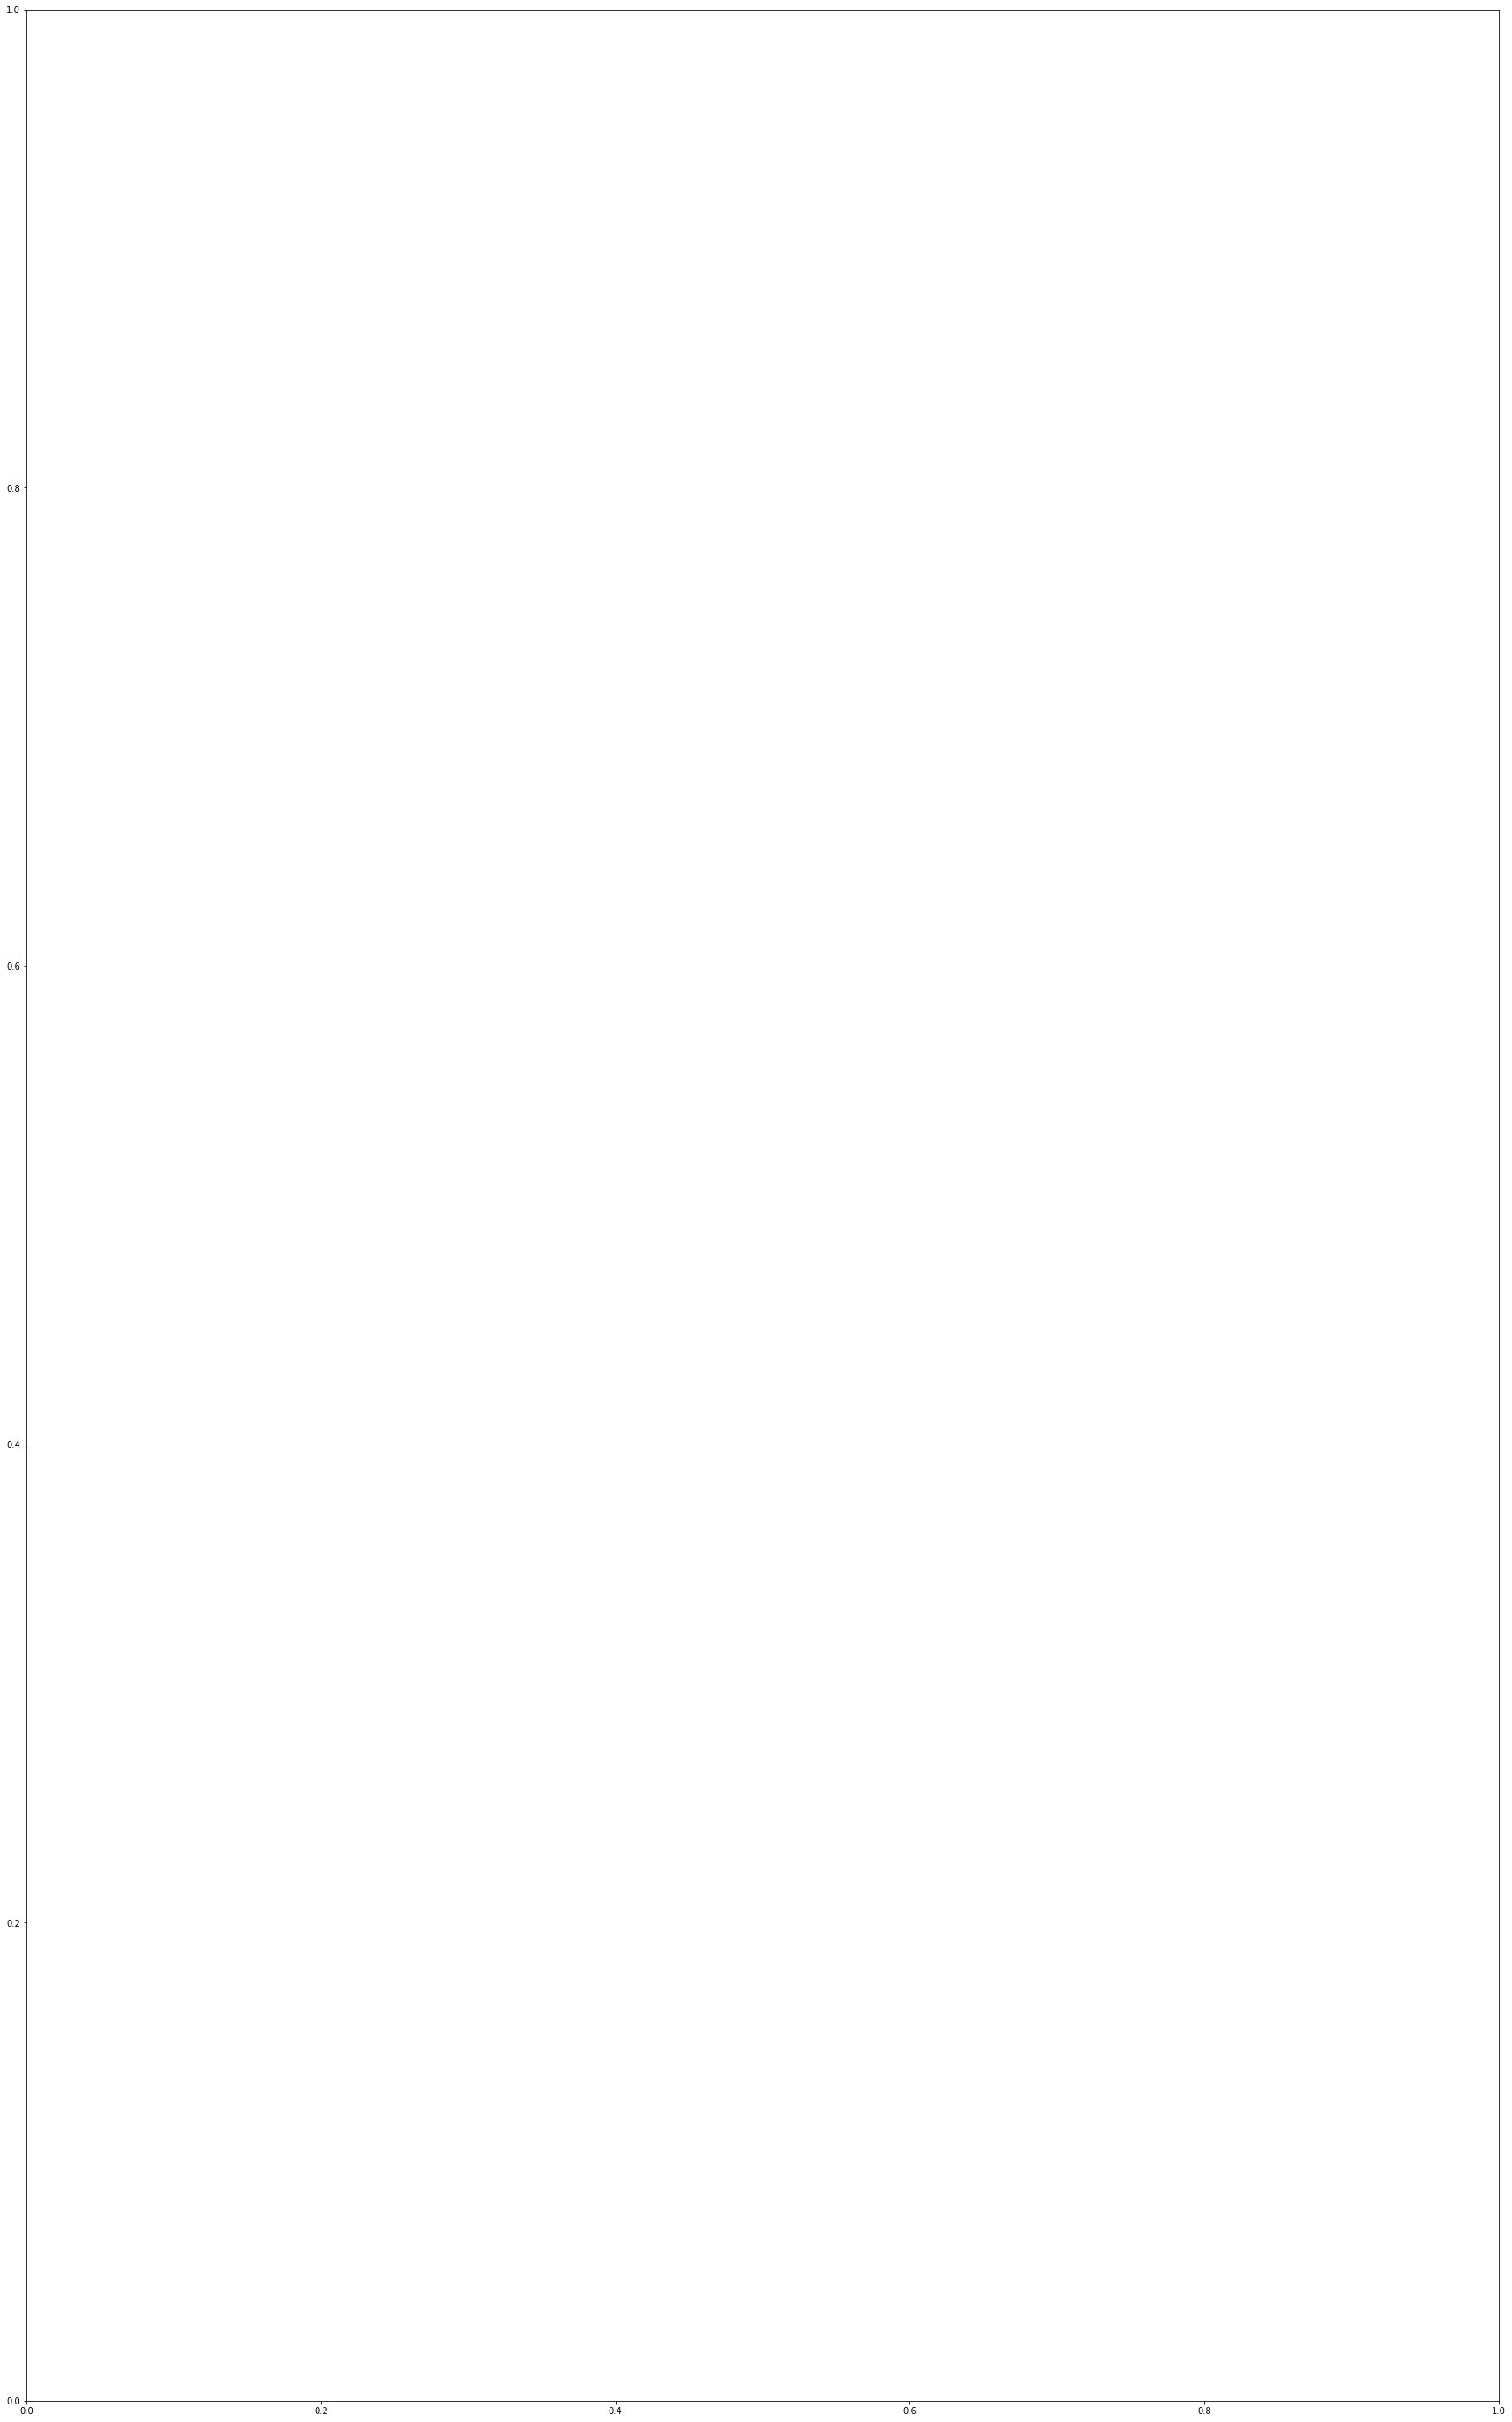

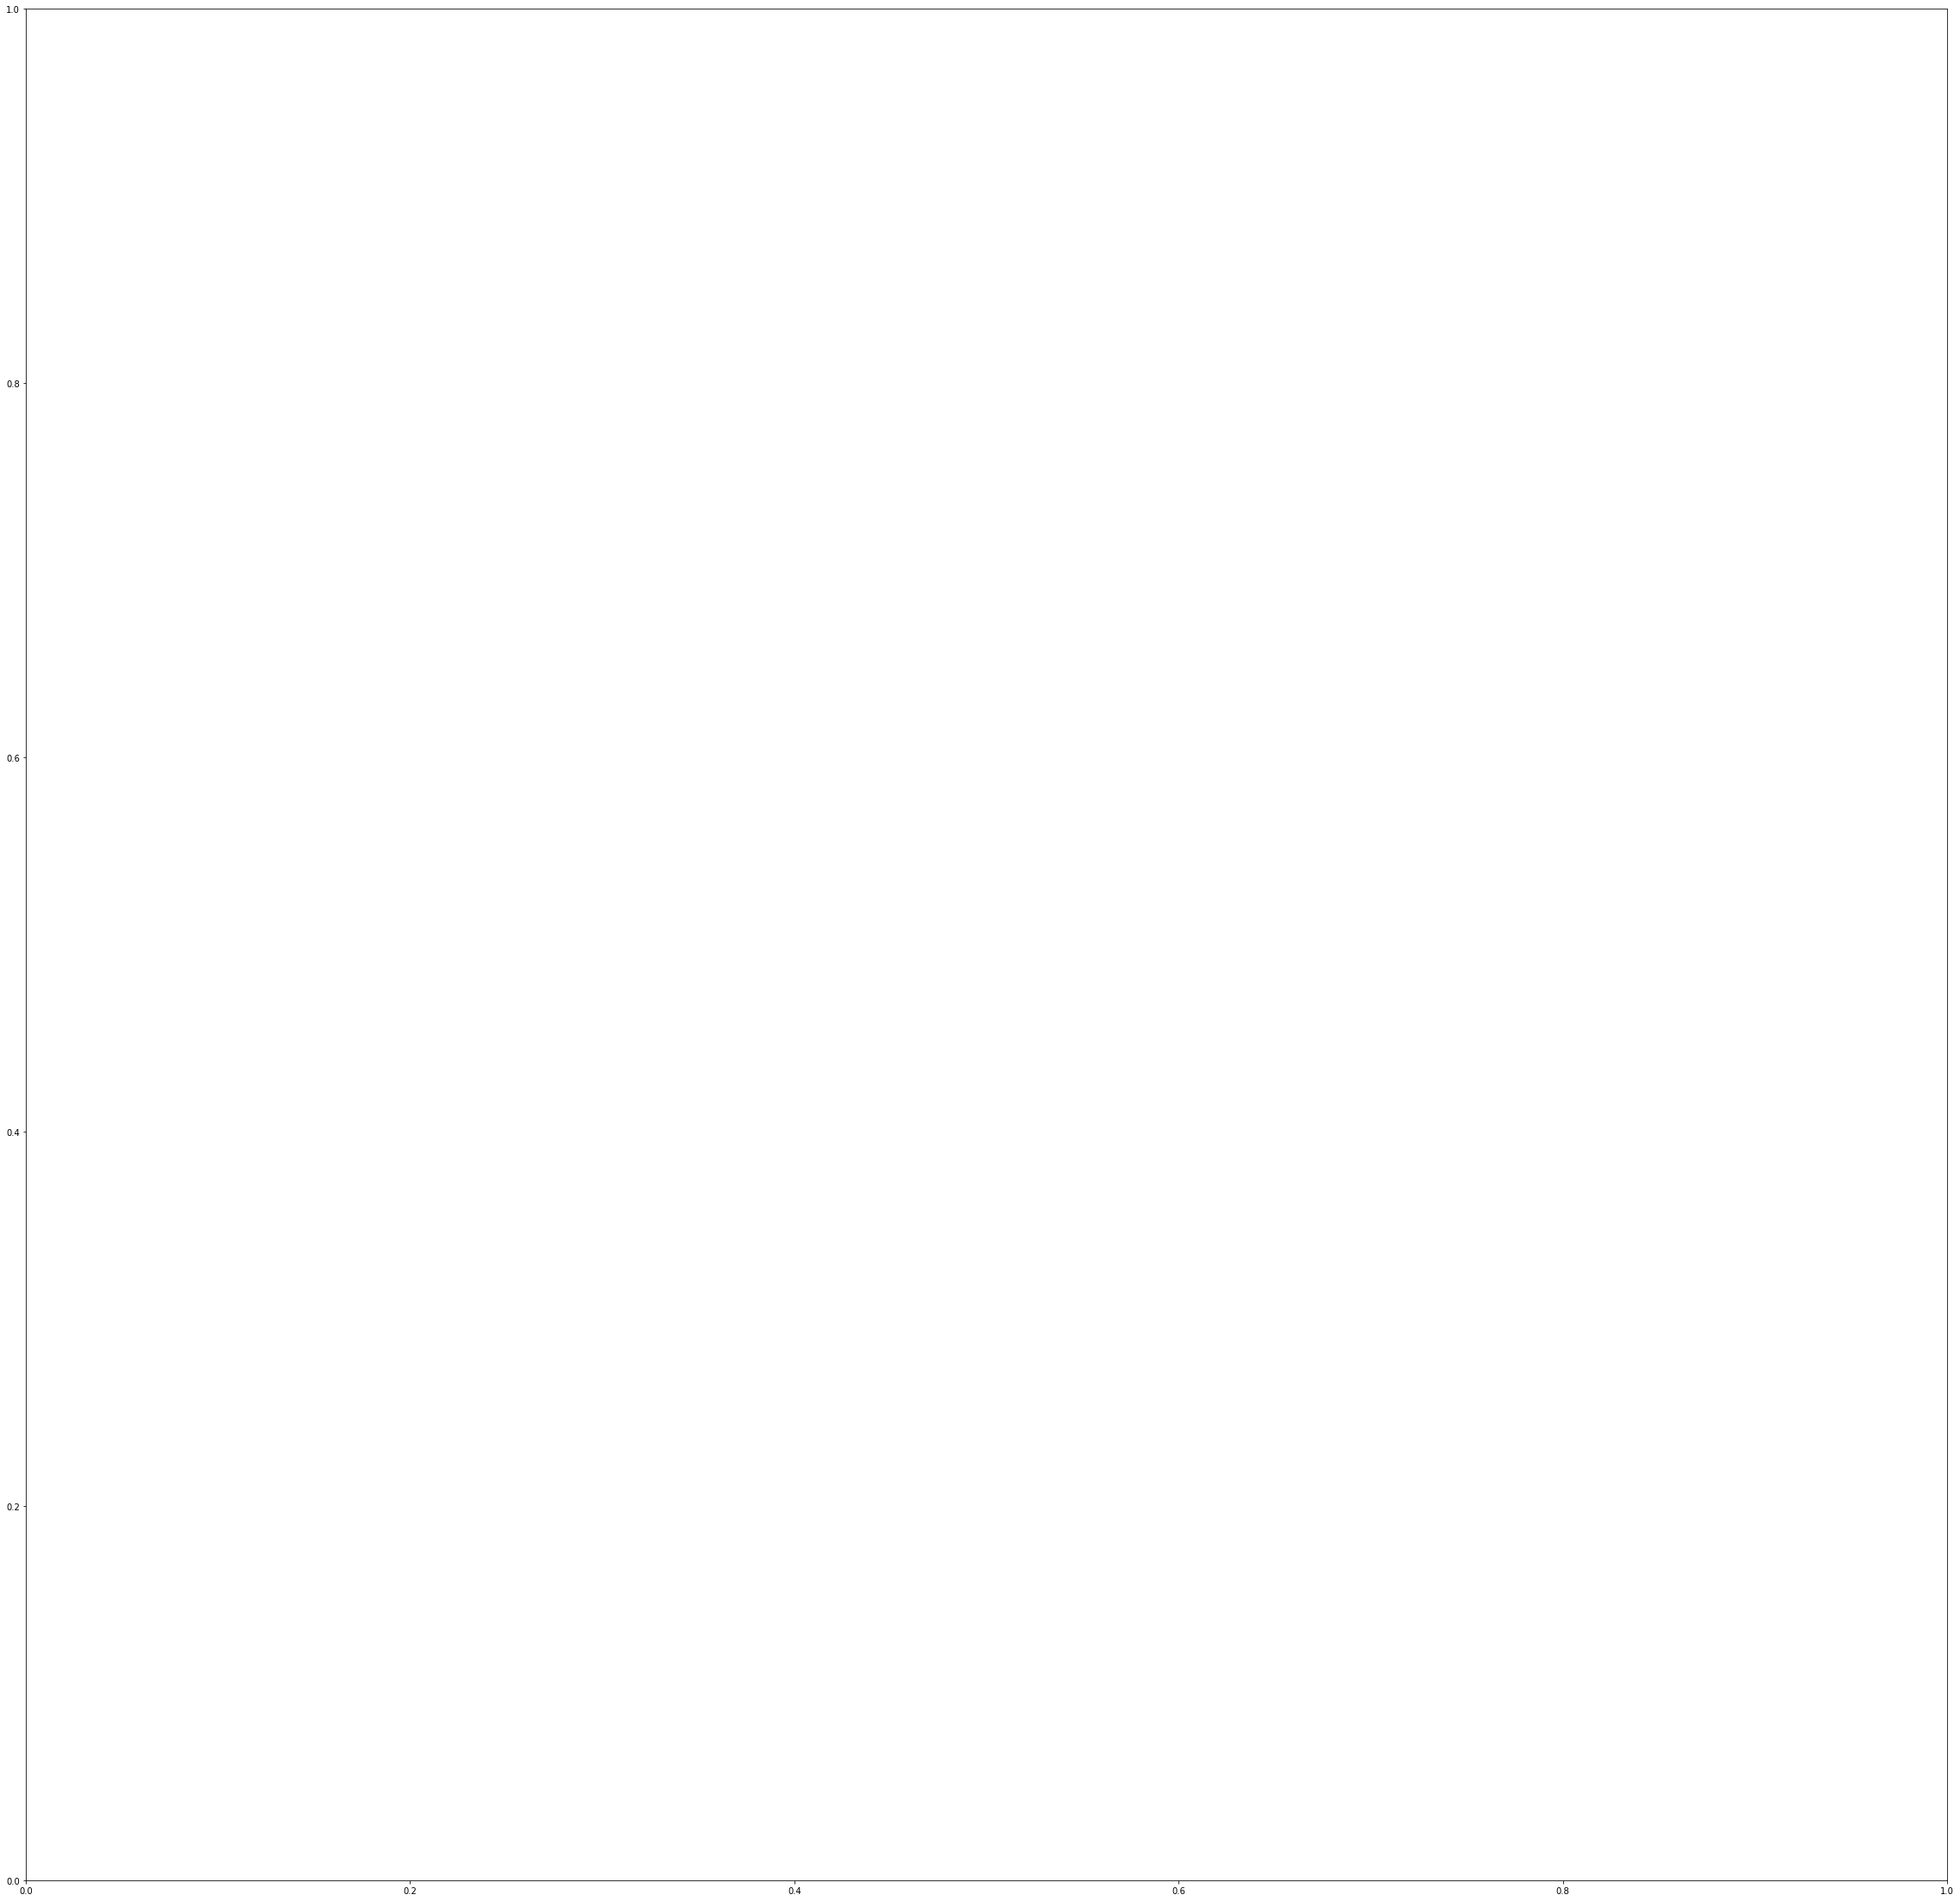

In [121]:
# do the plotting
for k in cbypeak_all.keys():
    plot_set_profile(cbypeak_all,k,"all")
    plt.clf()
    plt.cla()

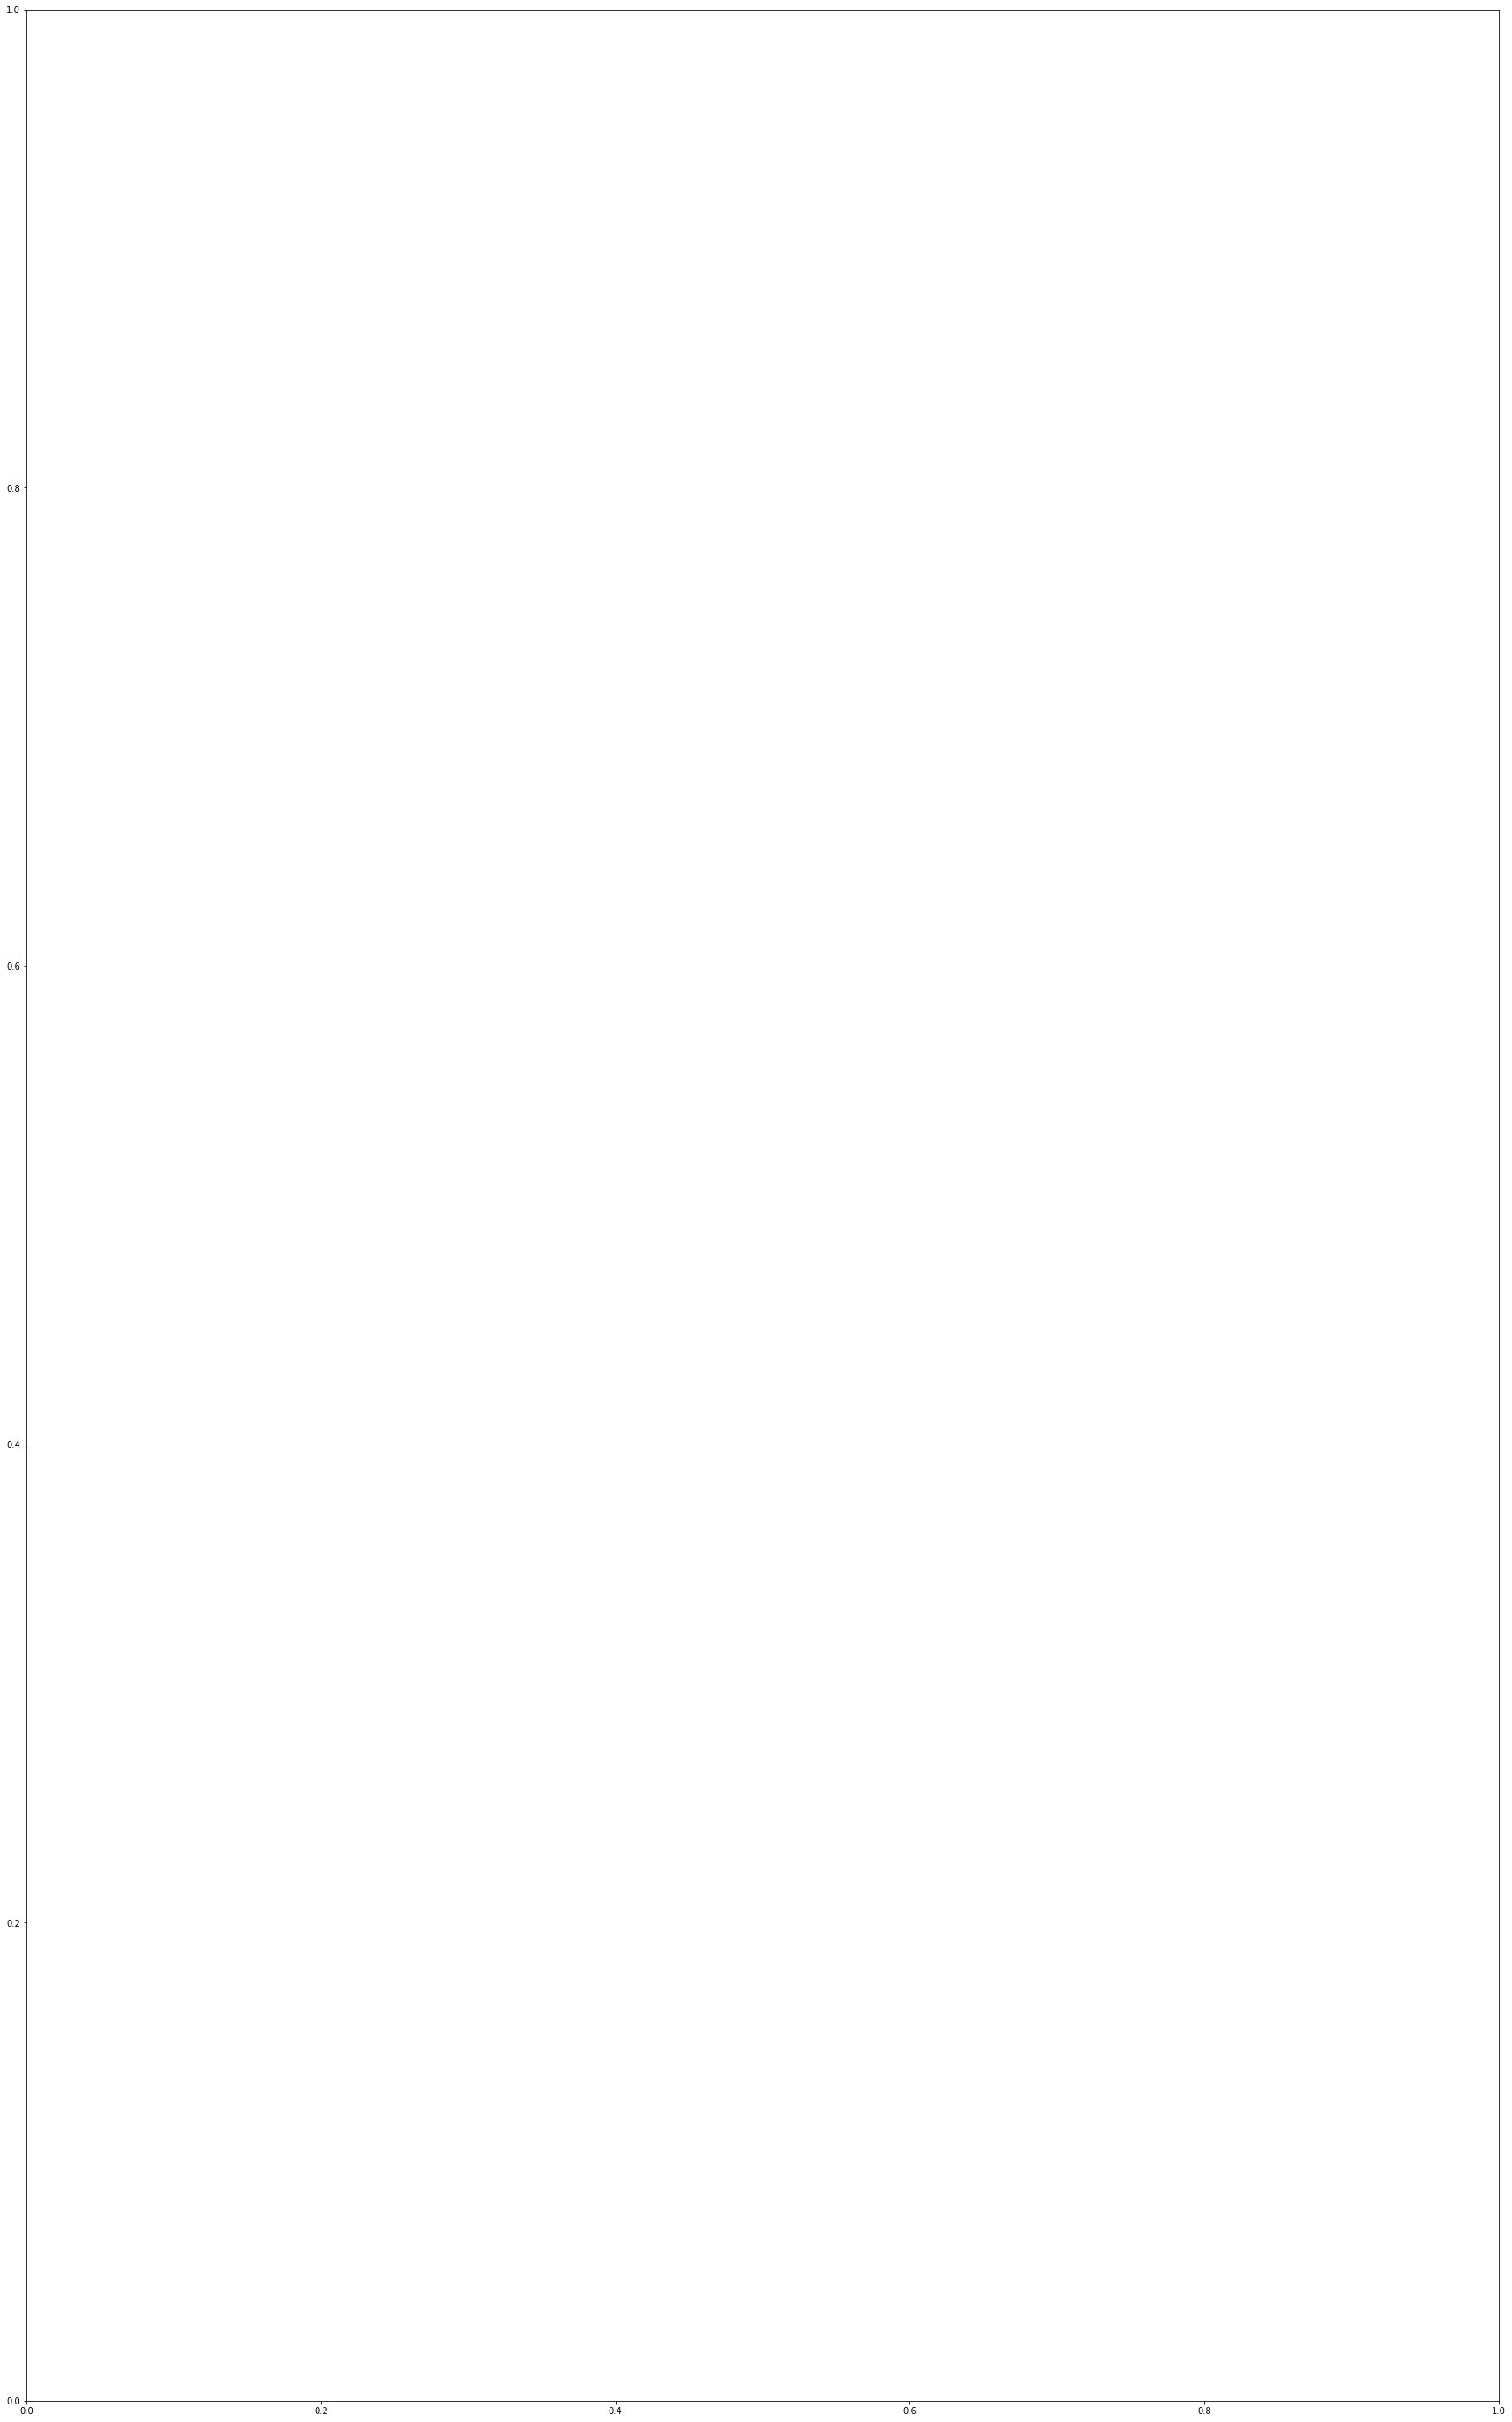

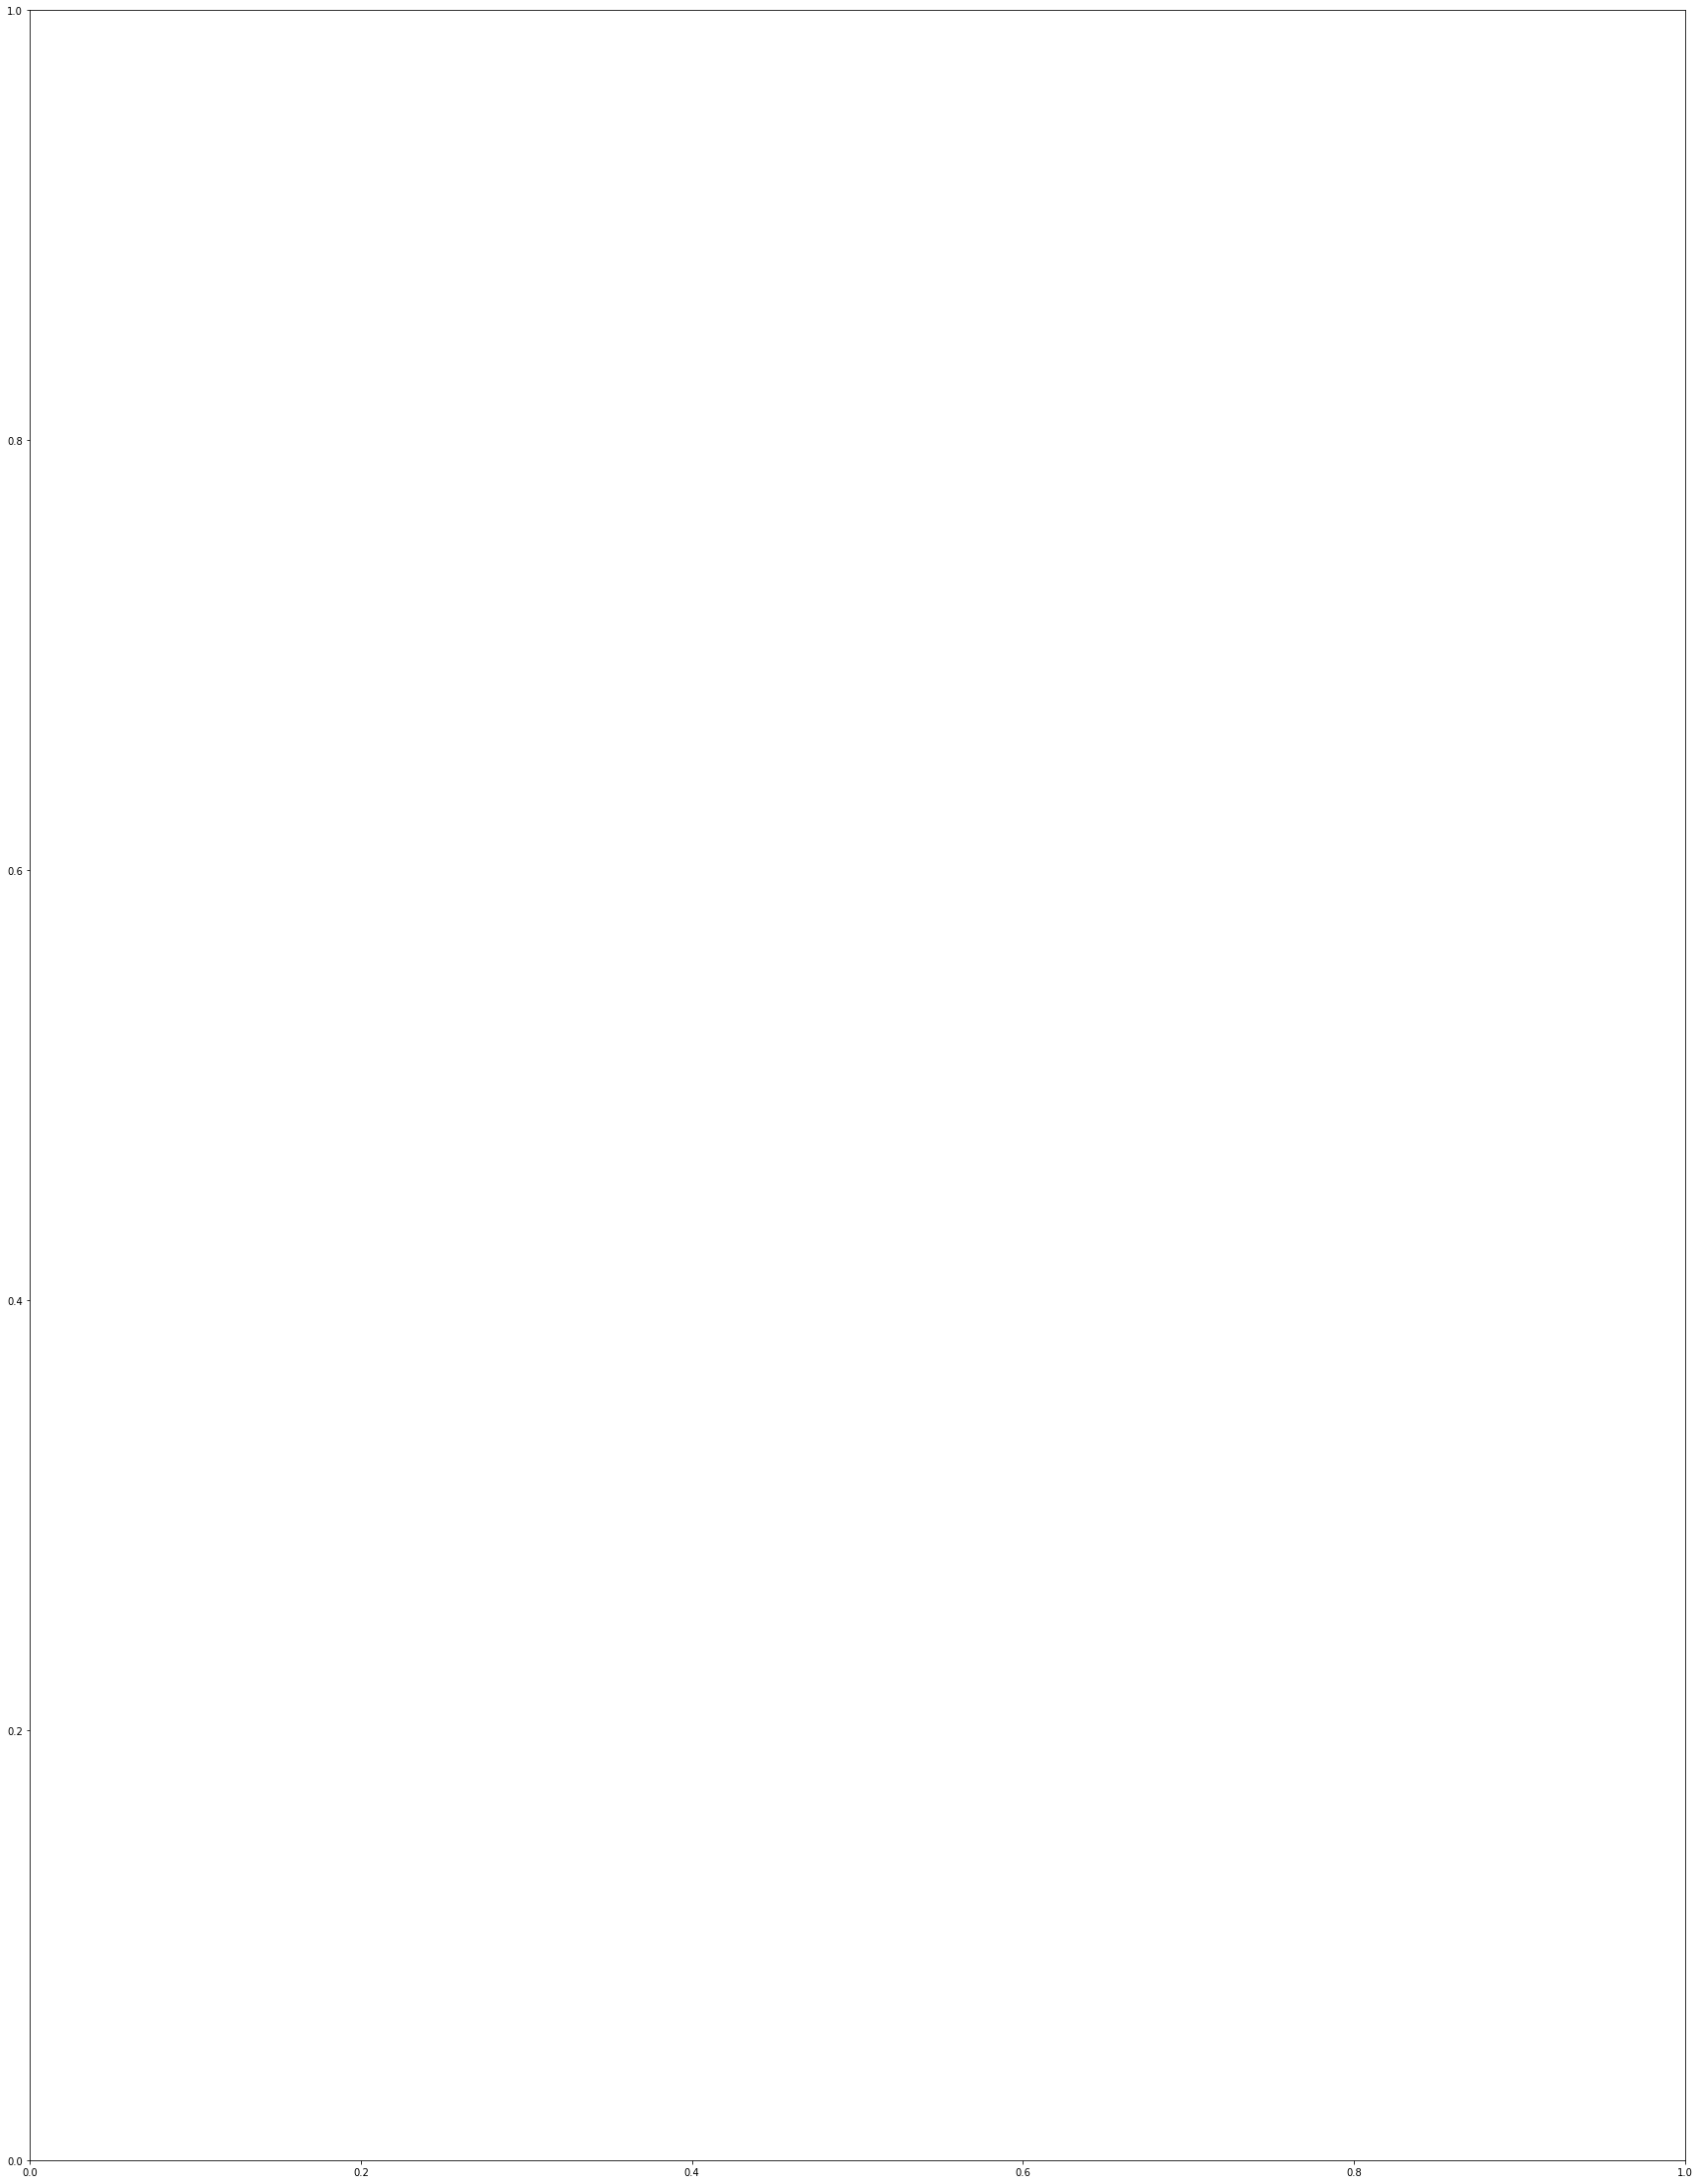

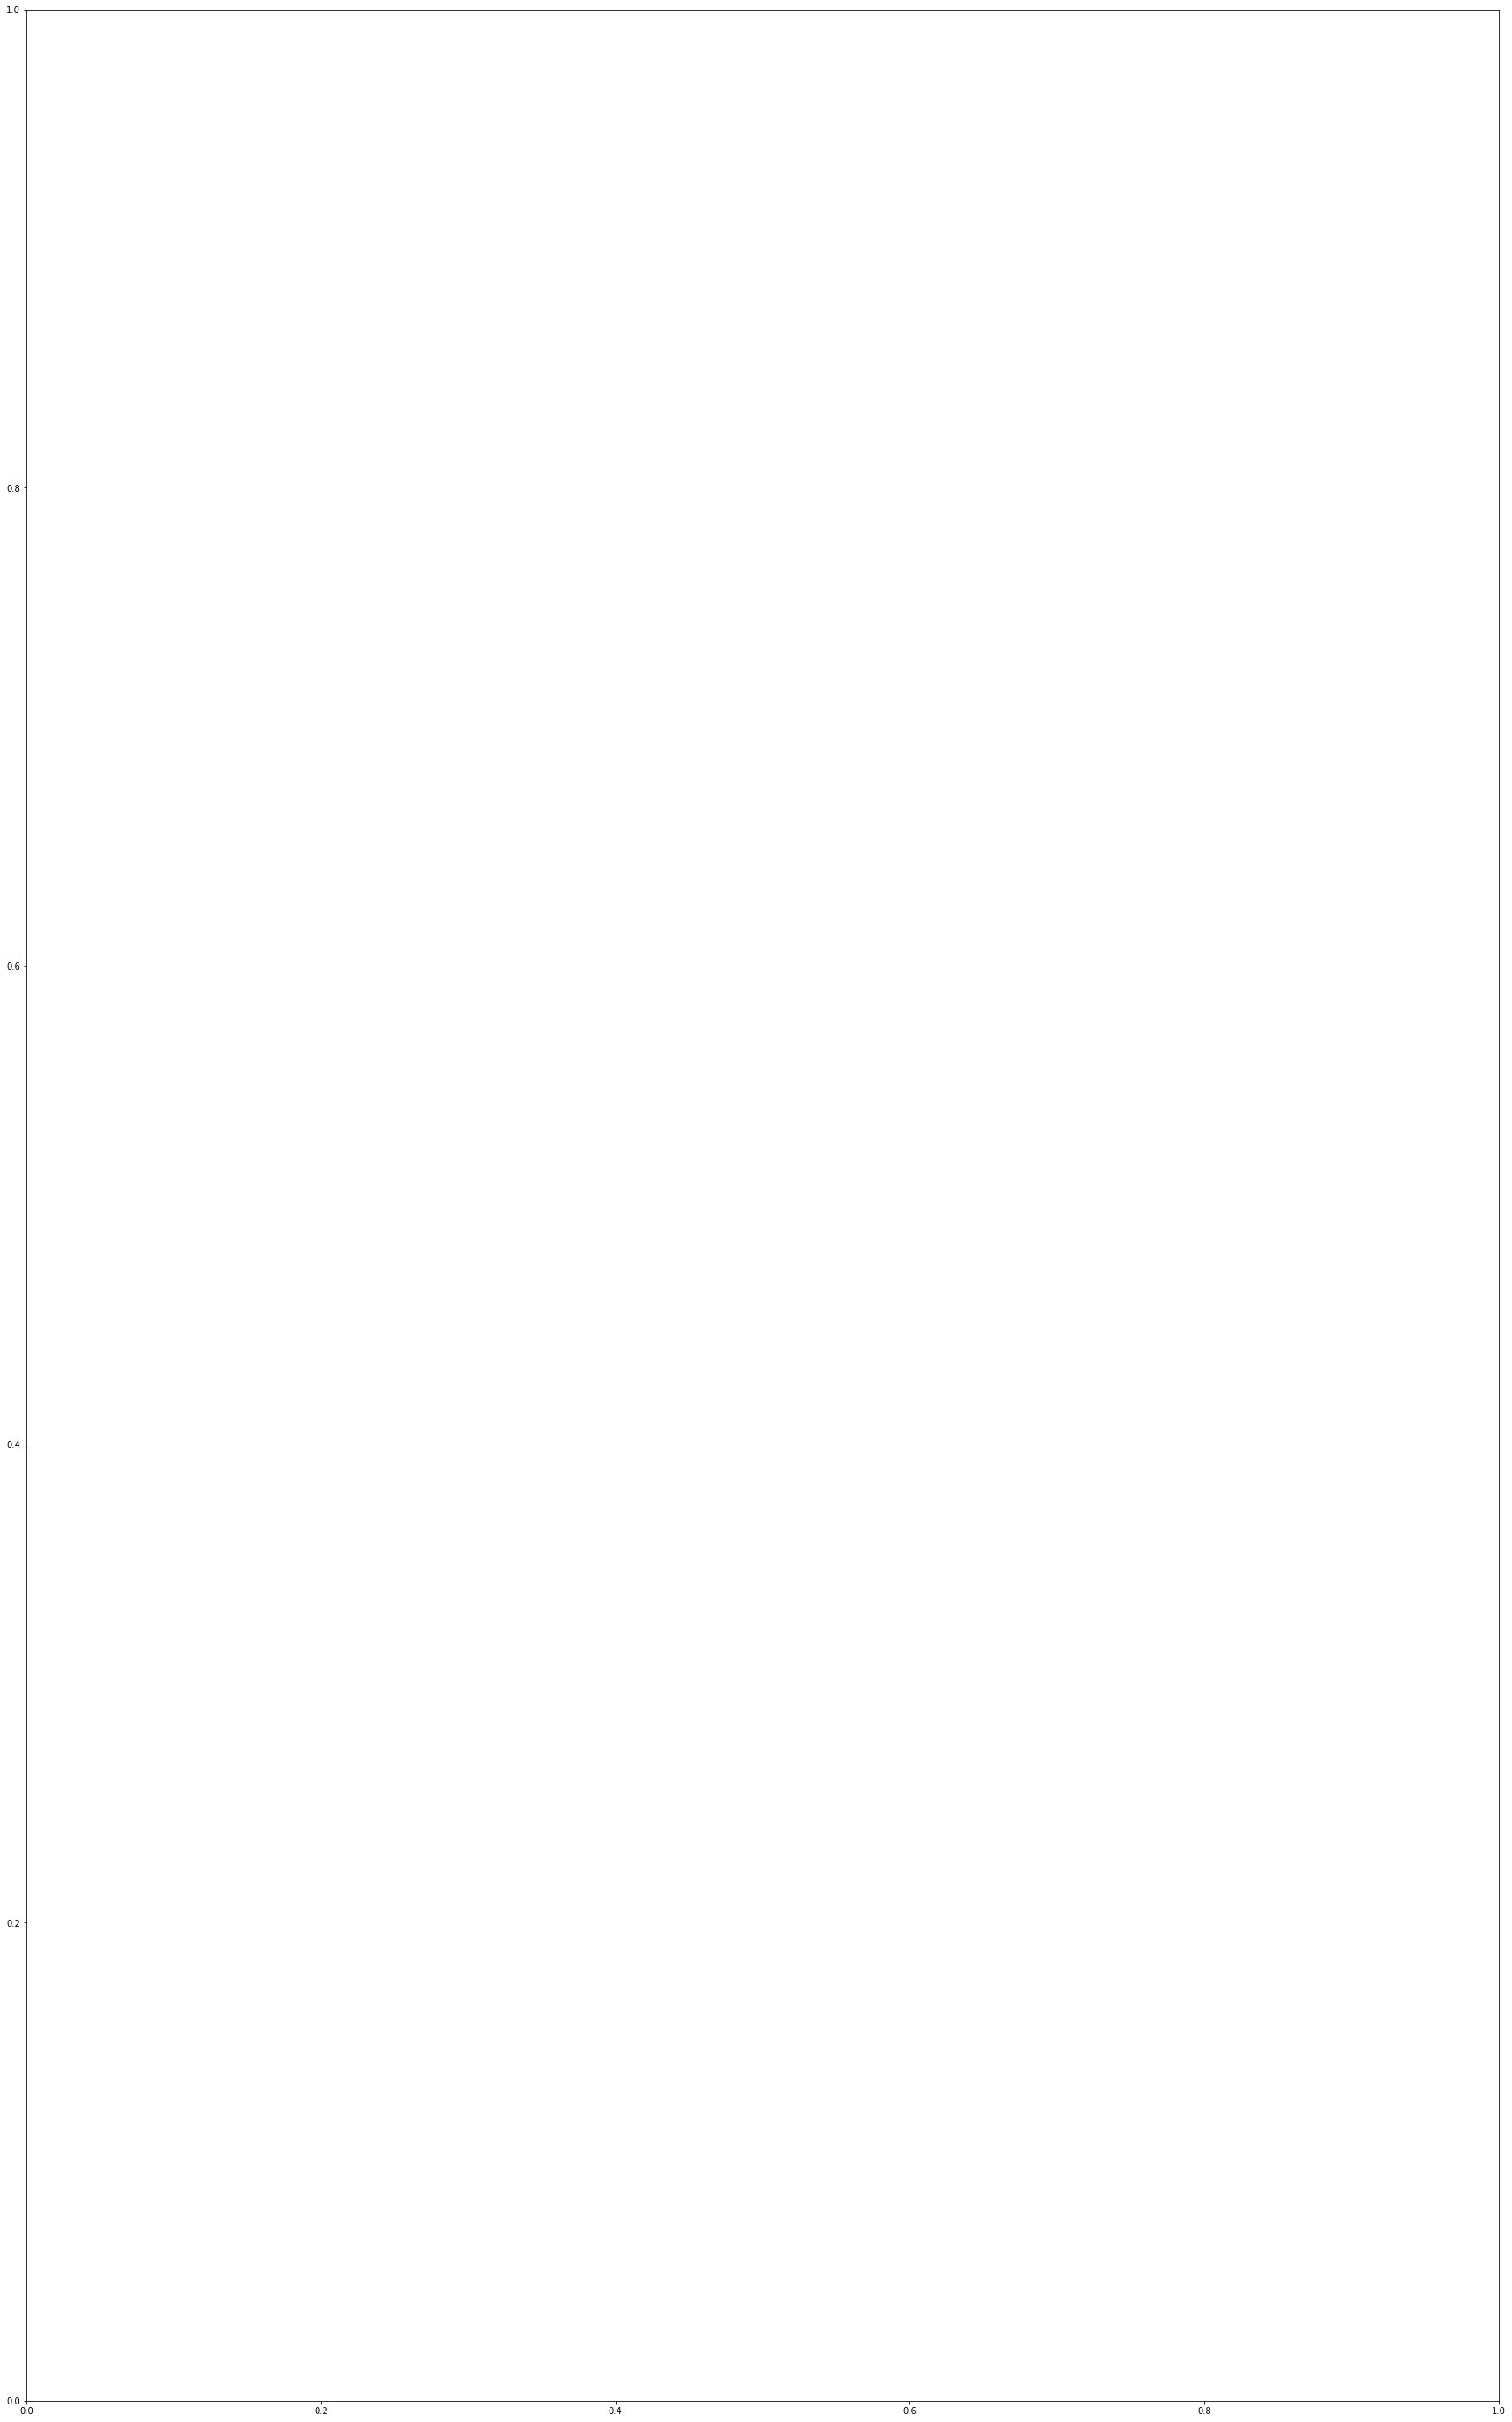

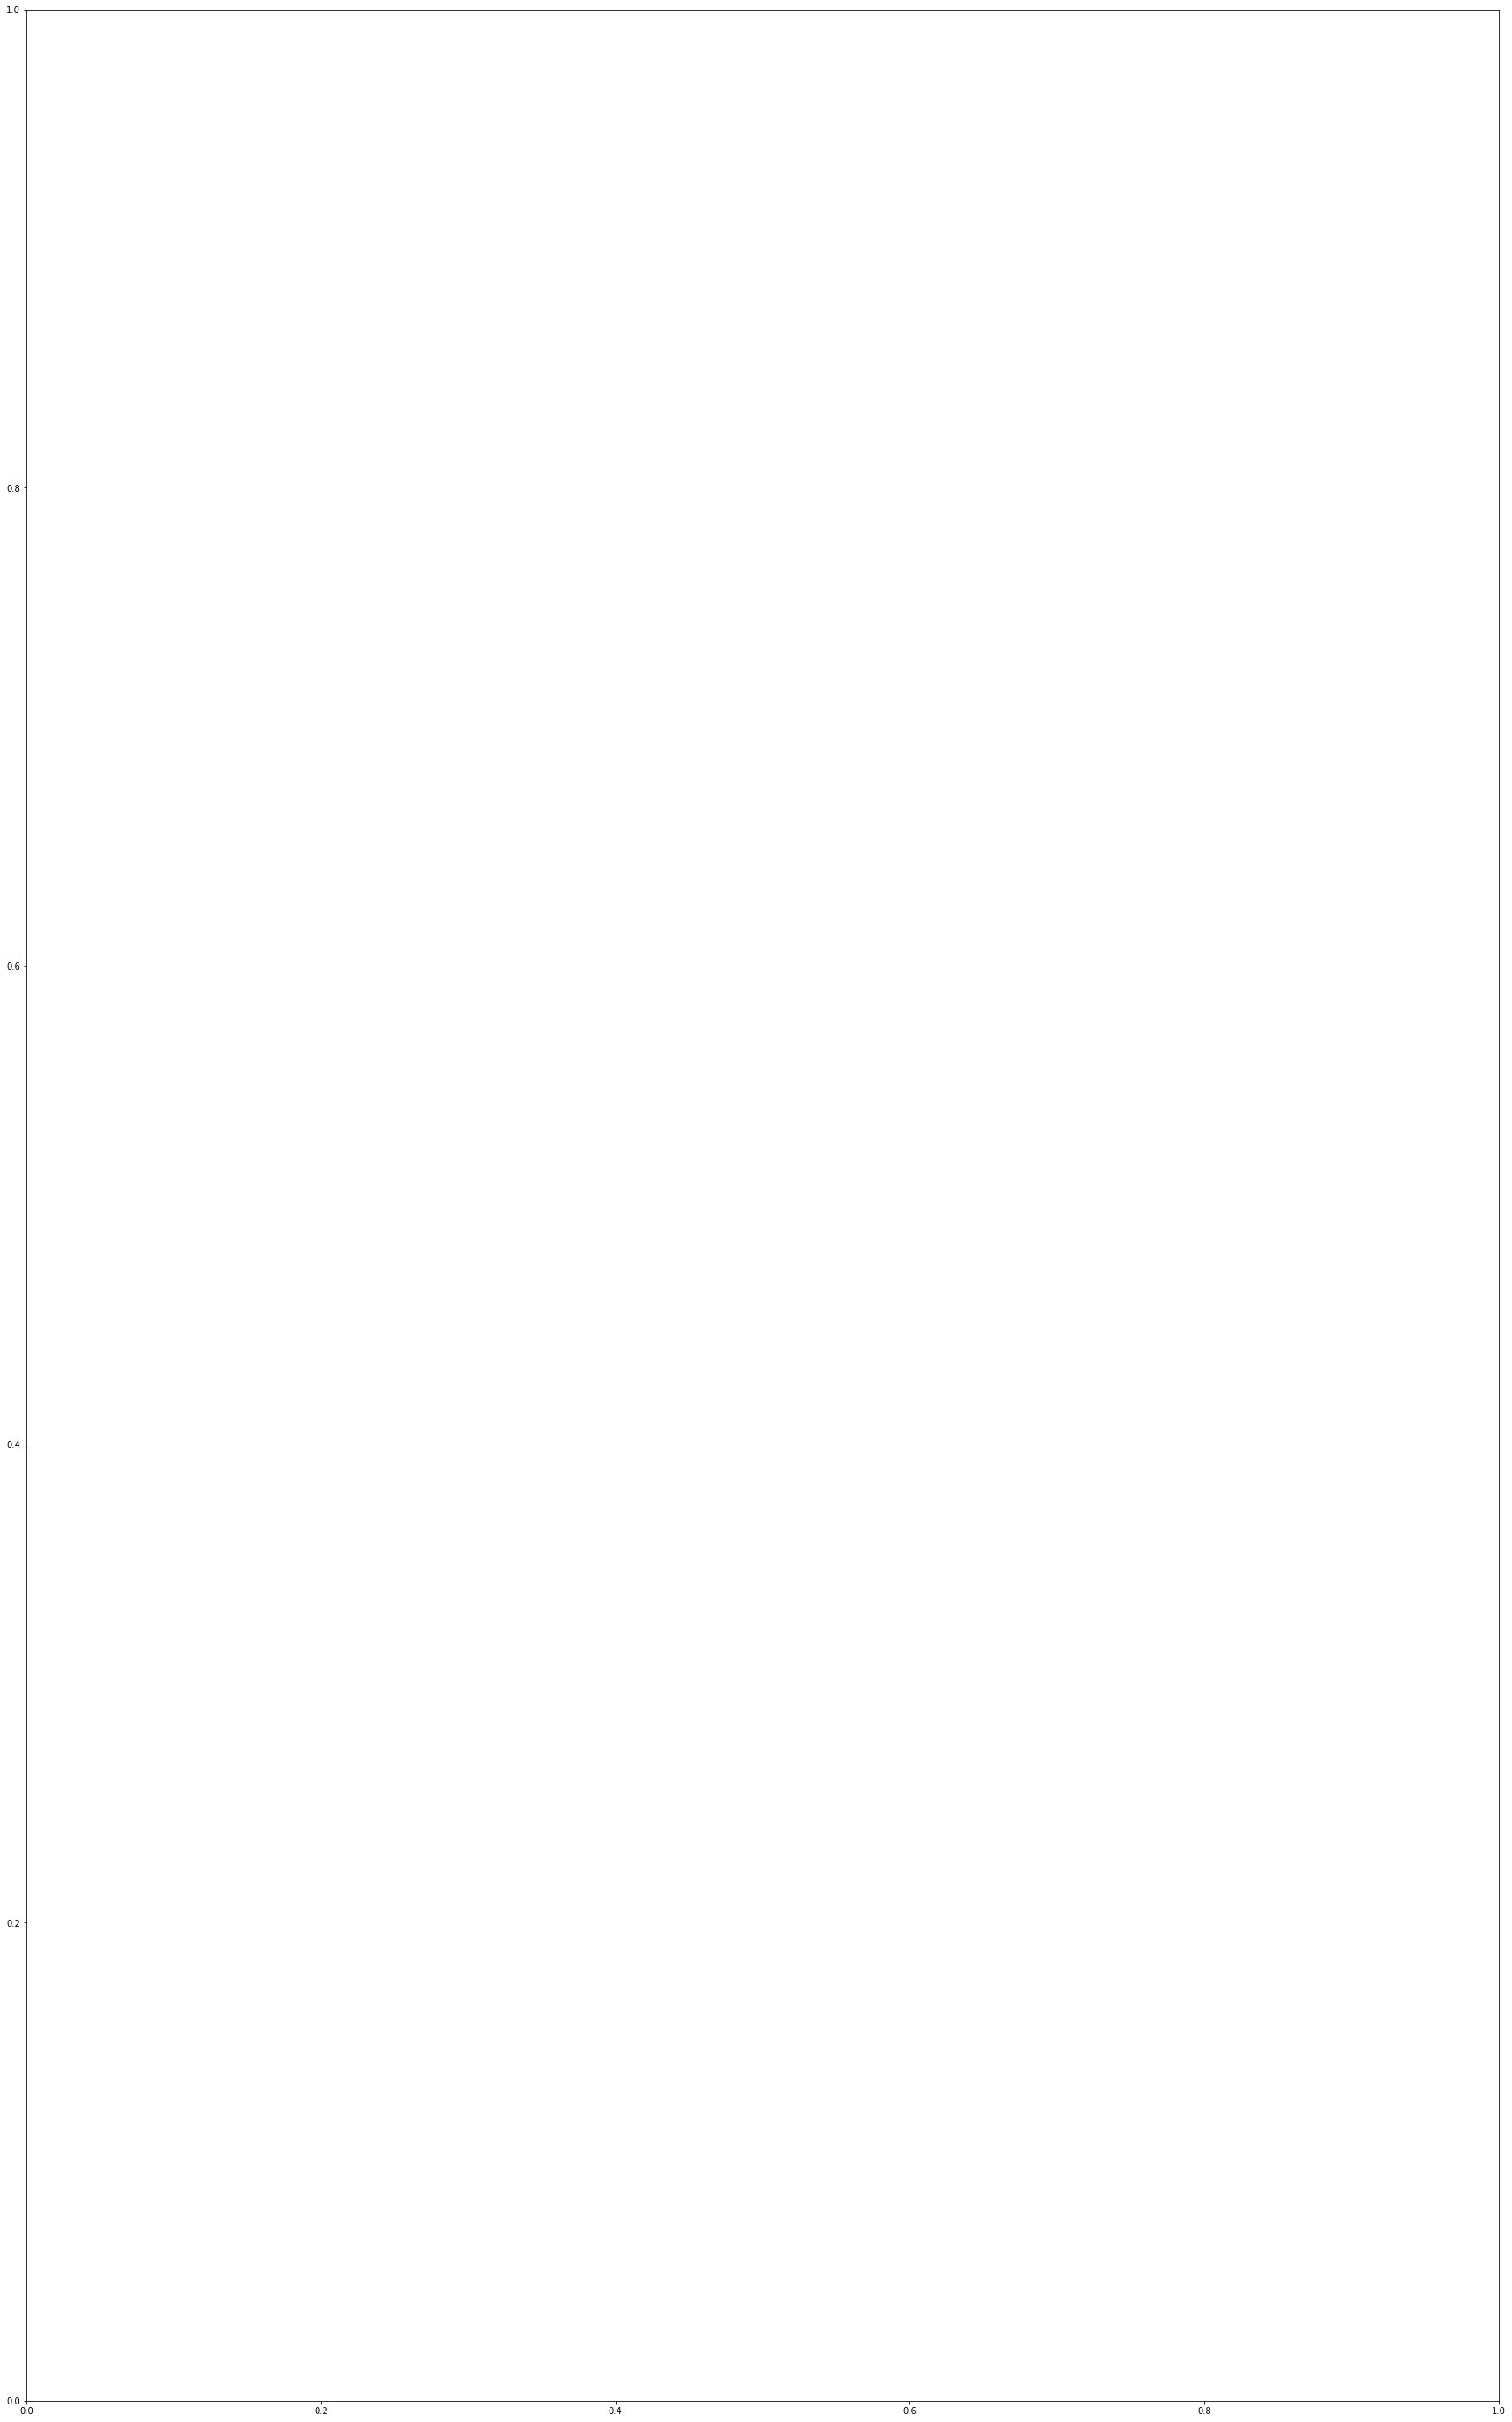

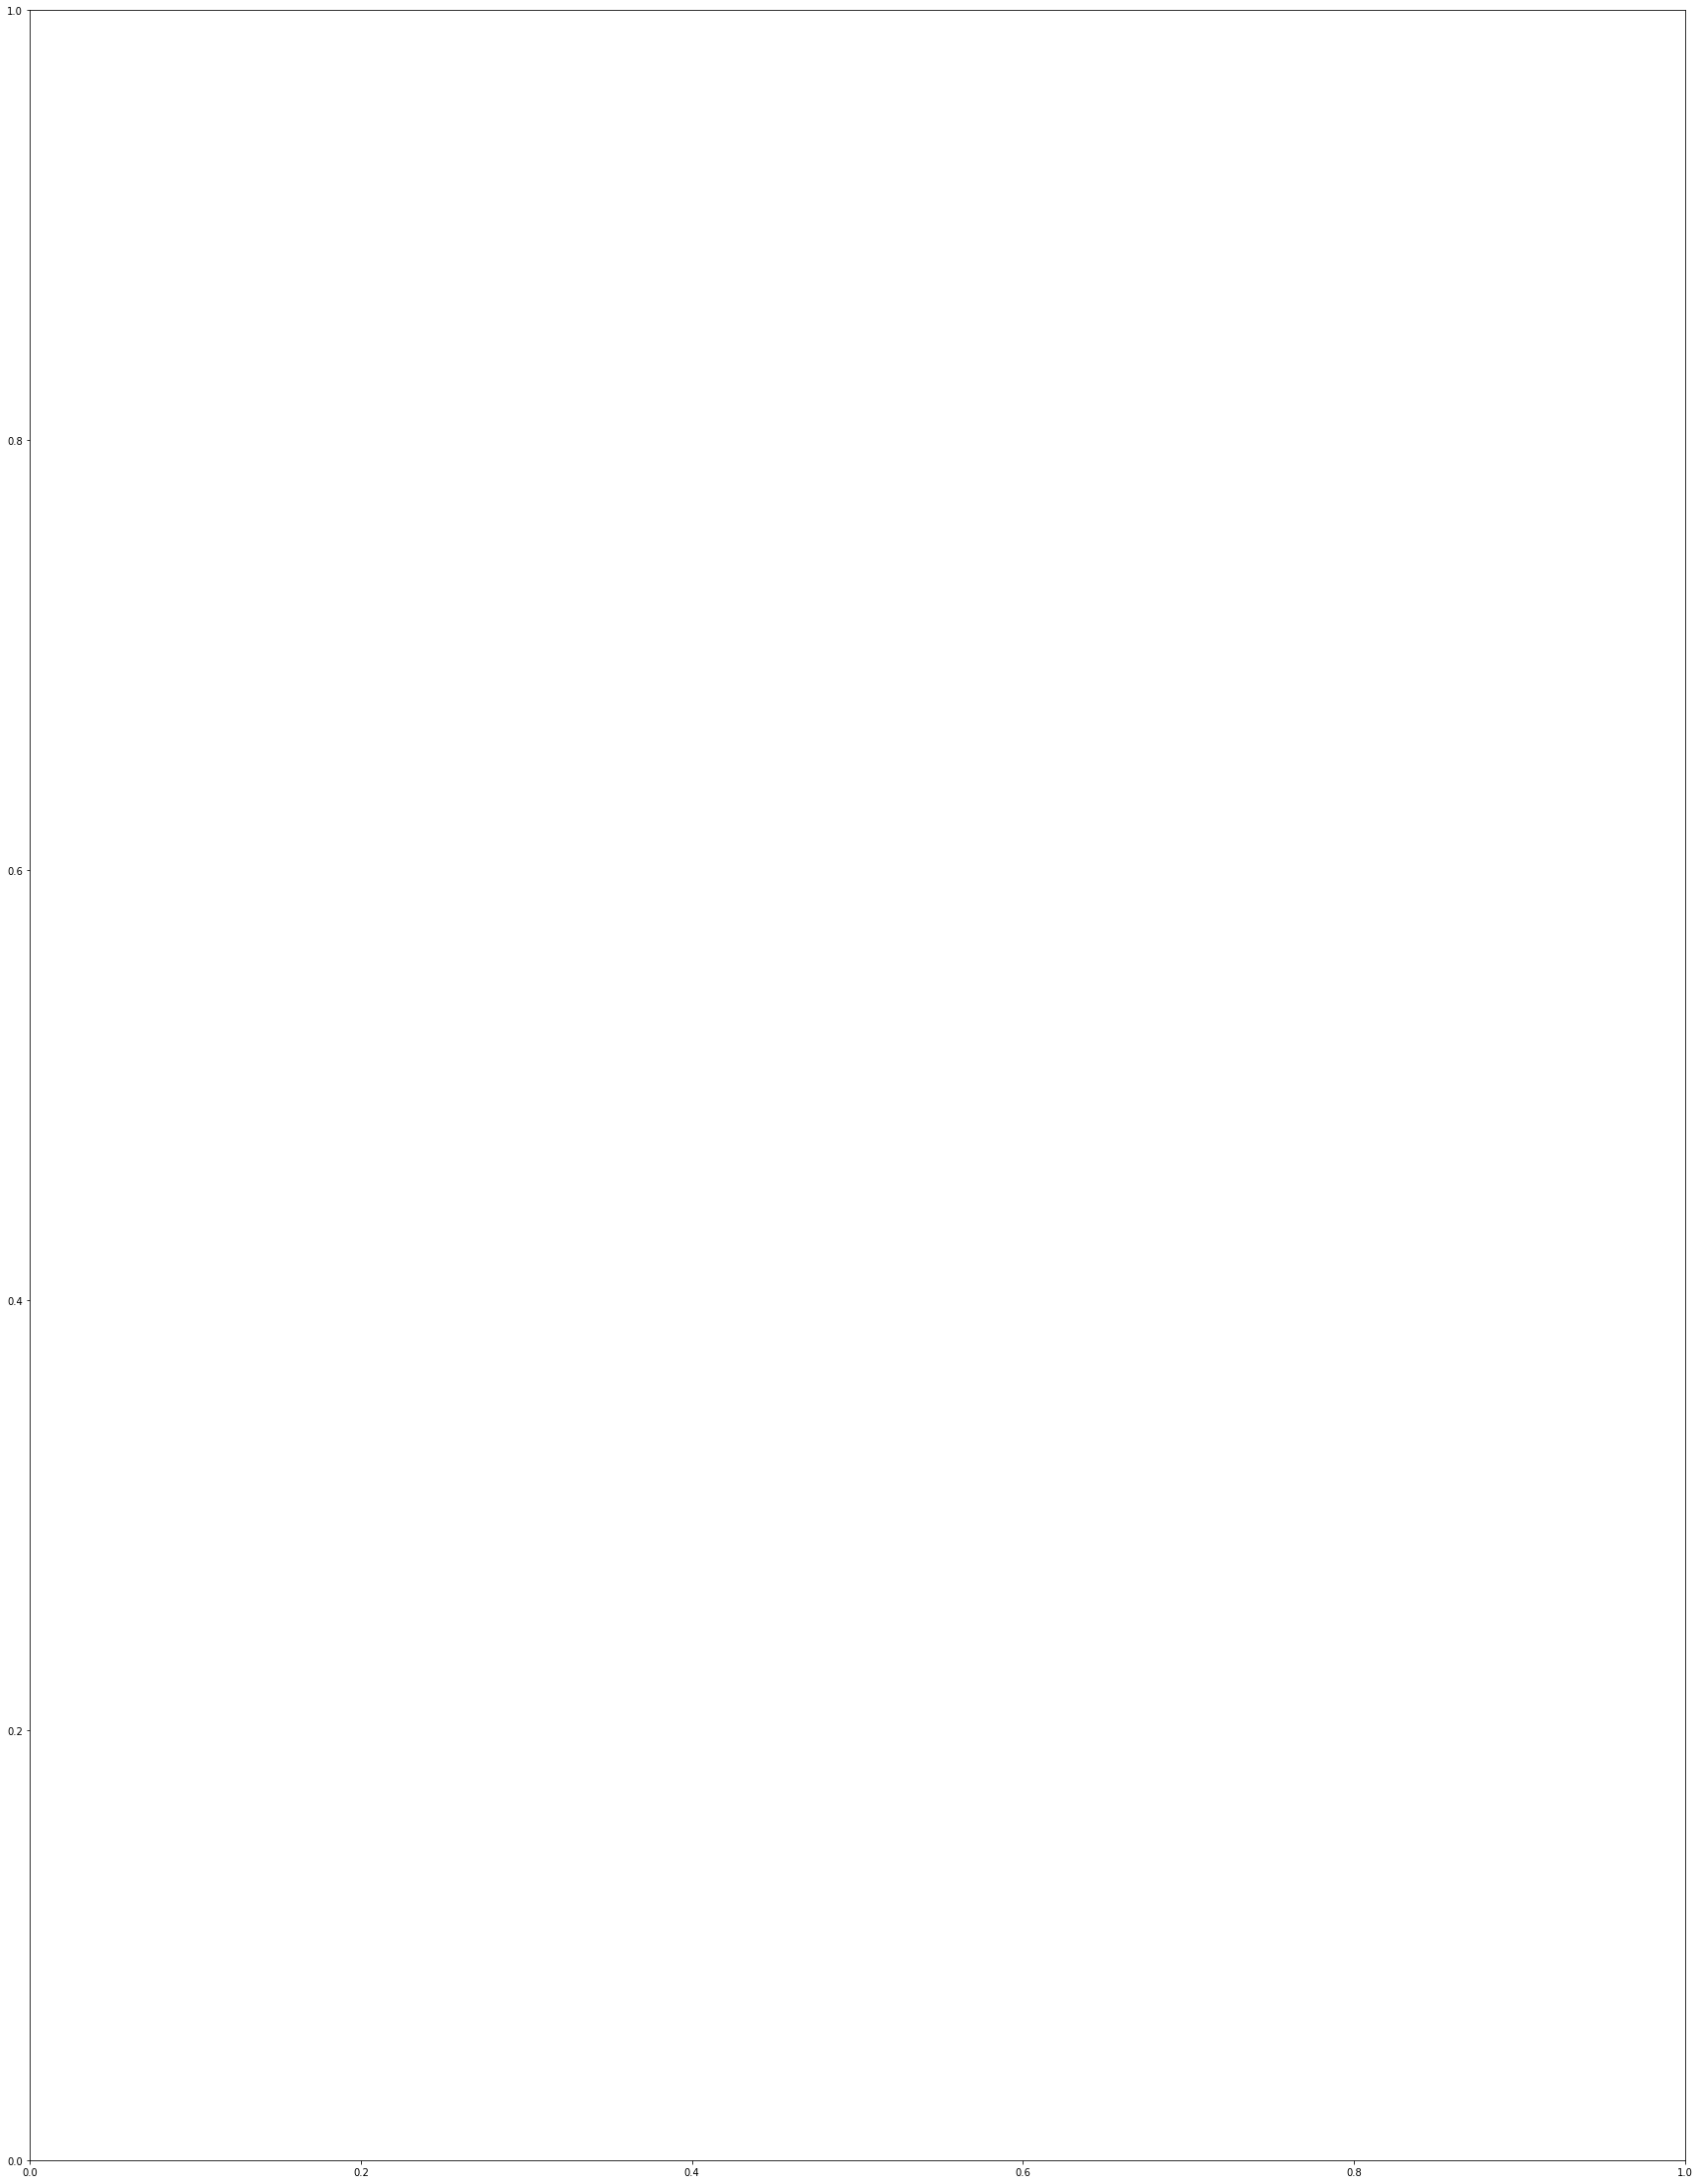

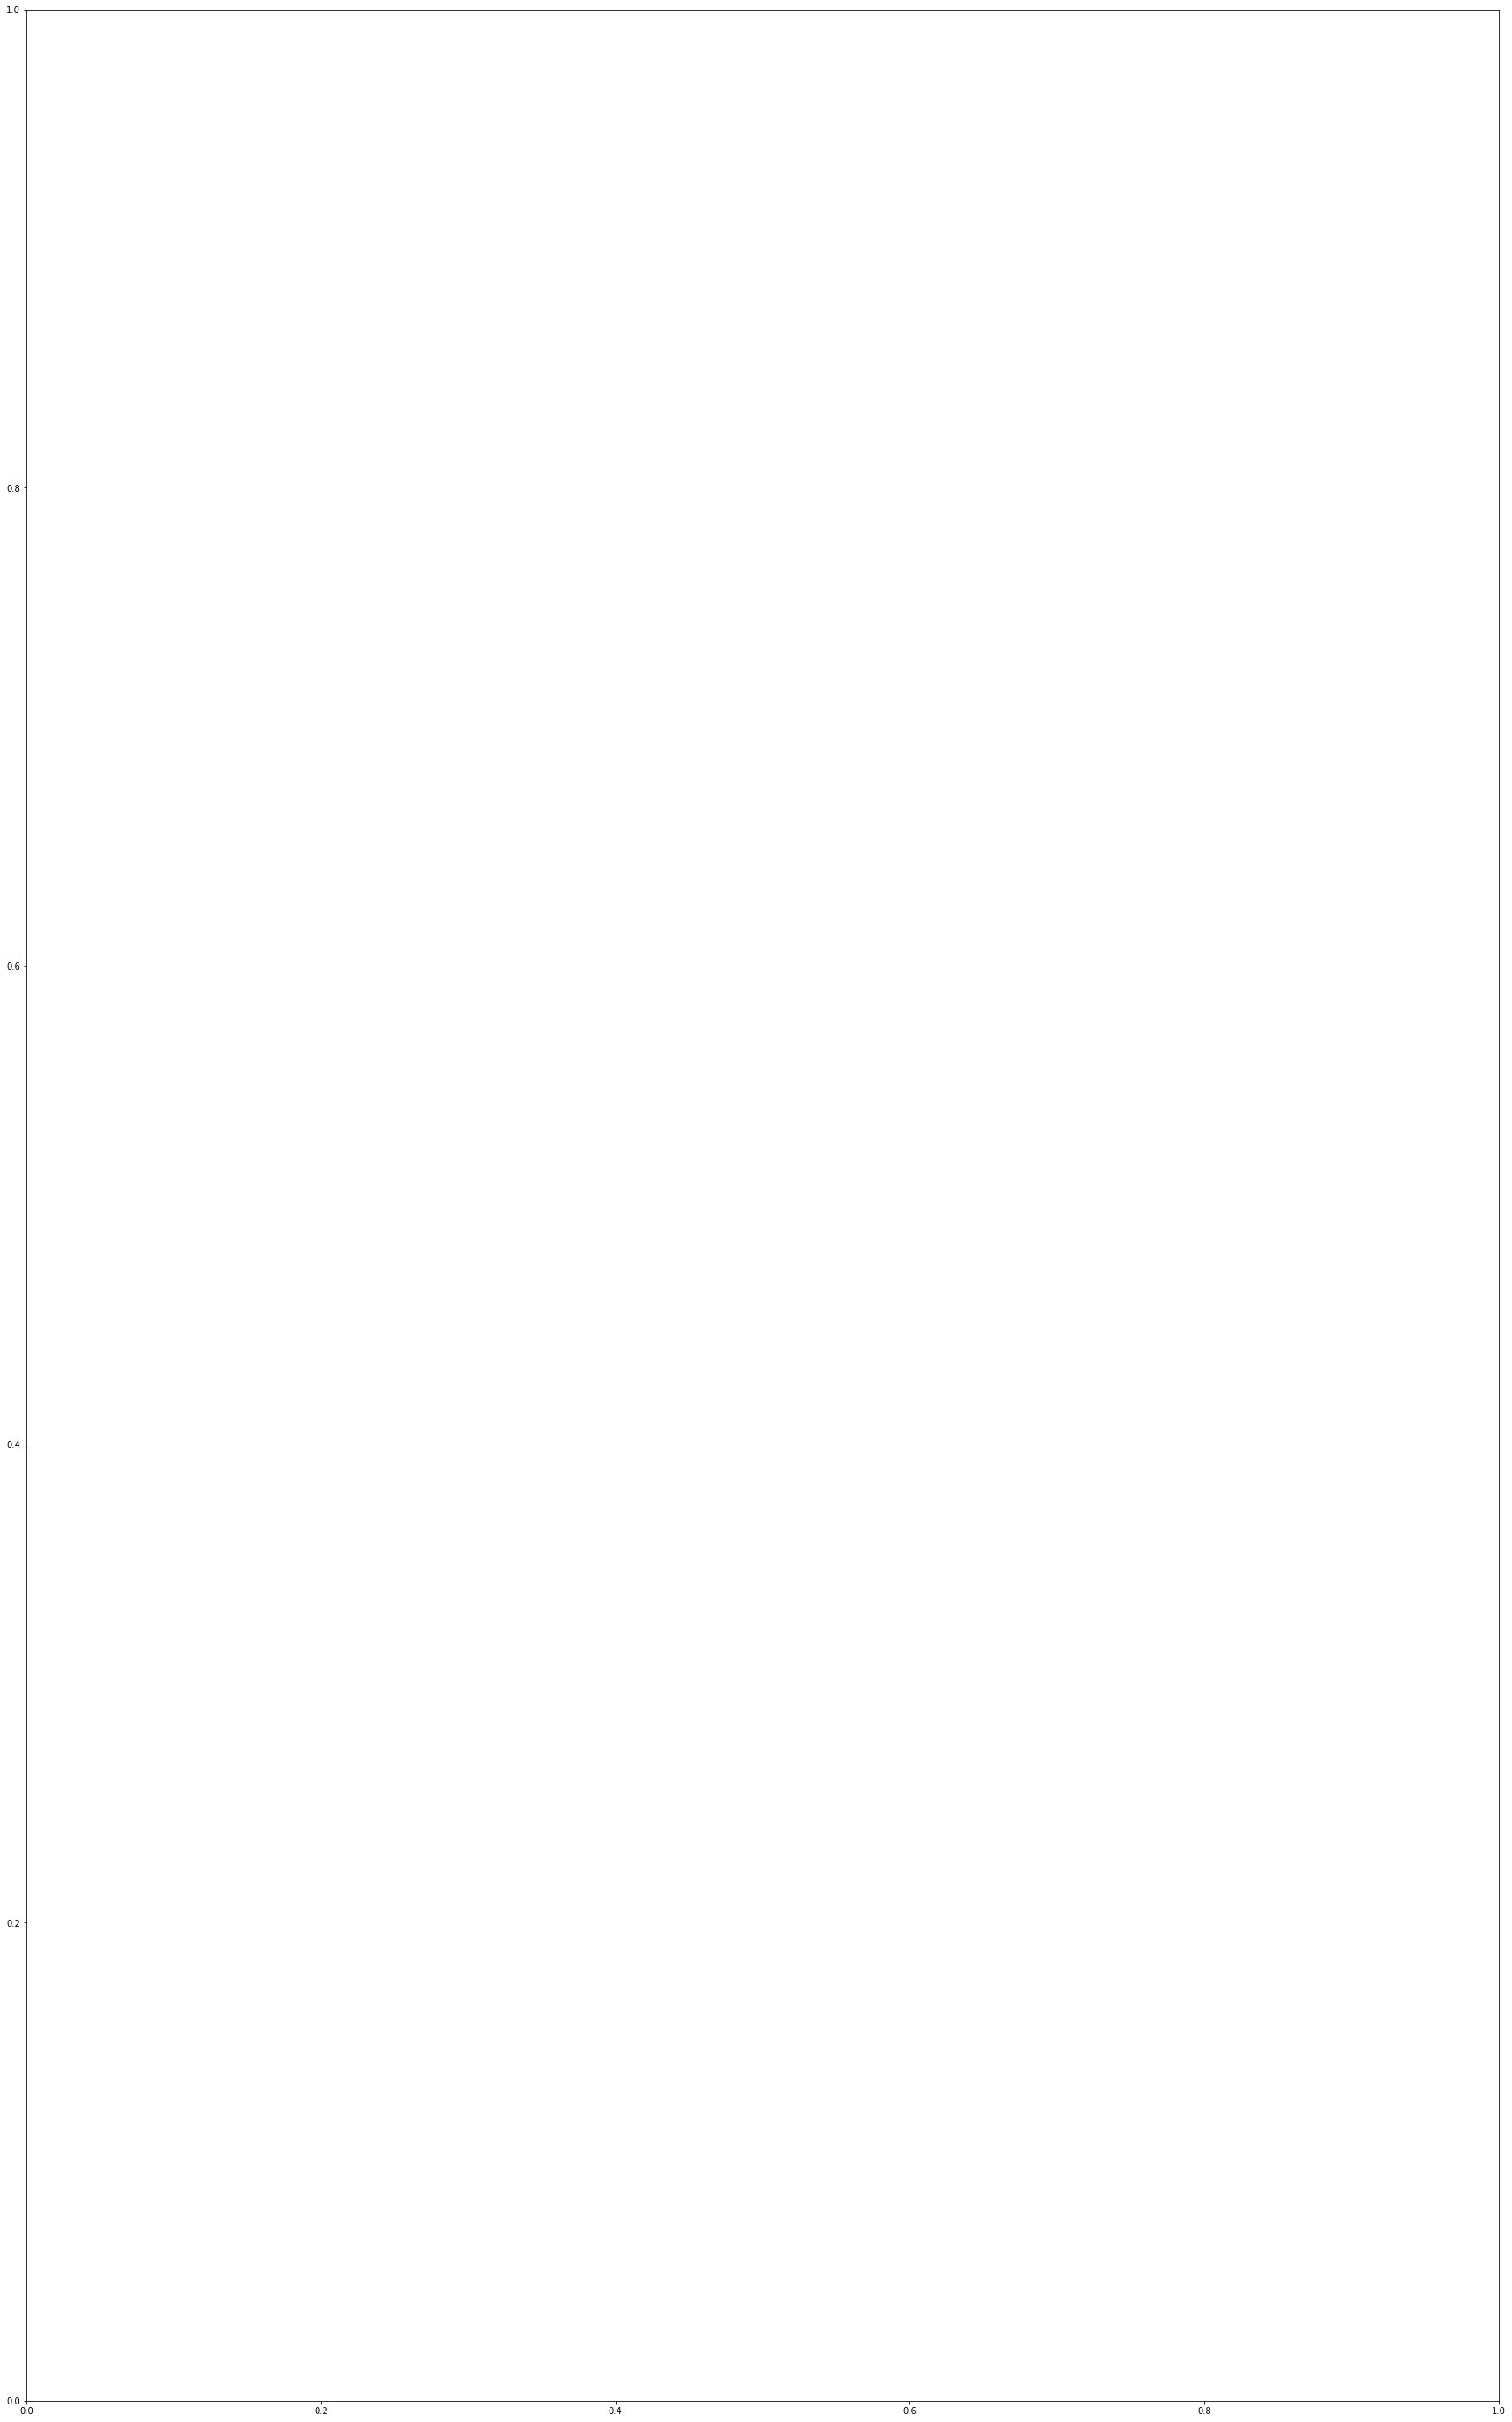

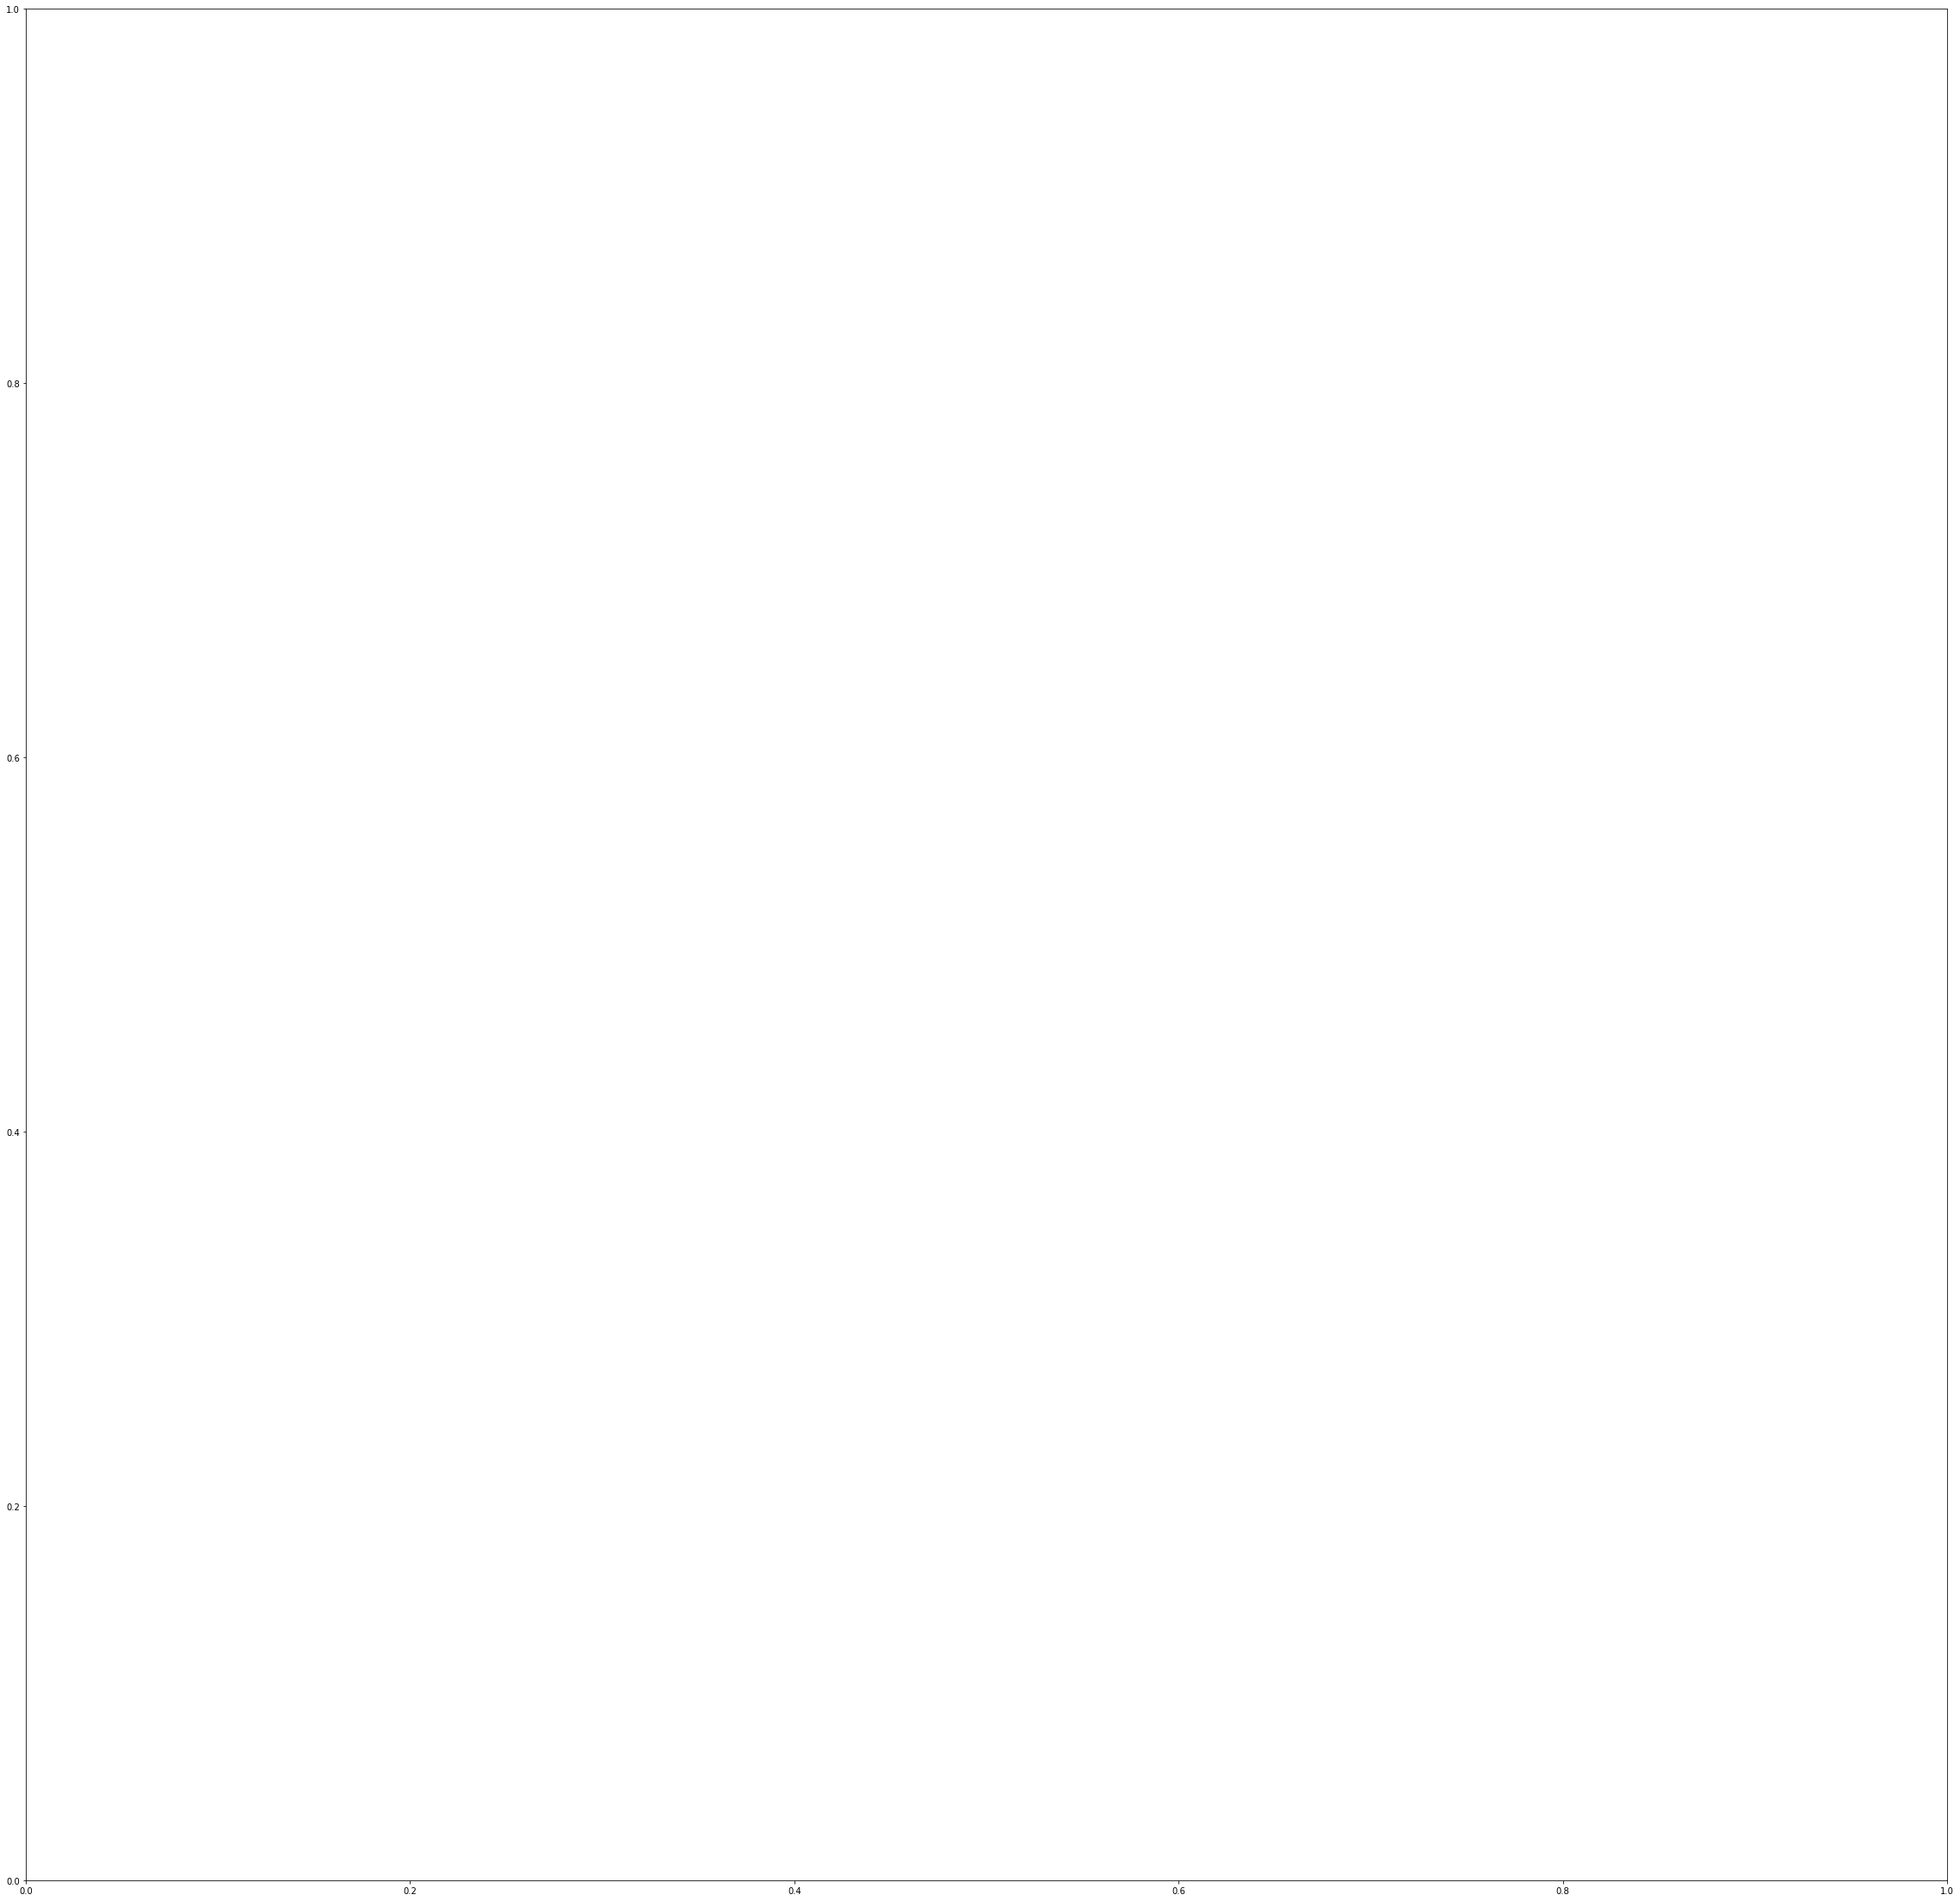

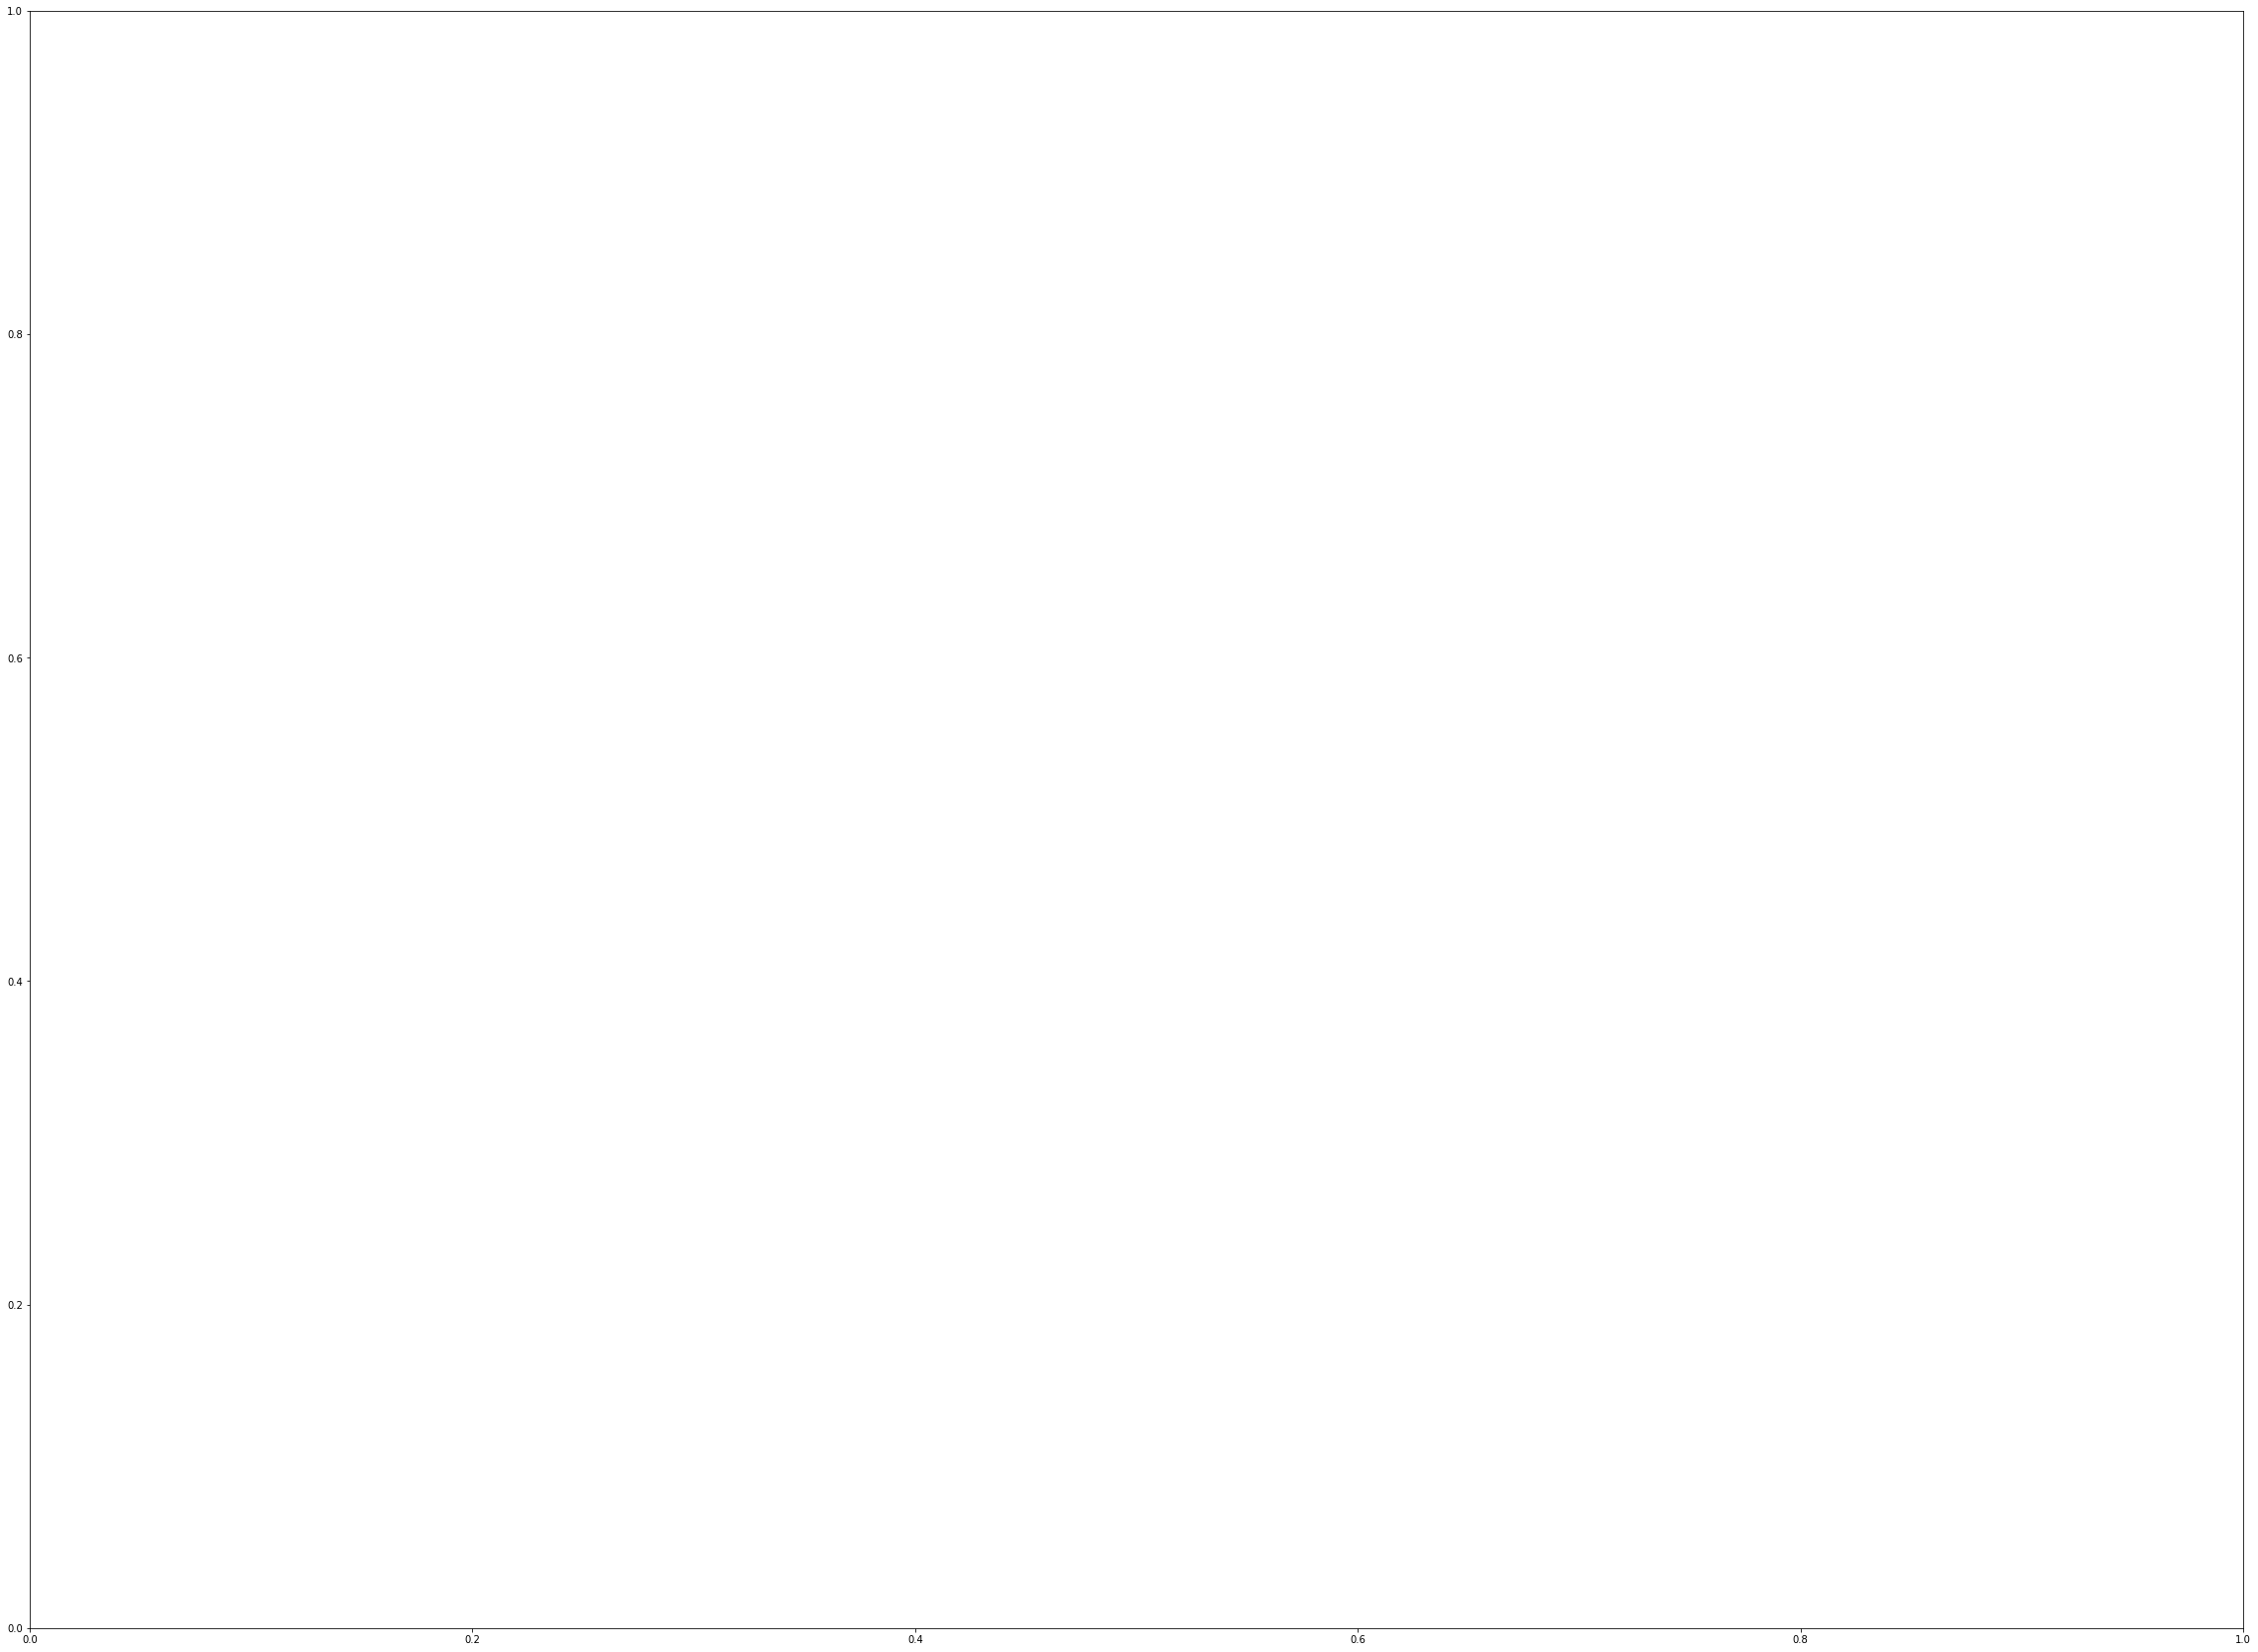

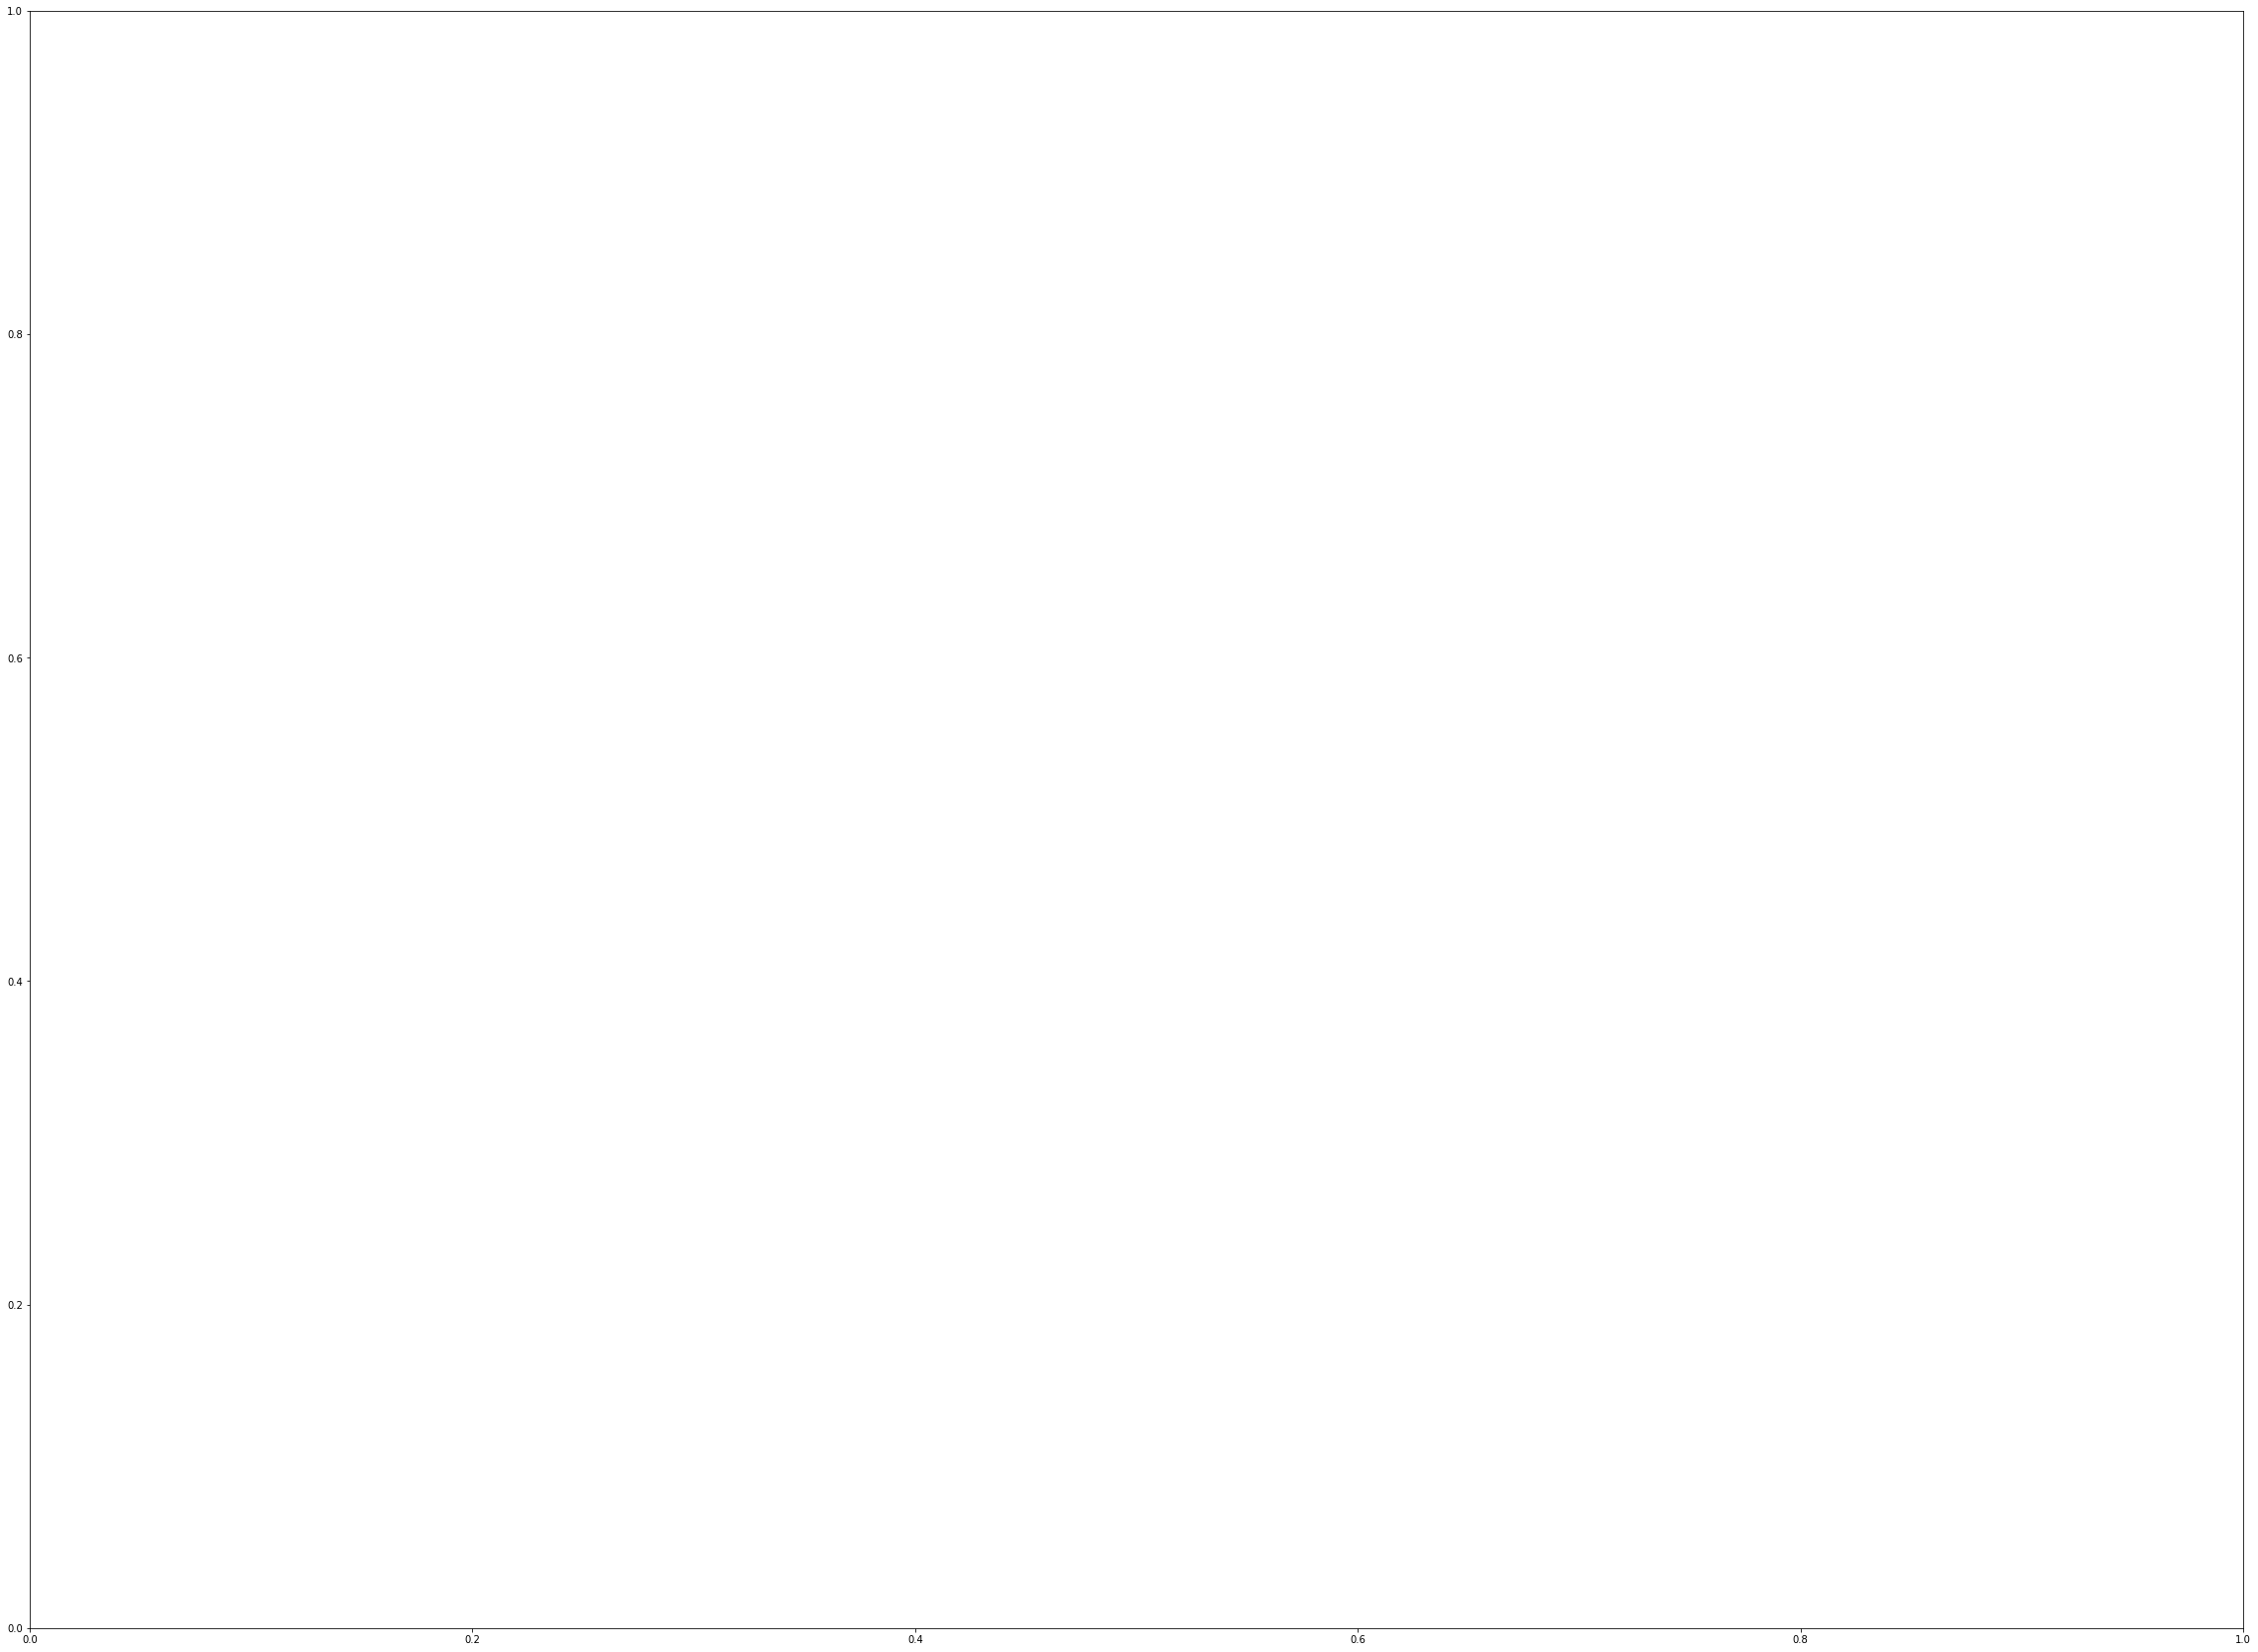

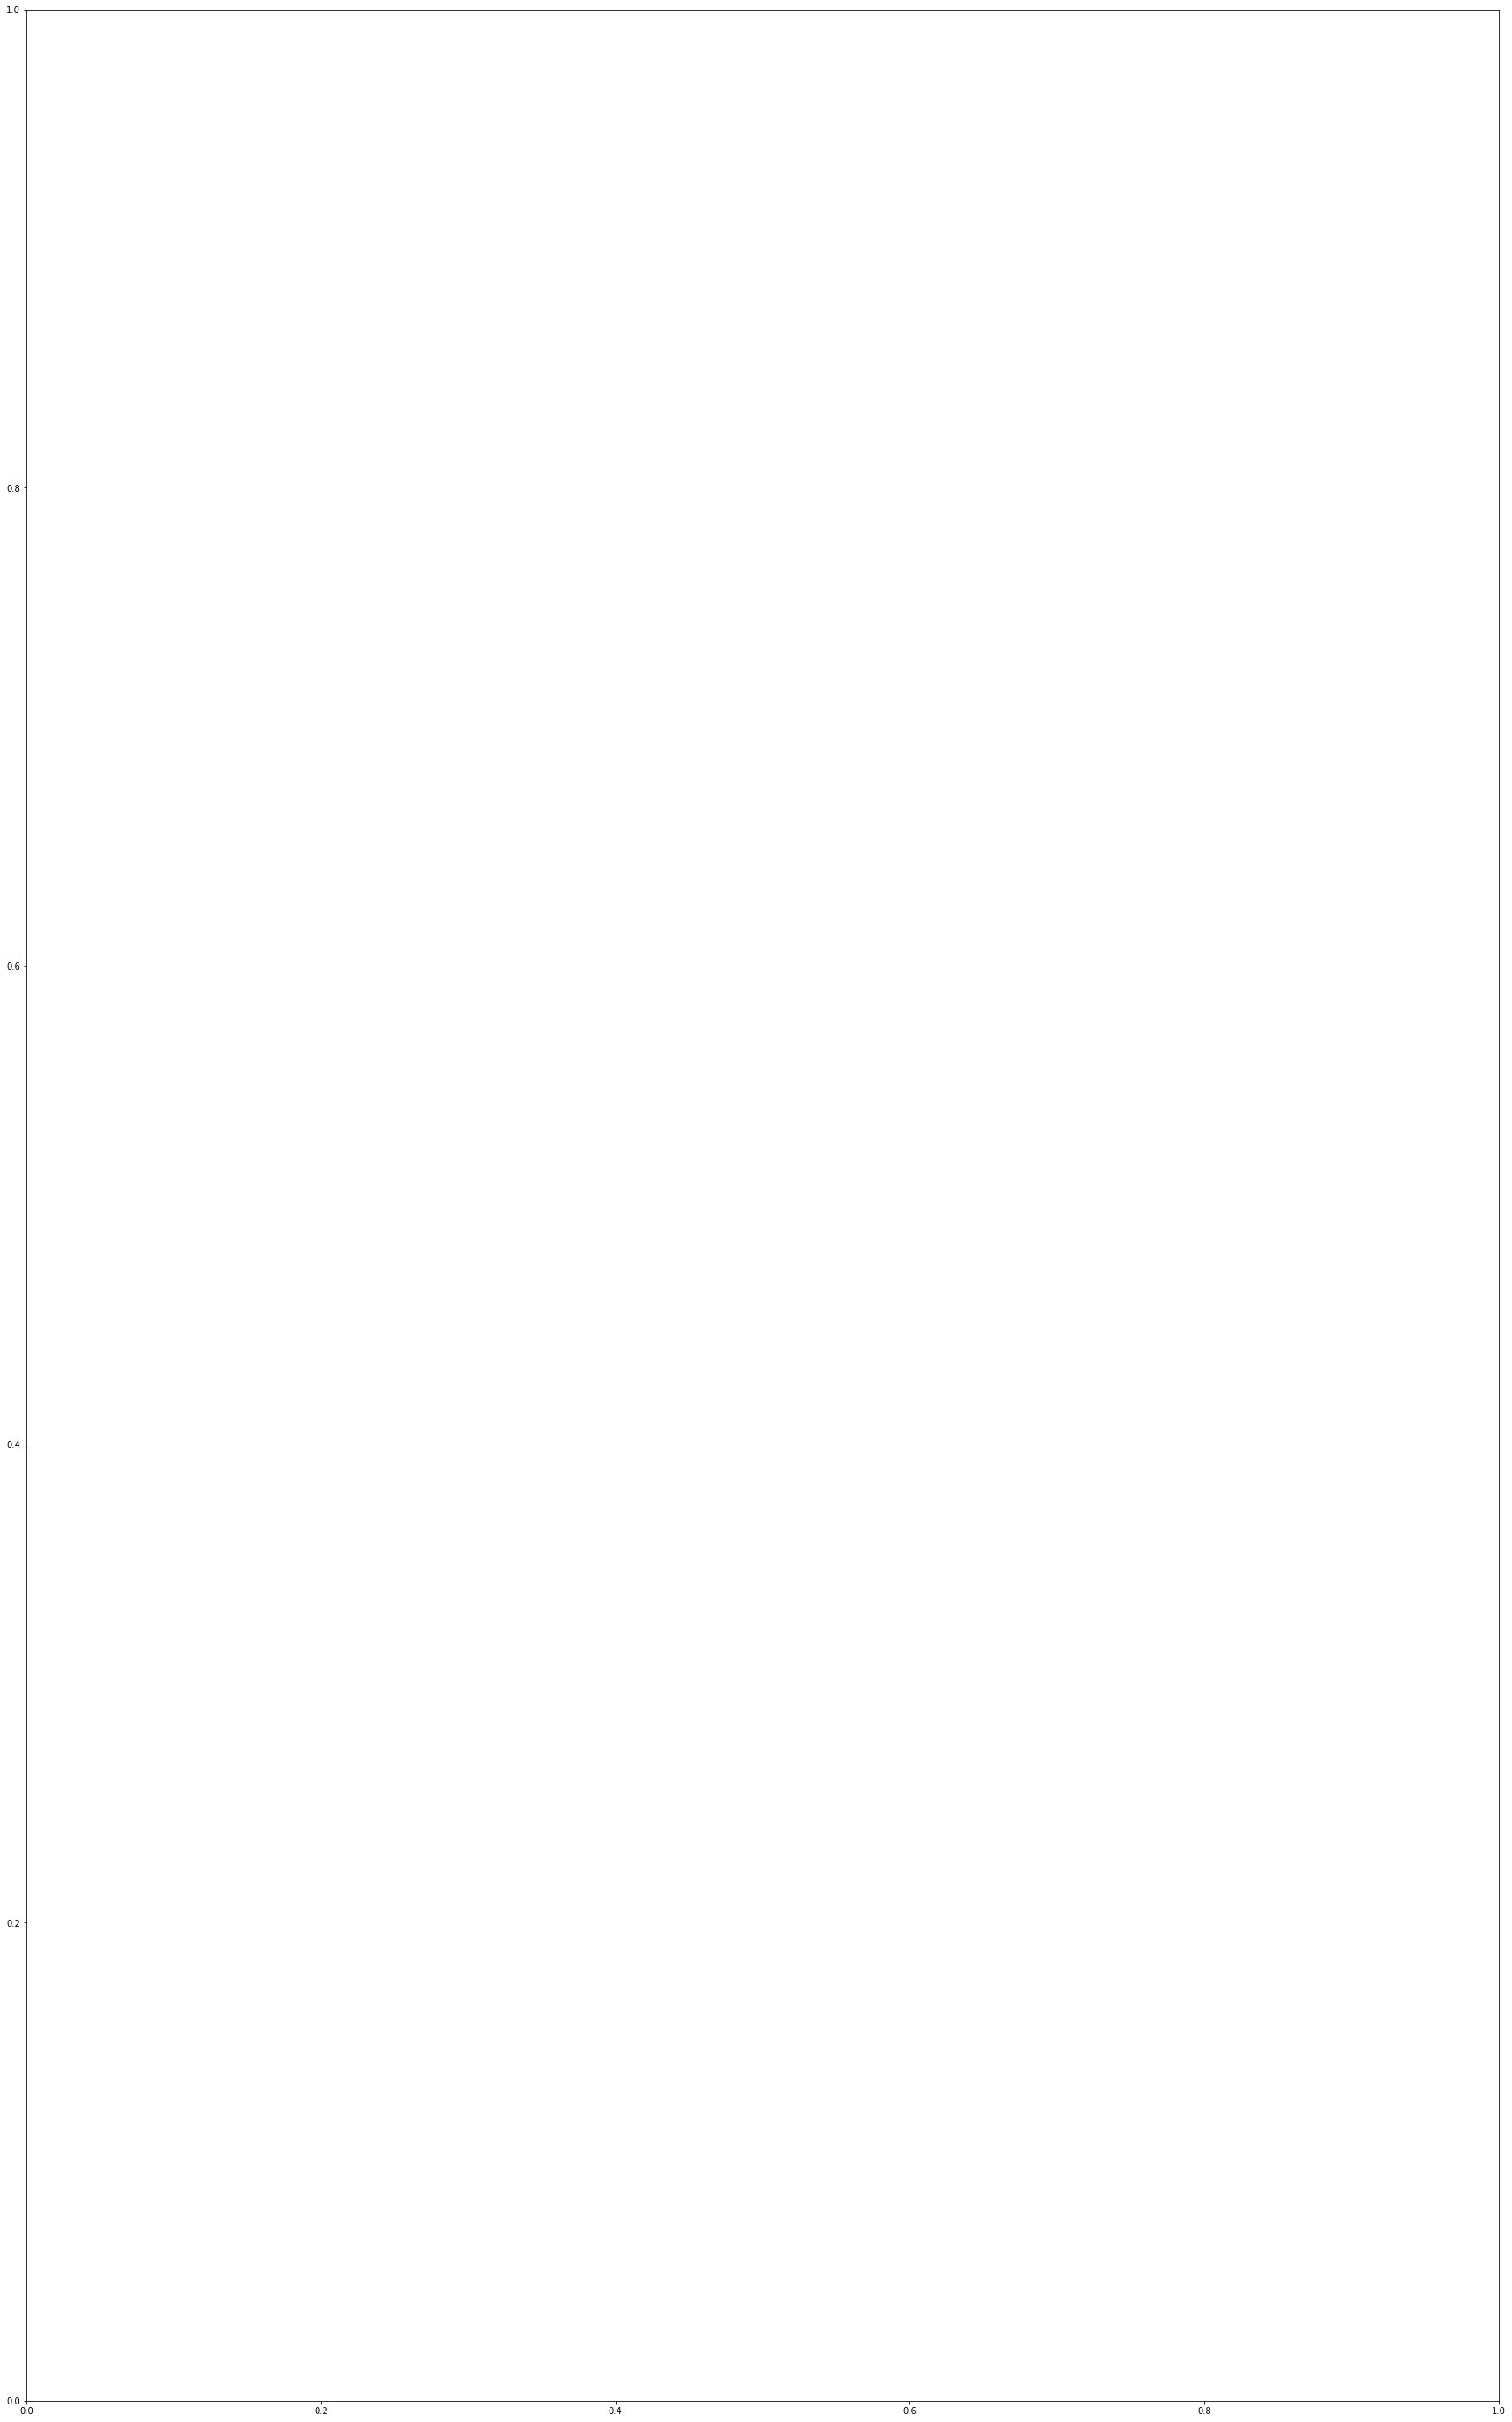

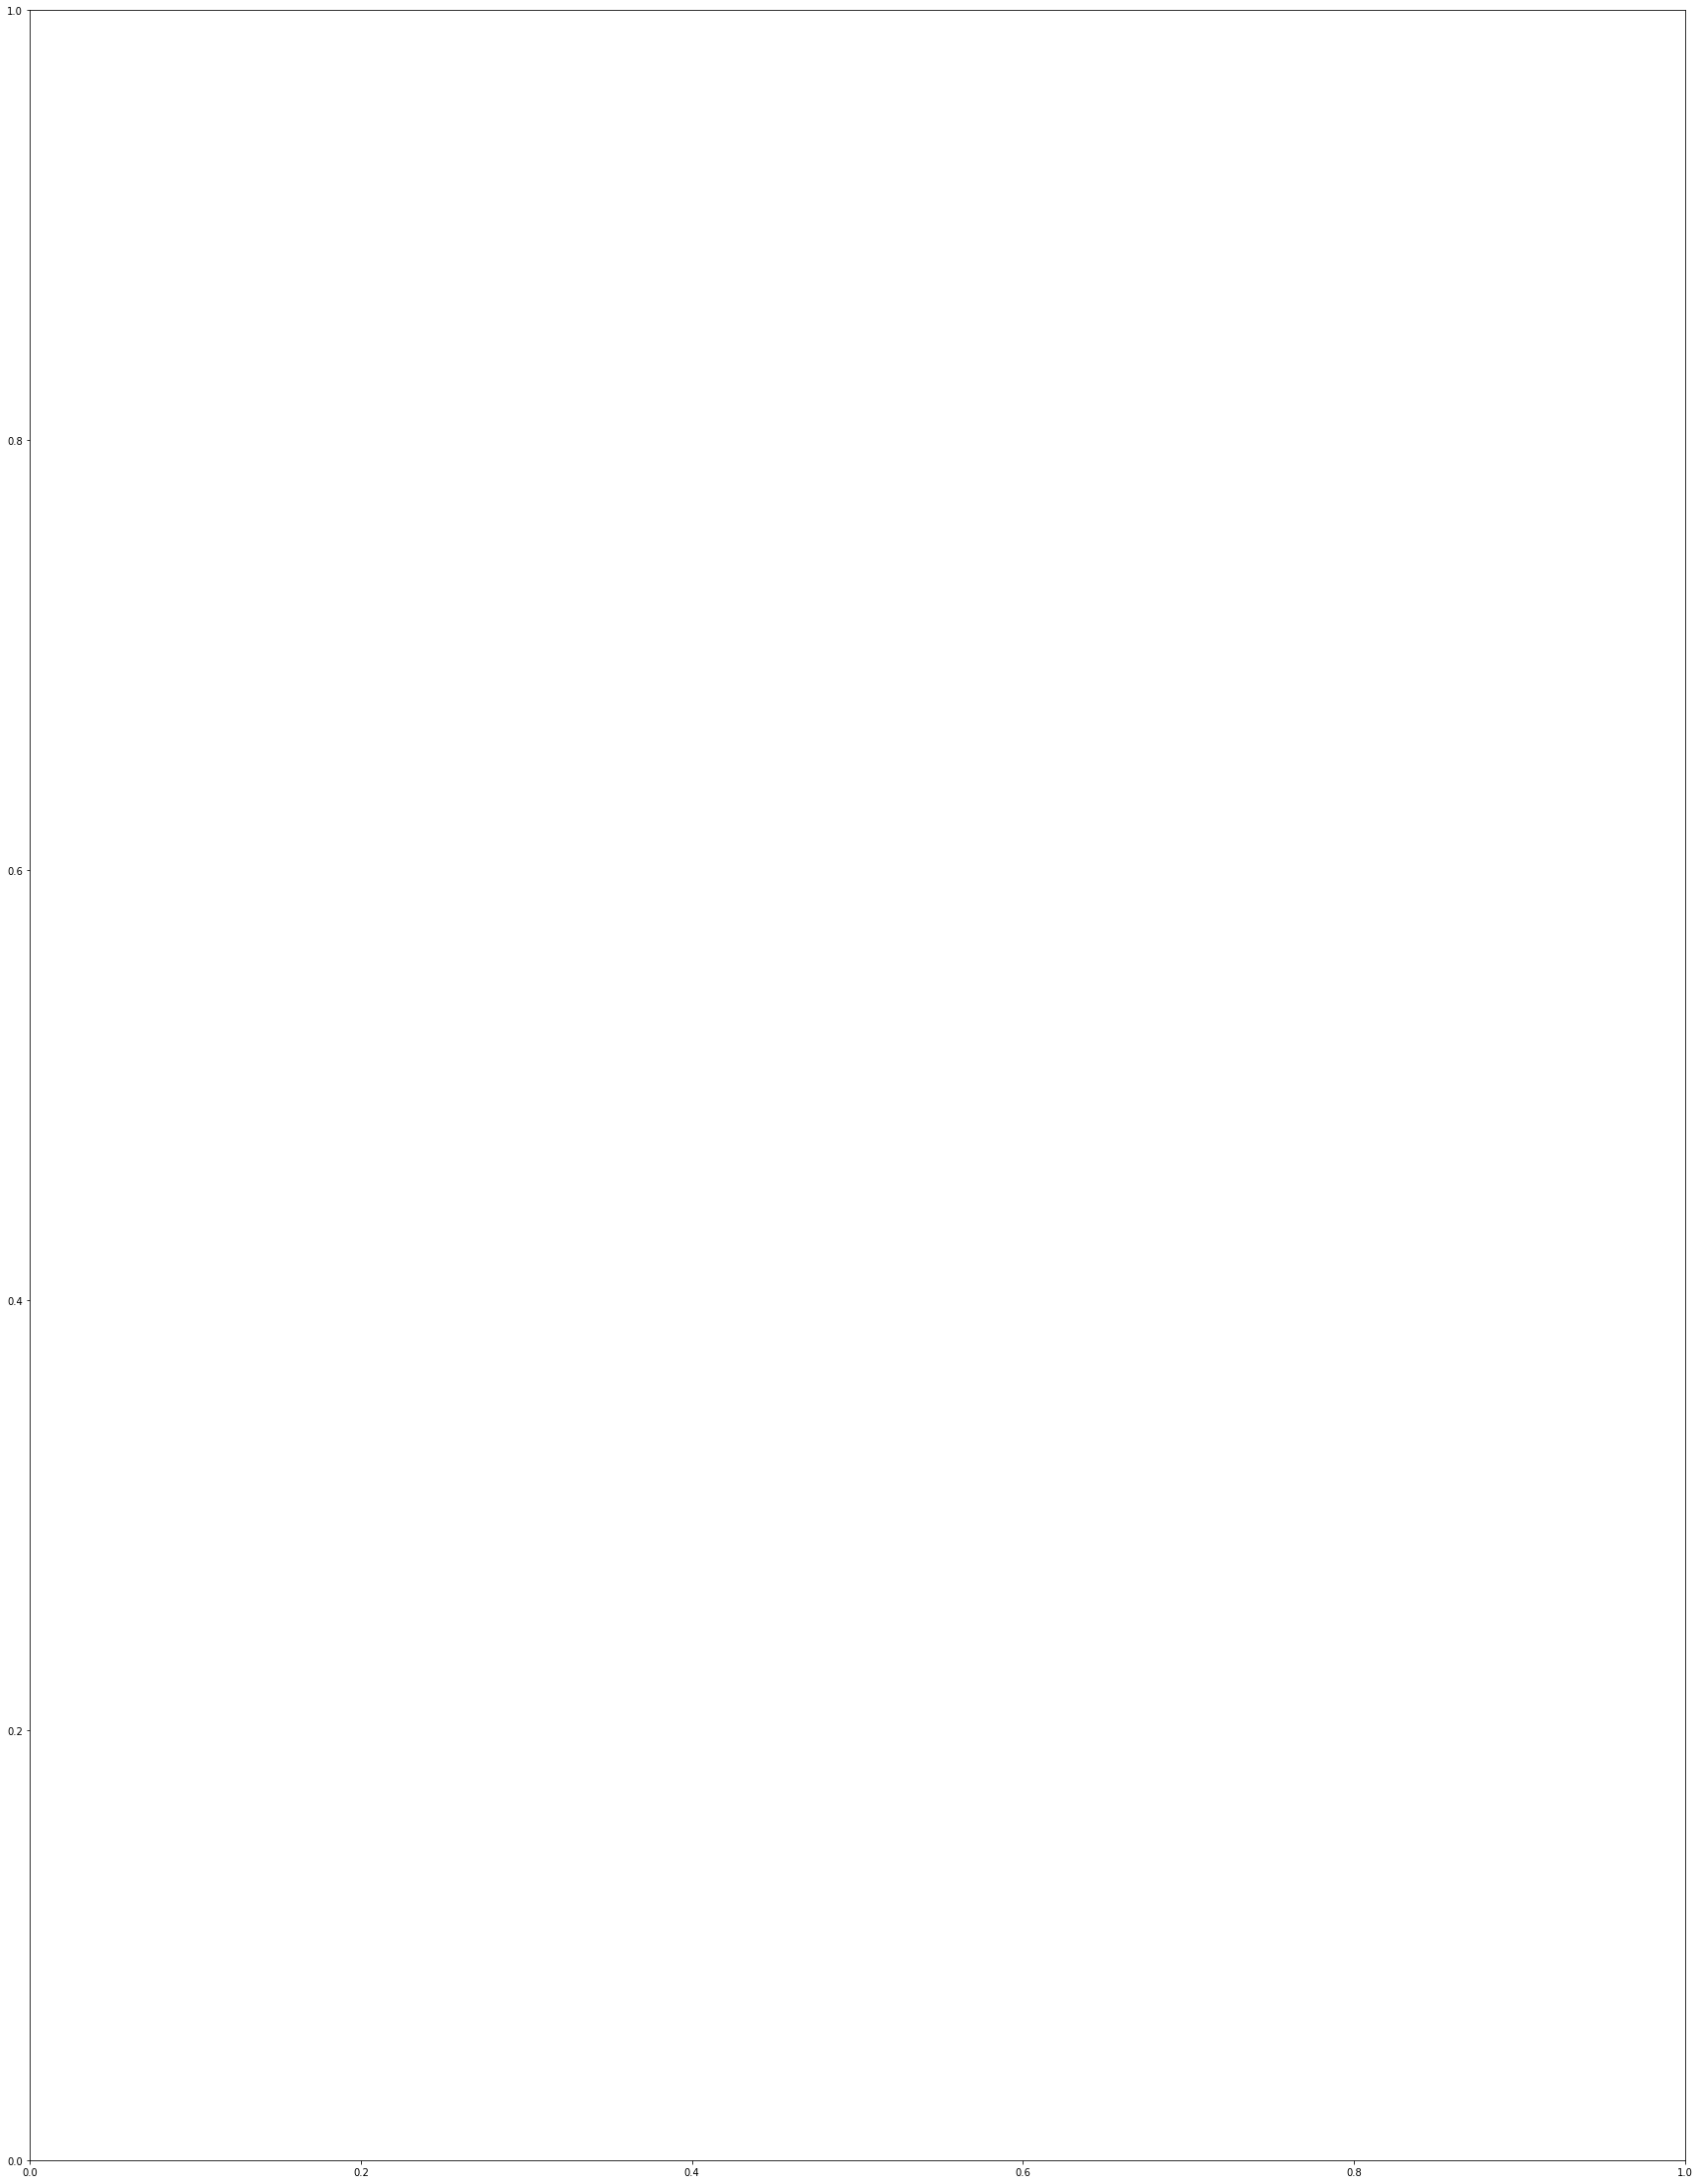

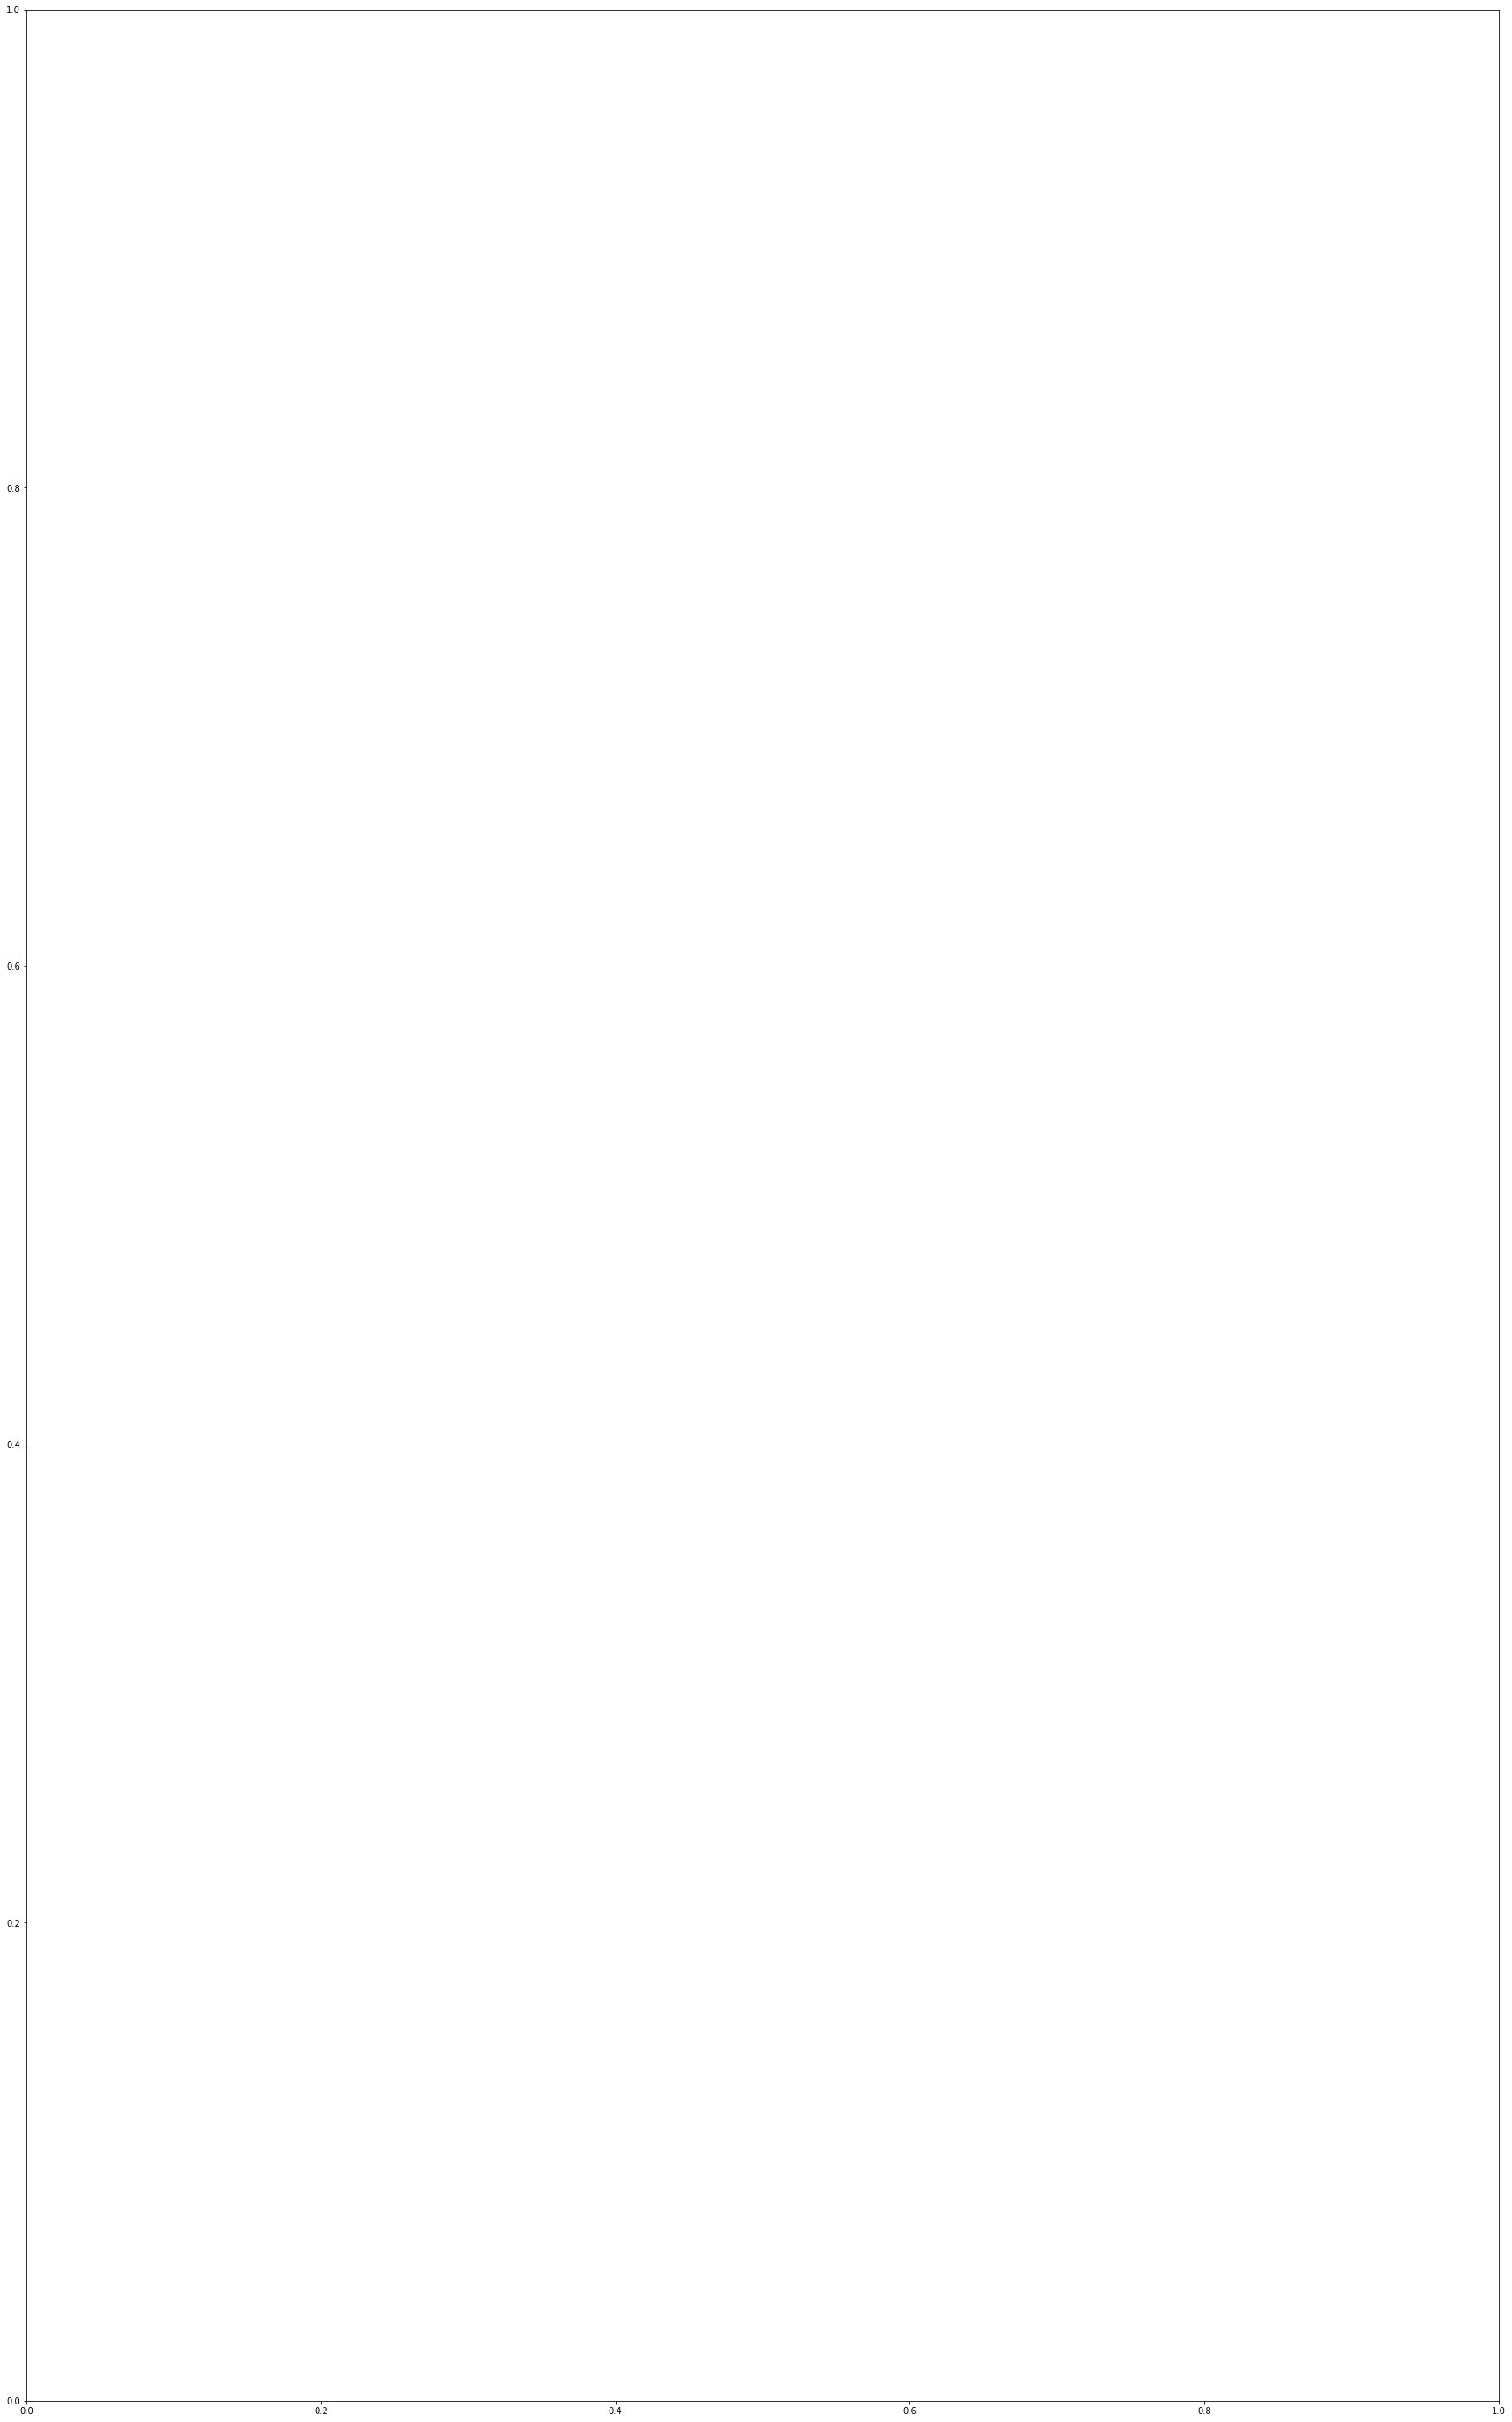

In [122]:
for t,v in clusters_by_peak.items():
    for k in v.keys():
        plot_set_profile(v,k,t)
        plt.clf()
        plt.cla()

In [8]:
# hard-code a new dictionary with changes from here: https://docs.google.com/presentation/d/1VBV9vgYXROj4KBawFU9MVDp-K7ABHCHzuYU-36WUb2Q/edit?usp=sharing
new_cdict = {
    1.0:{
        "55":2,
        "2AB":[2,1],
        "G":1,
        "19":[4,3],
        "46":[5,3],
        "1AB":3,
        "45":[1,4],
        "18":4,
        "56":4,
        "53":6,
        "48":[1,6],
        "70":5,
        "Eudy":4,
        "13":4,
        "51":6,
        "52":3
    },
    5.0:{
        "55":5,
        "53":1,
        "G":3,
        "Eudy":[6,3],
        "18":[6,1],
        "51":2,
        "56":3,
        "1AB":6,
        "46":4,
        "45":5,
        "52":5,
        "48":5,
        "13":2
    },
    9.0:{
        "45":2,
        "18":5,
        "48":4,
        "G":[2,6],
        "19":1,
        "13":5,
        "52":1,
        "51":4,
        "53":4,
        "70":3,
        "56":1,
        "1AB":2,
        "46":6,
        "2AB":3
    },
    13.0:{
        "55":[3,4],
        "56":6,
        "1AB":4,
        "13":3,
        "Eudy":1,
        "46":2,
        "51":5,
        "70":2,
        "2AB":4,
        "52":4,
        "G":5,
        "19":2
    },
    17.0:{
        "Eudy":5,
        "13":6,
        "56":2,
        "53":3,
        "46":1,
        "45":6,
        "2AB":6,
        "19":6,
        "51":1,
        "48":3,
        "13":[1,6],
        "55":1,
        "70":1,
        "52":6,
        "18":2
    },
    21.0:{
        "48":2,
        "52":2,
        "19":5,
        "G":4,
        "45":3,
        "53":[5,2],
        "70":[4,6],
        "55":6,
        "56":5,
        "Eudy":2,
        "1AB":[5,1],
        "18":3,
        "51":3,
        "2AB":5
    }
}


In [105]:
# check that each cluster appears in this dict exactly once
def check_gt(gt):
    for k,v in new_cdict.items():
        if gt in v.keys():
            print("Cluster of genotype "+gt+" in group ZT"+str(k)+": "+str(v[gt]))

In [47]:
genotypes = list(allgt.keys())
genotypes

['G',
 'Eudy',
 '13',
 '45',
 '19',
 '51',
 '2AB',
 '52',
 '46',
 '70',
 '48',
 '37',
 '55',
 '18',
 '53',
 '56',
 'all',
 '1AB']

In [48]:
genotypes.remove("all")
genotypes.remove("37")

In [142]:
for i in genotypes:
    check_gt(i)
    print("\n")

Cluster of genotype G in group ZT1.0: 1
Cluster of genotype G in group ZT5.0: 3
Cluster of genotype G in group ZT9.0: [2, 6]
Cluster of genotype G in group ZT13.0: 5
Cluster of genotype G in group ZT21.0: 4


Cluster of genotype Eudy in group ZT1.0: 4
Cluster of genotype Eudy in group ZT5.0: [6, 3]
Cluster of genotype Eudy in group ZT13.0: 1
Cluster of genotype Eudy in group ZT17.0: 5
Cluster of genotype Eudy in group ZT21.0: 2


Cluster of genotype 13 in group ZT1.0: 4
Cluster of genotype 13 in group ZT5.0: 2
Cluster of genotype 13 in group ZT9.0: 5
Cluster of genotype 13 in group ZT13.0: 3
Cluster of genotype 13 in group ZT17.0: [1, 6]


Cluster of genotype 45 in group ZT1.0: [1, 4]
Cluster of genotype 45 in group ZT5.0: 5
Cluster of genotype 45 in group ZT9.0: 2
Cluster of genotype 45 in group ZT17.0: 6
Cluster of genotype 45 in group ZT21.0: 3


Cluster of genotype 19 in group ZT1.0: [4, 3]
Cluster of genotype 19 in group ZT9.0: 1
Cluster of genotype 19 in group ZT13.0: 2
Cluster o

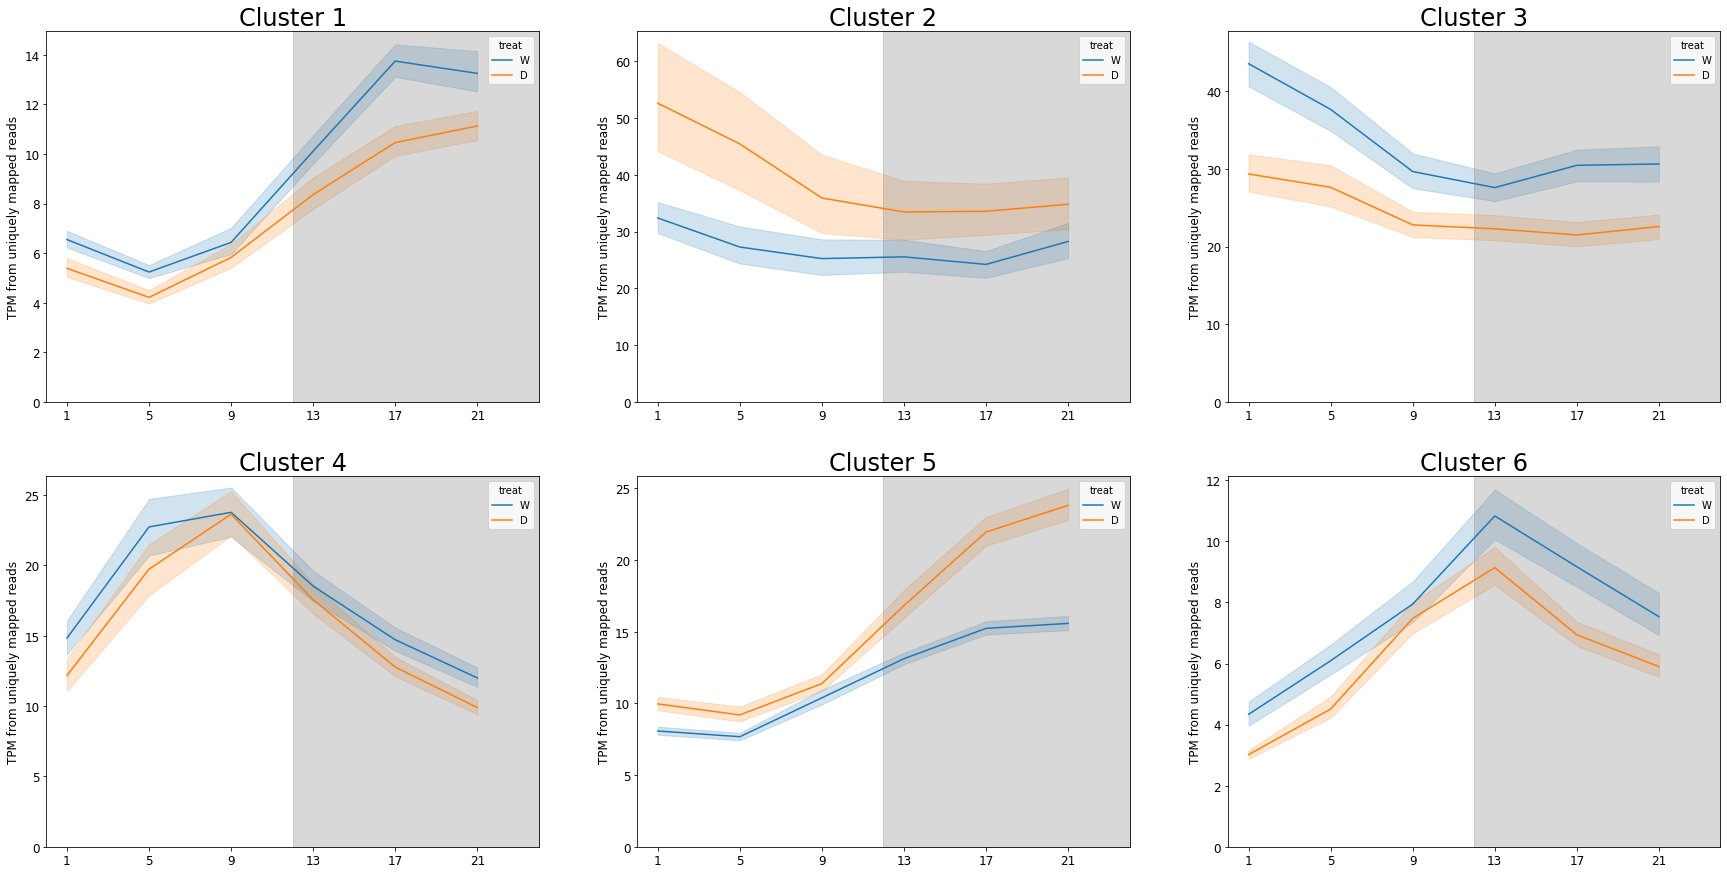

In [144]:
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(30,15))
plot_profile(1,plottpm(zttpm,1,"37"),(0,0),ax,24)
plot_profile(2,plottpm(zttpm,2,"37"),(0,1),ax,24)
plot_profile(3,plottpm(zttpm,3,"37"),(0,2),ax,24)
plot_profile(4,plottpm(zttpm,4,"37"),(1,0),ax,24)
plot_profile(5,plottpm(zttpm,5,"37"),(1,1),ax,24)
plot_profile(6,plottpm(zttpm,6,"37"),(1,2),ax,24)

In [9]:
# manually add clusters of genotype 37
new_cdict[21.0]["37"] = [1,5]
new_cdict[1.0]["37"] = [2,3]
new_cdict[9.0]["37"] = 4
new_cdict[13.0]["37"] = 6

In [149]:
def plottpm_all(tpm,c):
    cinfo = allgt["all"]["clusters"]
    cinfo = cinfo[cinfo["cluster"]==c]
    cgenes = list(cinfo["GeneID"].unique())
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    plong = pd.melt(pwide,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    return plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)

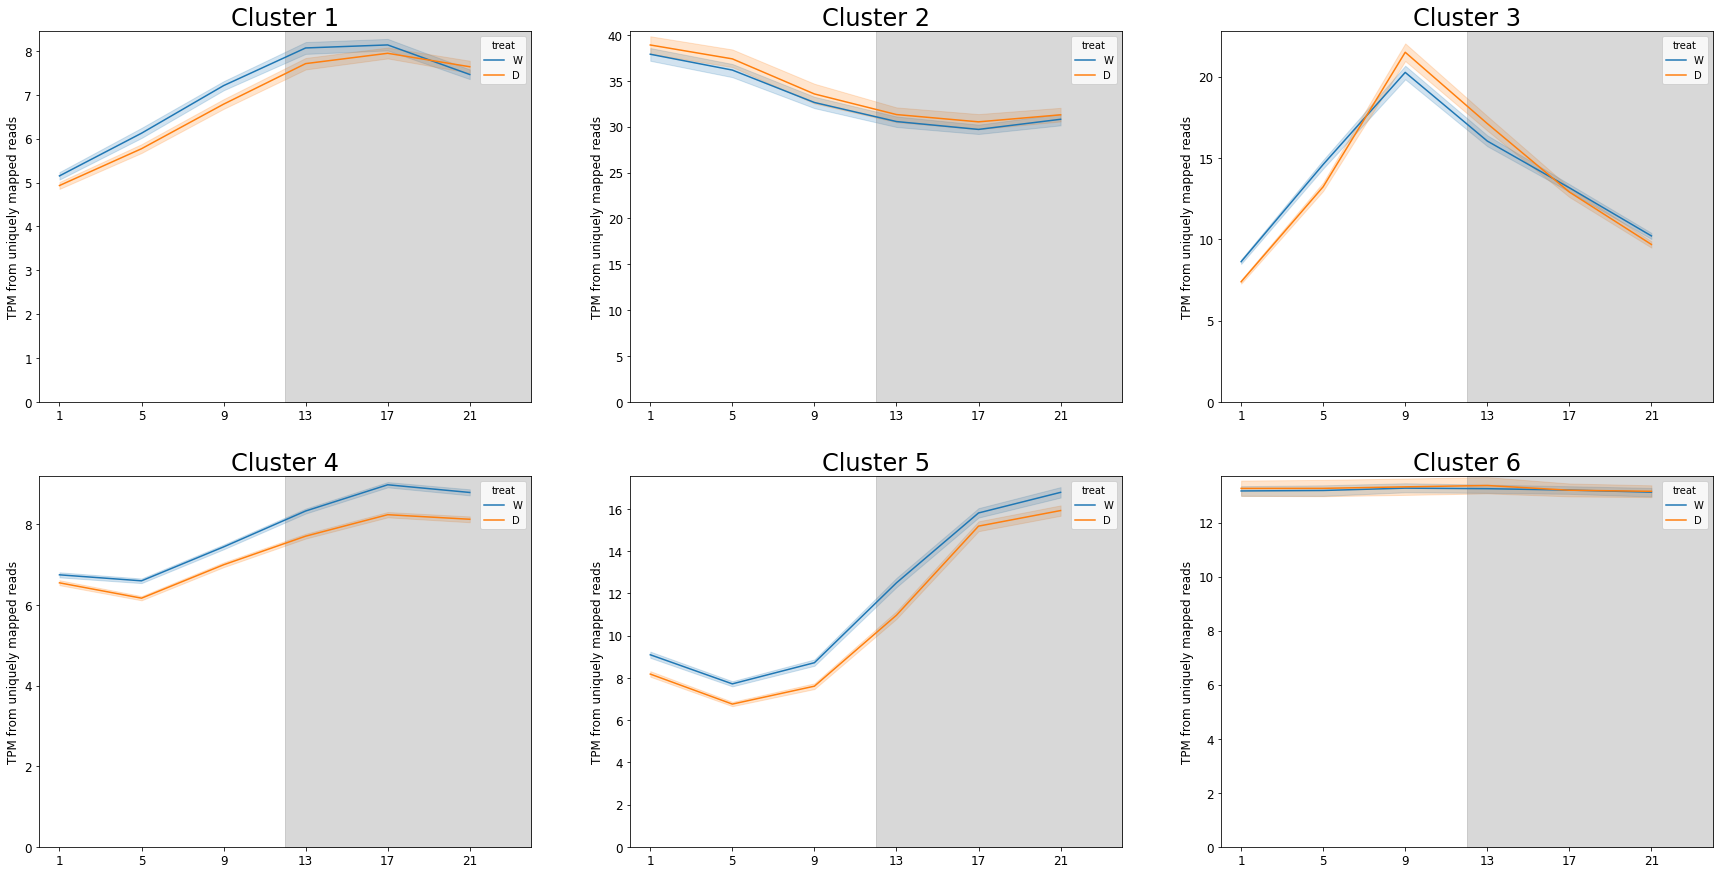

In [166]:
# do the same for all genotypes
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(30,15))
plot_profile(1,plottpm_all(zttpm,1),(0,0),ax,24)
plot_profile(2,plottpm_all(zttpm,2),(0,1),ax,24)
plot_profile(3,plottpm_all(zttpm,3),(0,2),ax,24)
plot_profile(4,plottpm_all(zttpm,4),(1,0),ax,24)
plot_profile(5,plottpm_all(zttpm,5),(1,1),ax,24)
plot_profile(6,plottpm_all(zttpm,6),(1,2),ax,24)

In [189]:
new_cdict[21.0]

{'48': 2,
 '52': 2,
 '19': 5,
 'G': 4,
 '45': 3,
 '53': [5, 2],
 '70': [4, 6],
 '55': 6,
 '56': 5,
 'Eudy': 2,
 '1AB': [5, 1],
 '18': 3,
 '51': 3,
 '2AB': 5,
 '37': [1, 5]}

In [167]:
zttpm.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.0,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.0,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.0,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418
5,Y104,1AB,6.0,W,21.0,gloriosa,54.385723,5.745473,0.0,17.707487,...,0.0,1.325587,20.929404,2.159383,7.363694,0.000000,2.504658,15.673893,0.0,0.000000
6,Y105,18,6.0,W,21.0,gloriosa,47.391406,8.458668,0.0,15.536940,...,0.0,7.491513,2.153592,6.520598,14.513037,2.782378,2.331412,20.726688,0.0,0.000000


In [168]:
tpmz = zttpm.set_index(["sample_name","genotype","time","treat","ZT","species"])
tpmz["max_per_sample"] = tpmz.max(axis=1)

In [170]:
min(tpmz["max_per_sample"])

4683.259390460849

In [22]:
# make a function to plot these sets of clusters together (to confirm their similarity)
def plot_set_profile(d,zt,treatment="all",tpm=zttpm,log=False):
    ## things to set up based on parameters:
    # nr = nrows
    # nc = ncols
    # h = plot height
    # w = plot width
    
    # argument: treatment can be equal to "all", "W", or "D"
    
    setdict = d[zt]
    
    # set up nplots
    #nplots = len(setdict.keys())
    nplots = 0
    for i in setdict.values():
        if type(i)==list:
            nplots+=len(i)
        else:
            nplots+=1
    
    # set up nr & nc
    if nplots % 4 == 0:
        nc = 4
        nr = int(nplots/4)
    else:
        if nplots % 3 == 0:
            nc = 3
            nr = int(nplots/3)
        elif nplots > 20:
            nc = 4
            nr = int((nplots/4)+1)
        else:
            nc = 3
            nr = int((nplots/3)+1)
            
    # set up w & h depending on nc & nr
    w = 10*nc
    h = 10*nr
    # set up font sizes depending on nc & nr
    if nc==4:
        stf = 36
        tf = 28
    else:
        stf = 30
        tf = 24
    
    fig,ax = plt.subplots(nrows=nr,ncols=nc,figsize=(w,h))
    
    r=0
    j=0
    
    # plot each cluster from setdict
    for g,c in setdict.items():
        if type(c)!=list:
            p=plottpm_sgt(tpm,c,g)
            plot_profile(str(c)+", genotype "+g,p,(r,j),ax,tf,log)
        
            if j!= nc-1:
                j+=1
            else:
                j=0
                r+=1
        else:
            for a in c:
                p=plottpm_sgt(tpm,a,g)
                plot_profile(str(a)+", genotype "+g,p,(r,j),ax,tf,log)

                if j!= nc-1:
                    j+=1
                else:
                    j=0
                    r+=1
            
    # remove extraneous empty plot axes
    if nplots!=(nr*nc):
        fig.delaxes(ax[nr-1,nc-1])
        if (nr*nc)-nplots==2:
            fig.delaxes(ax[nr-1,nc-2])
            
    # set up the suptitle
    if treatment=="all":
        st = "Clusters with maximum average expression at ZT "+str(zt)
    else:
        st = "Clusters with maximum average expression ("+treatment+") at ZT"+str(zt)
    plt.suptitle(st,fontsize=stf,y=0.915)
    
    filename = "./genotype_profile_plots/profmaxnew_sgt_"+treatment+"_ZT"+str(zt)
    plt.savefig(filename+".png",dpi=200,bbox_inches="tight")
    plt.savefig(filename+".pdf",dpi=200,bbox_inches="tight")
    plt.savefig(filename+".svg",dpi=200,bbox_inches="tight")

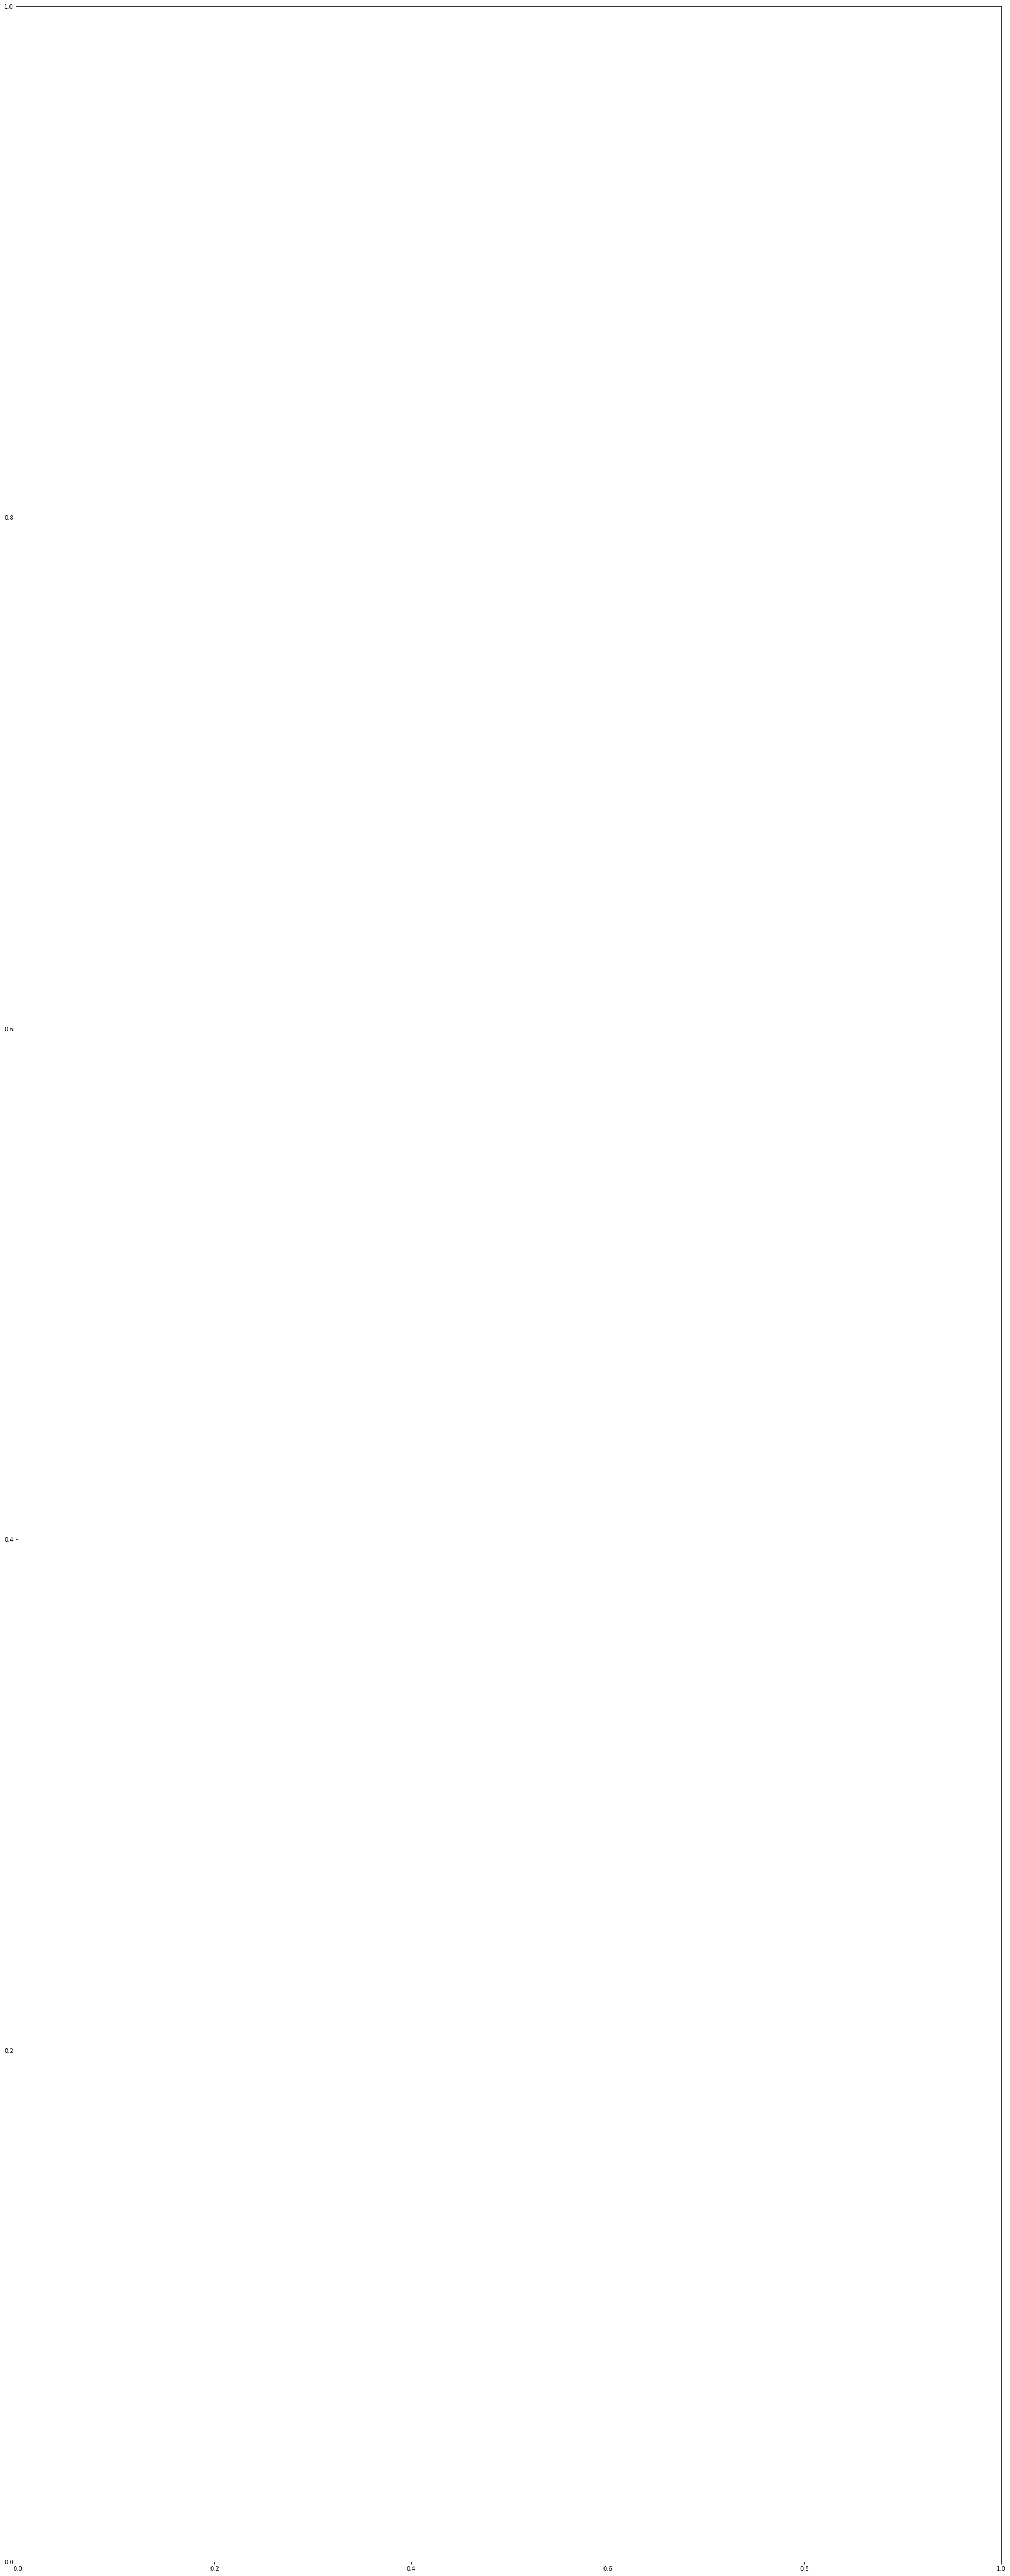

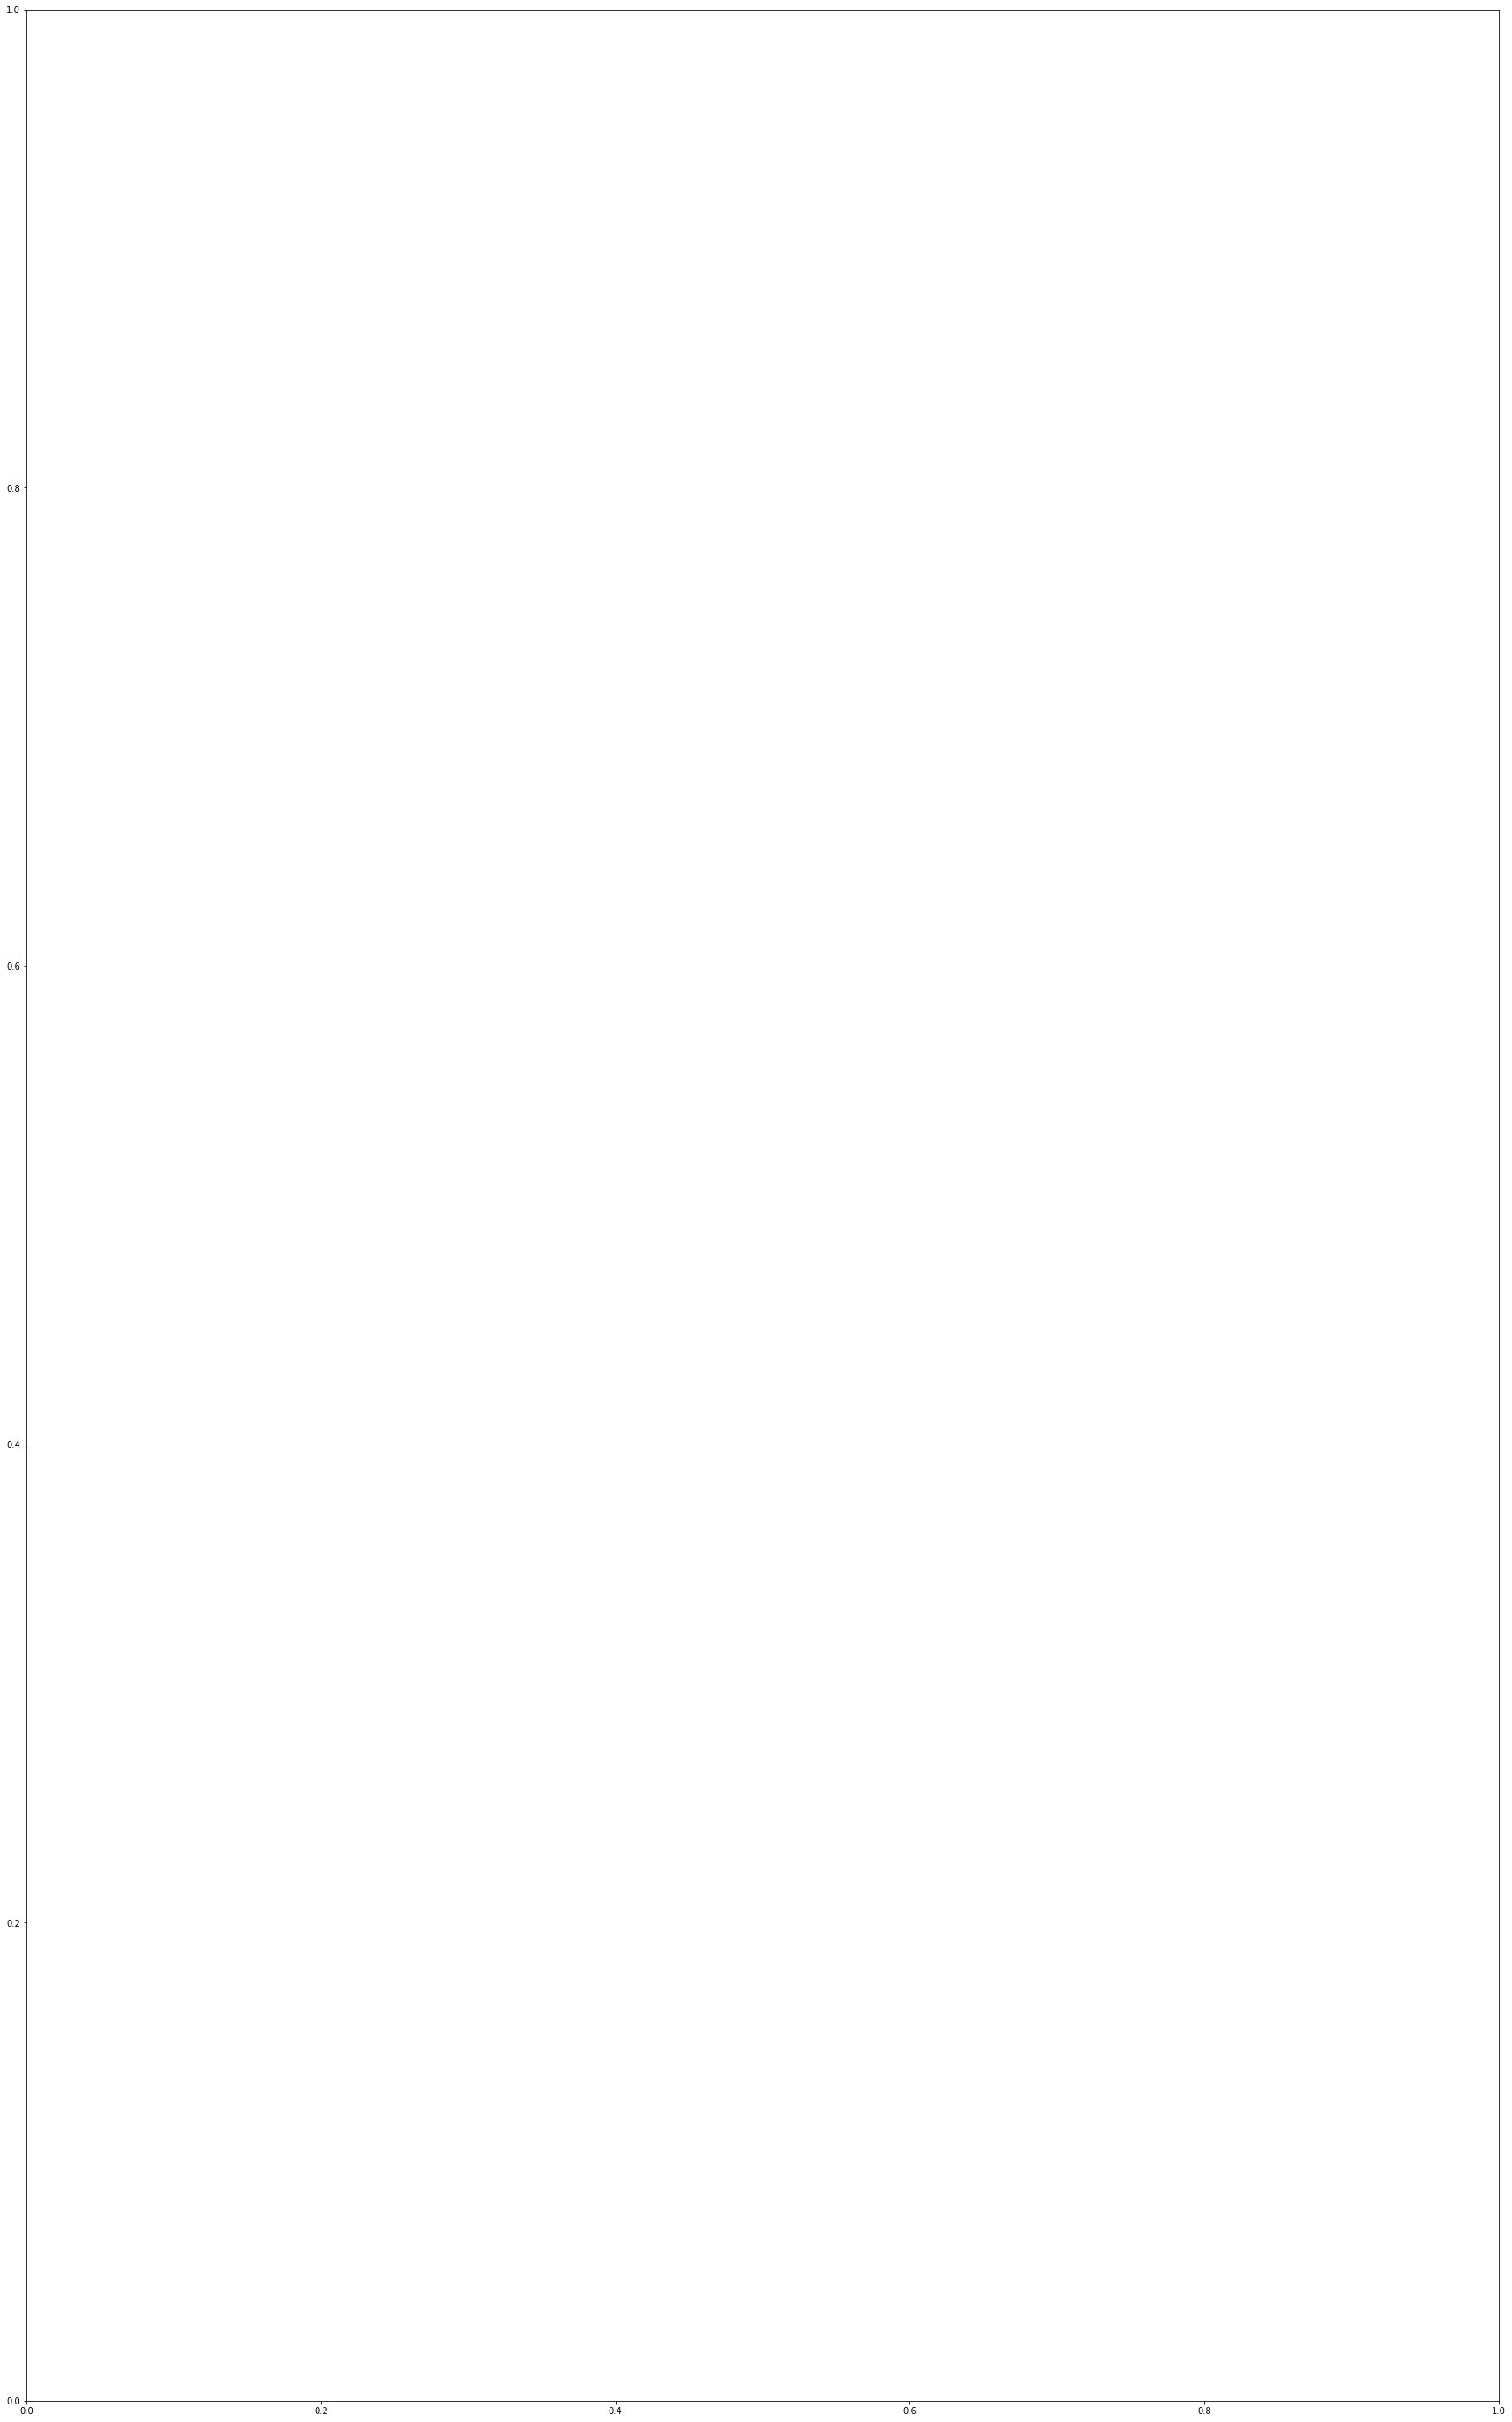

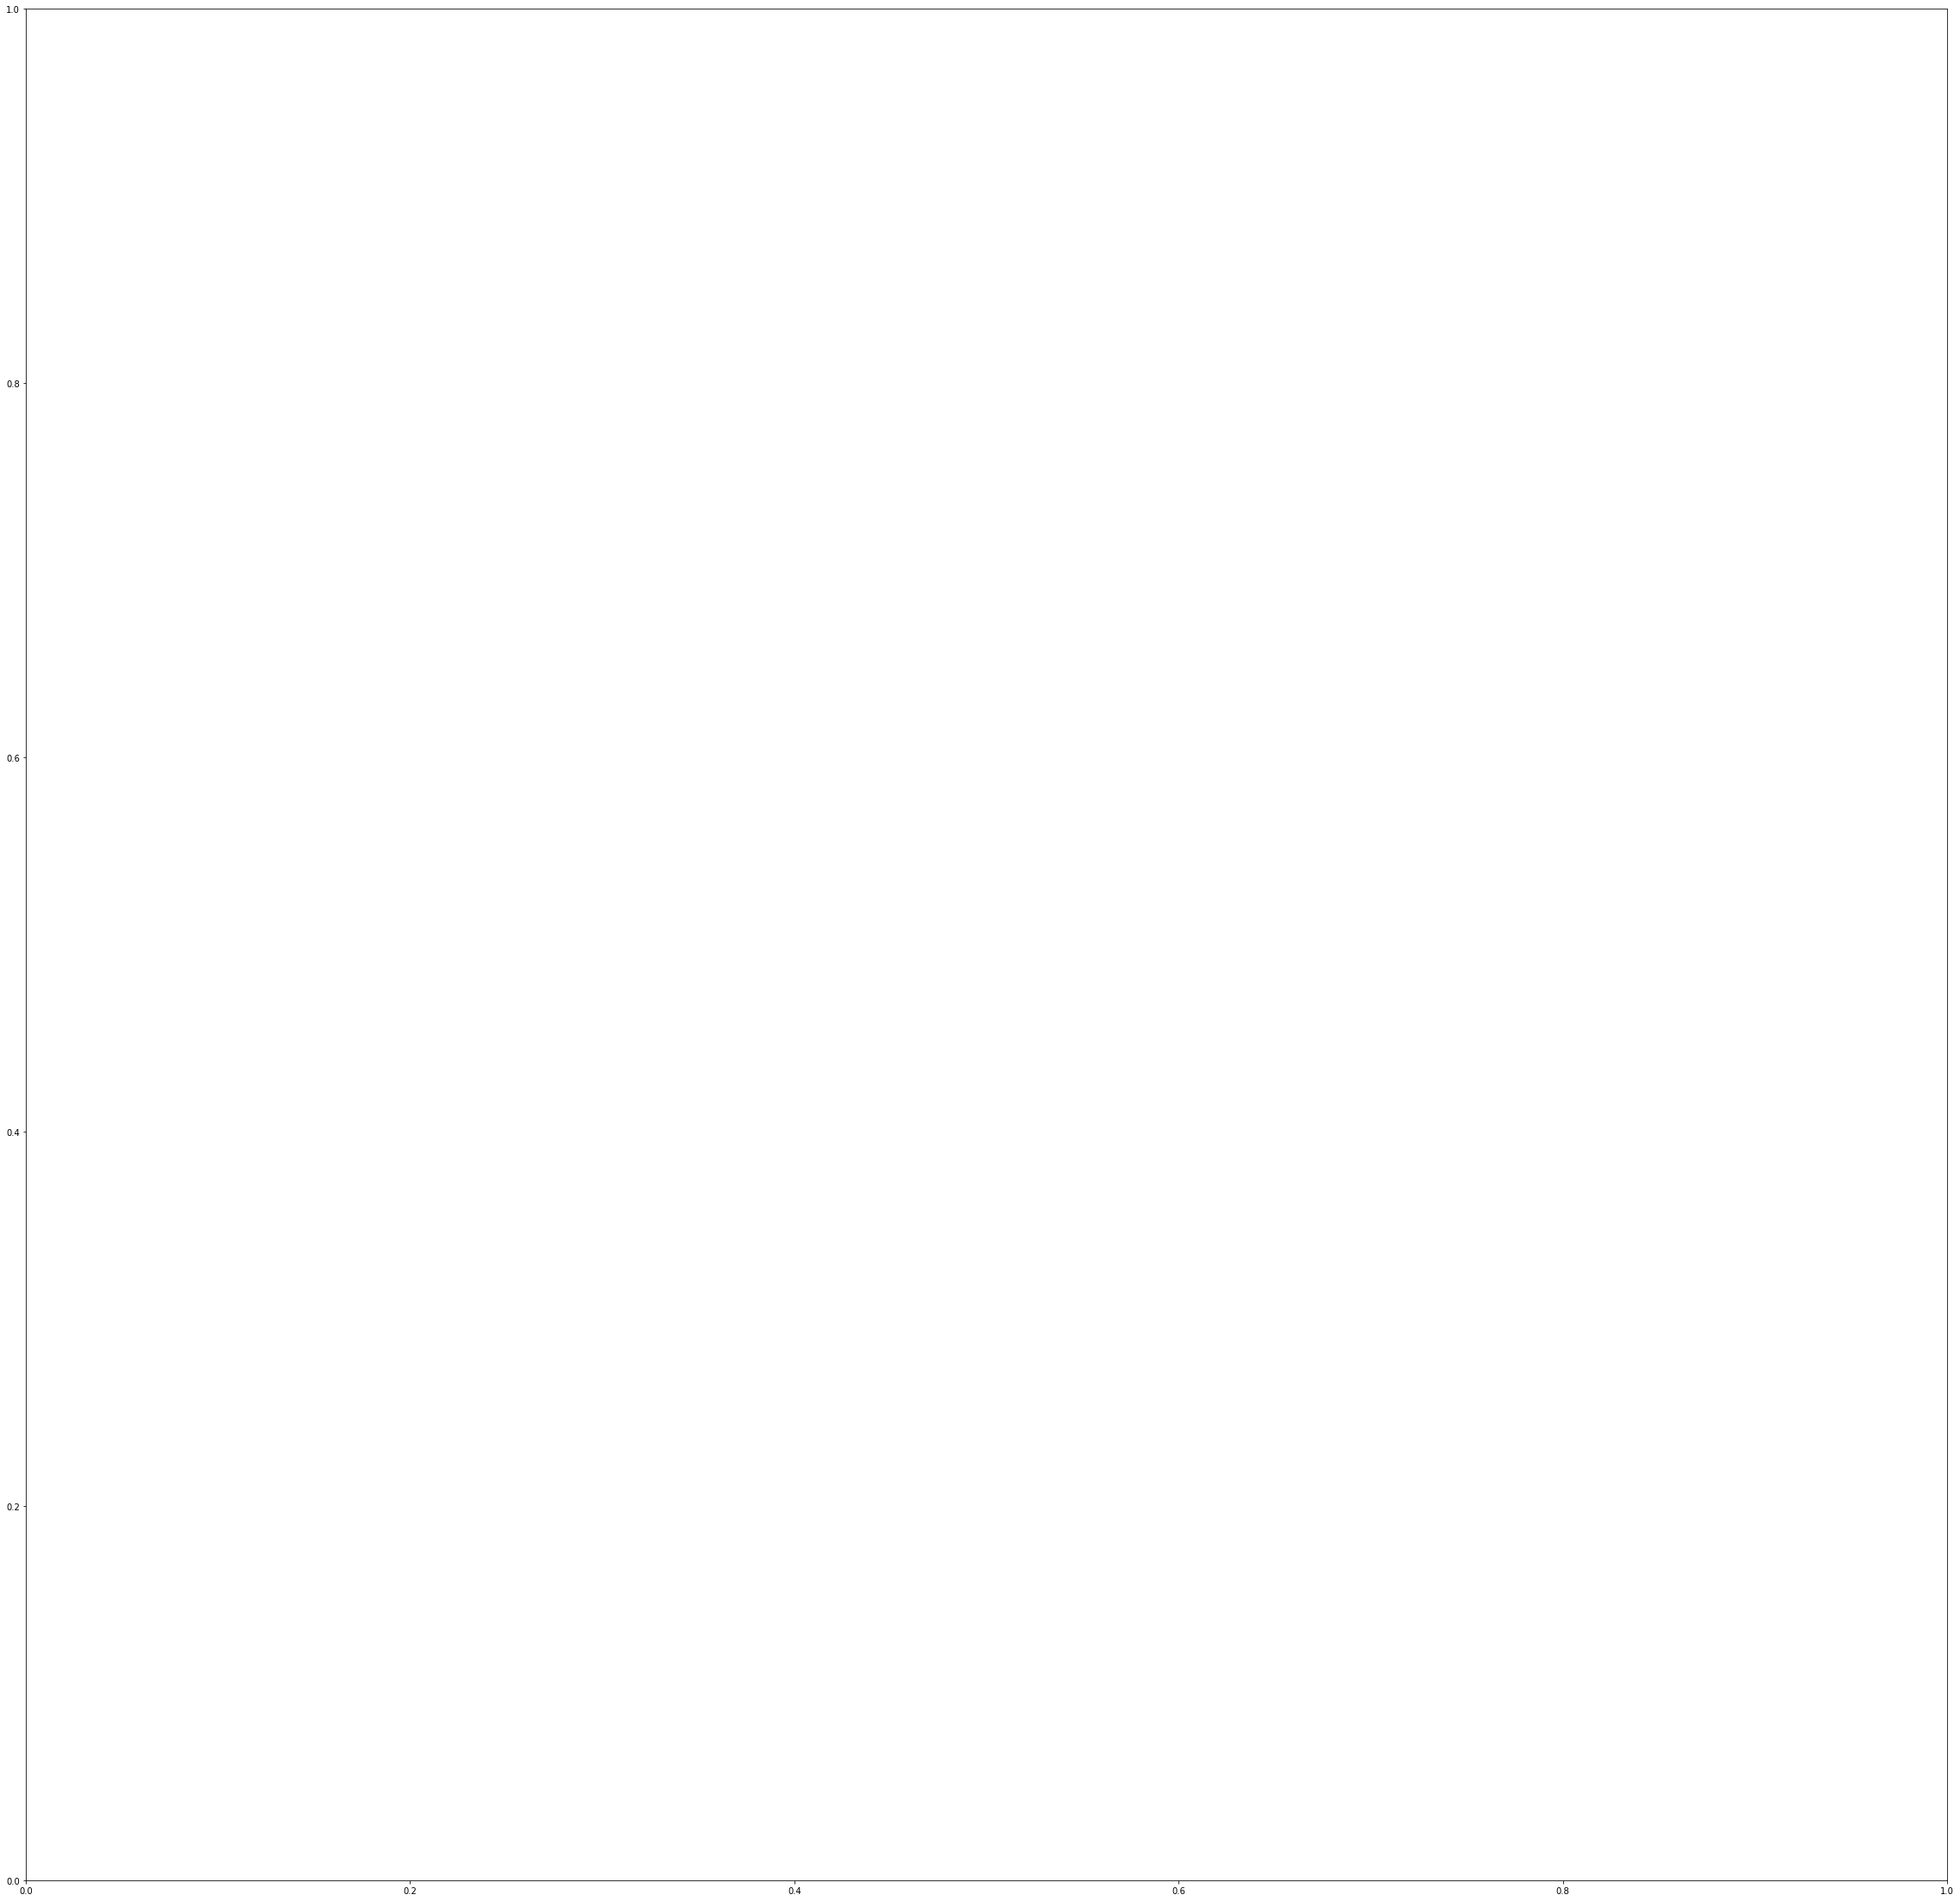

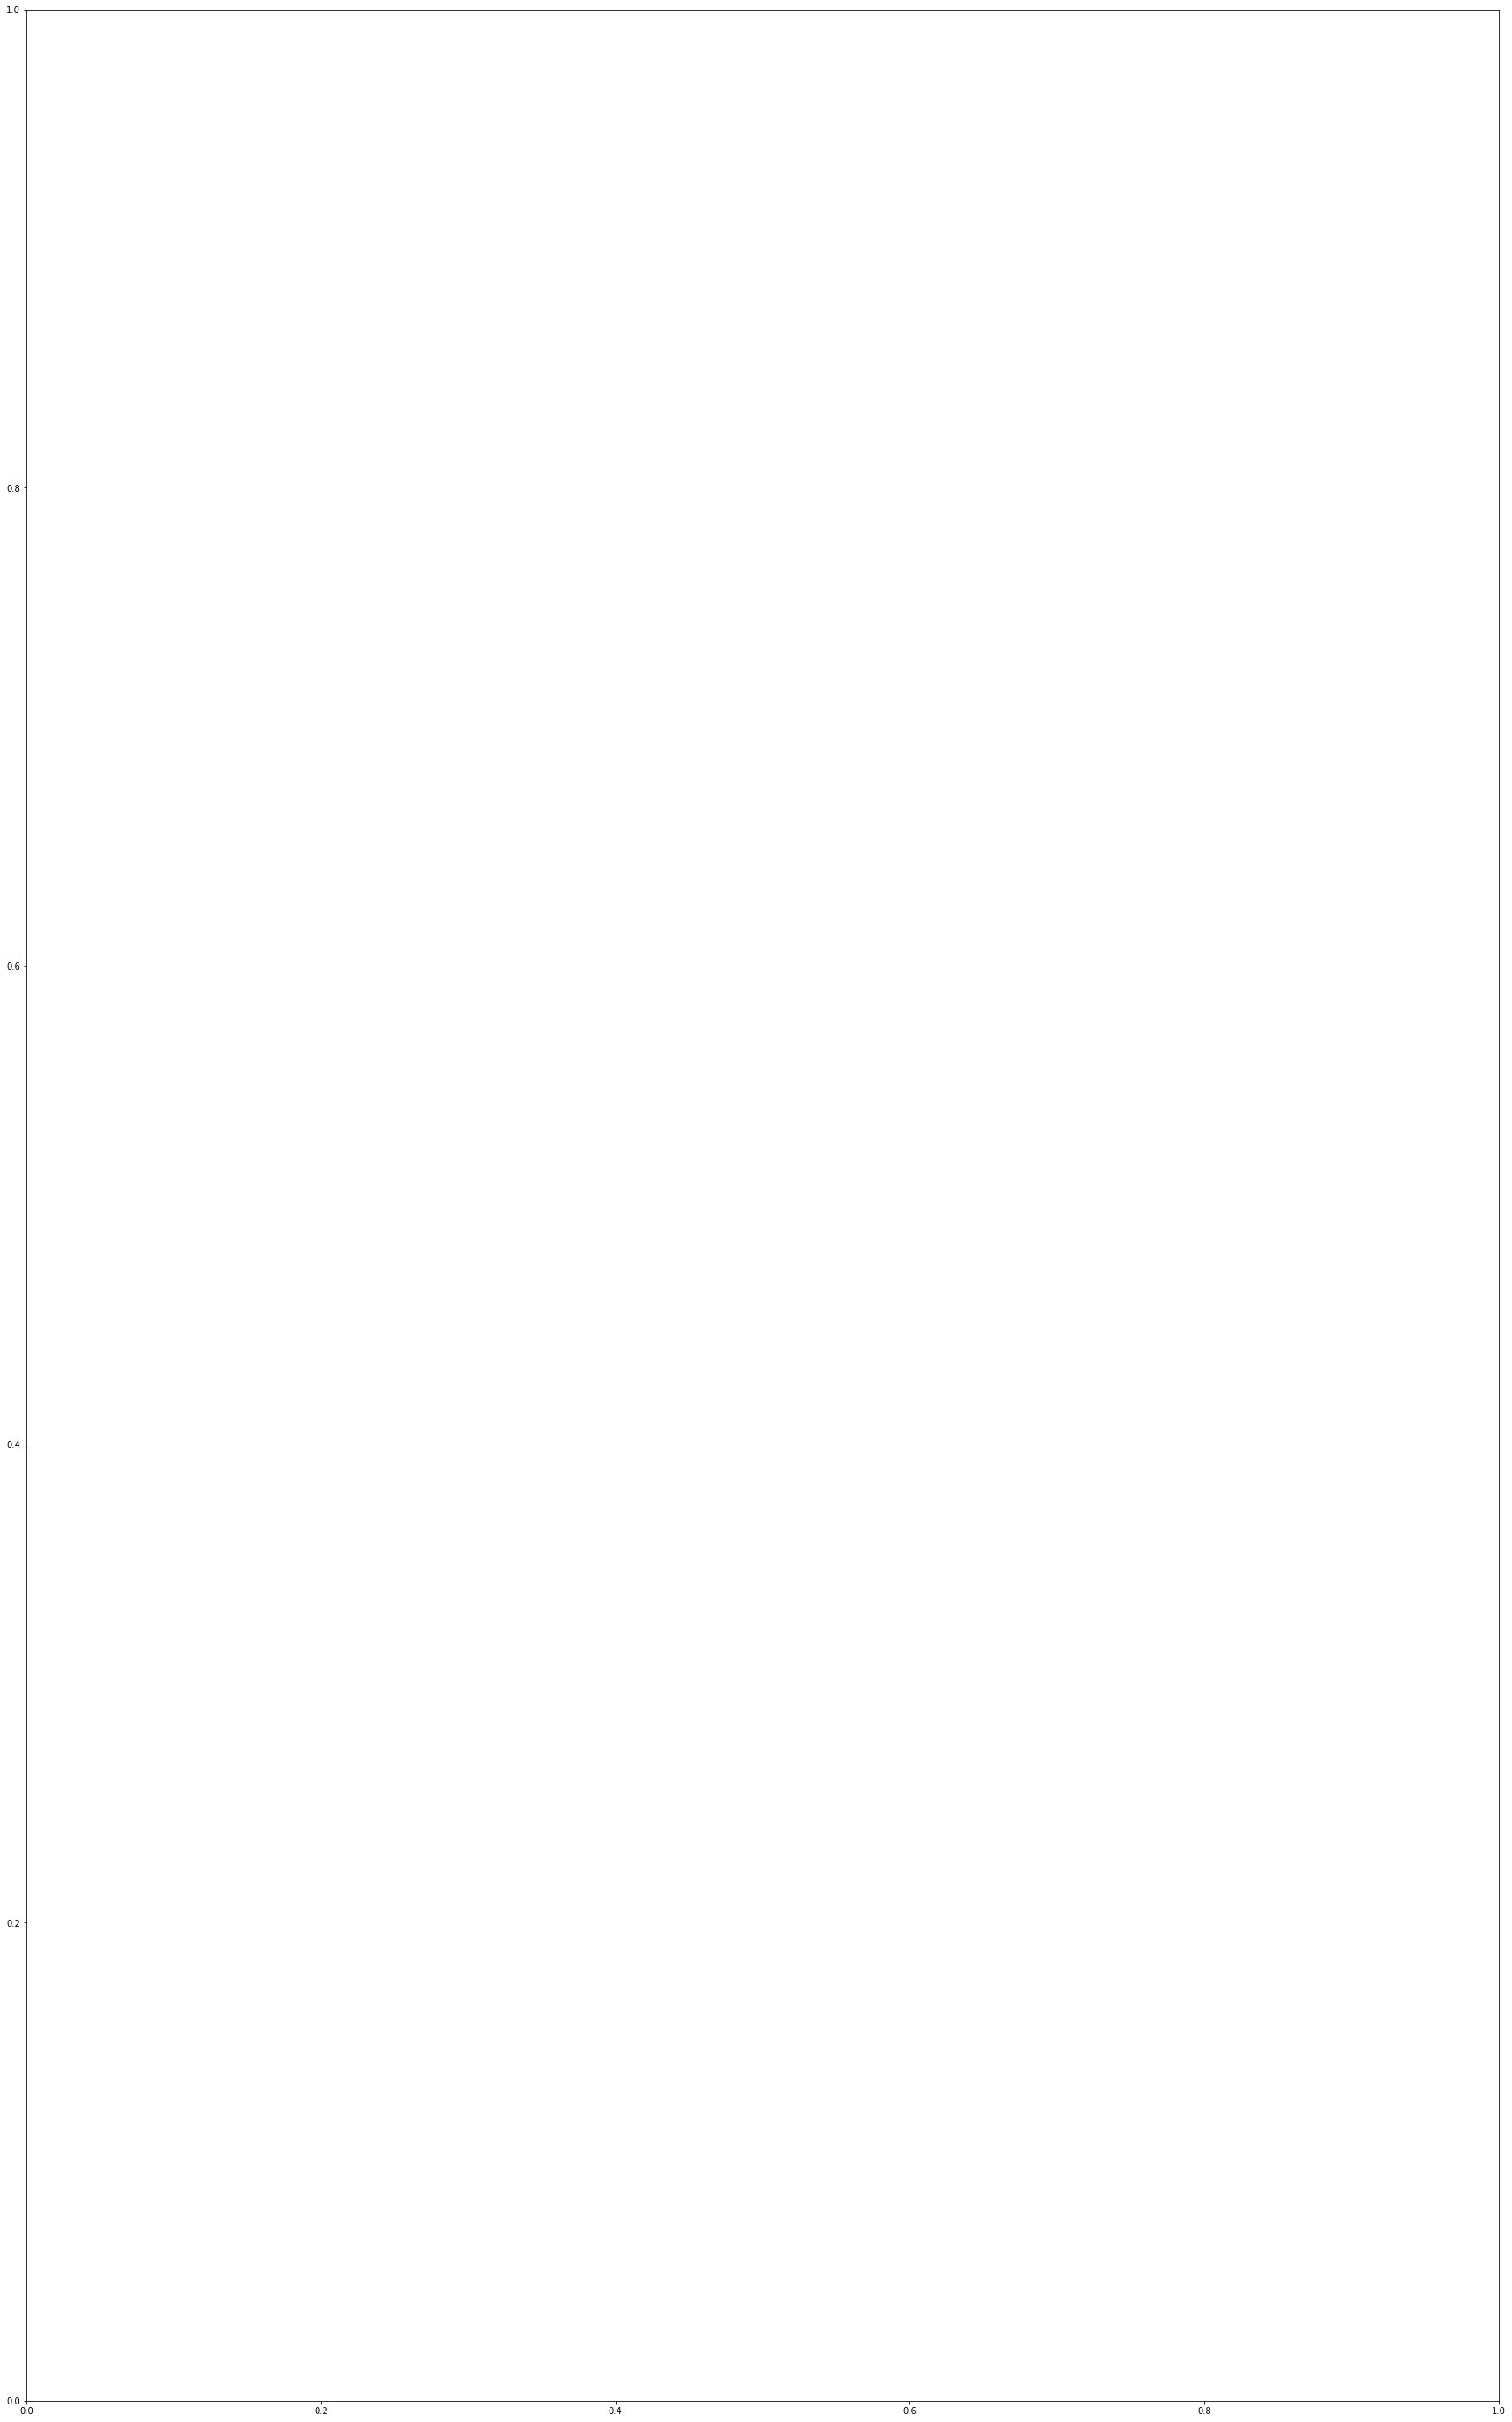

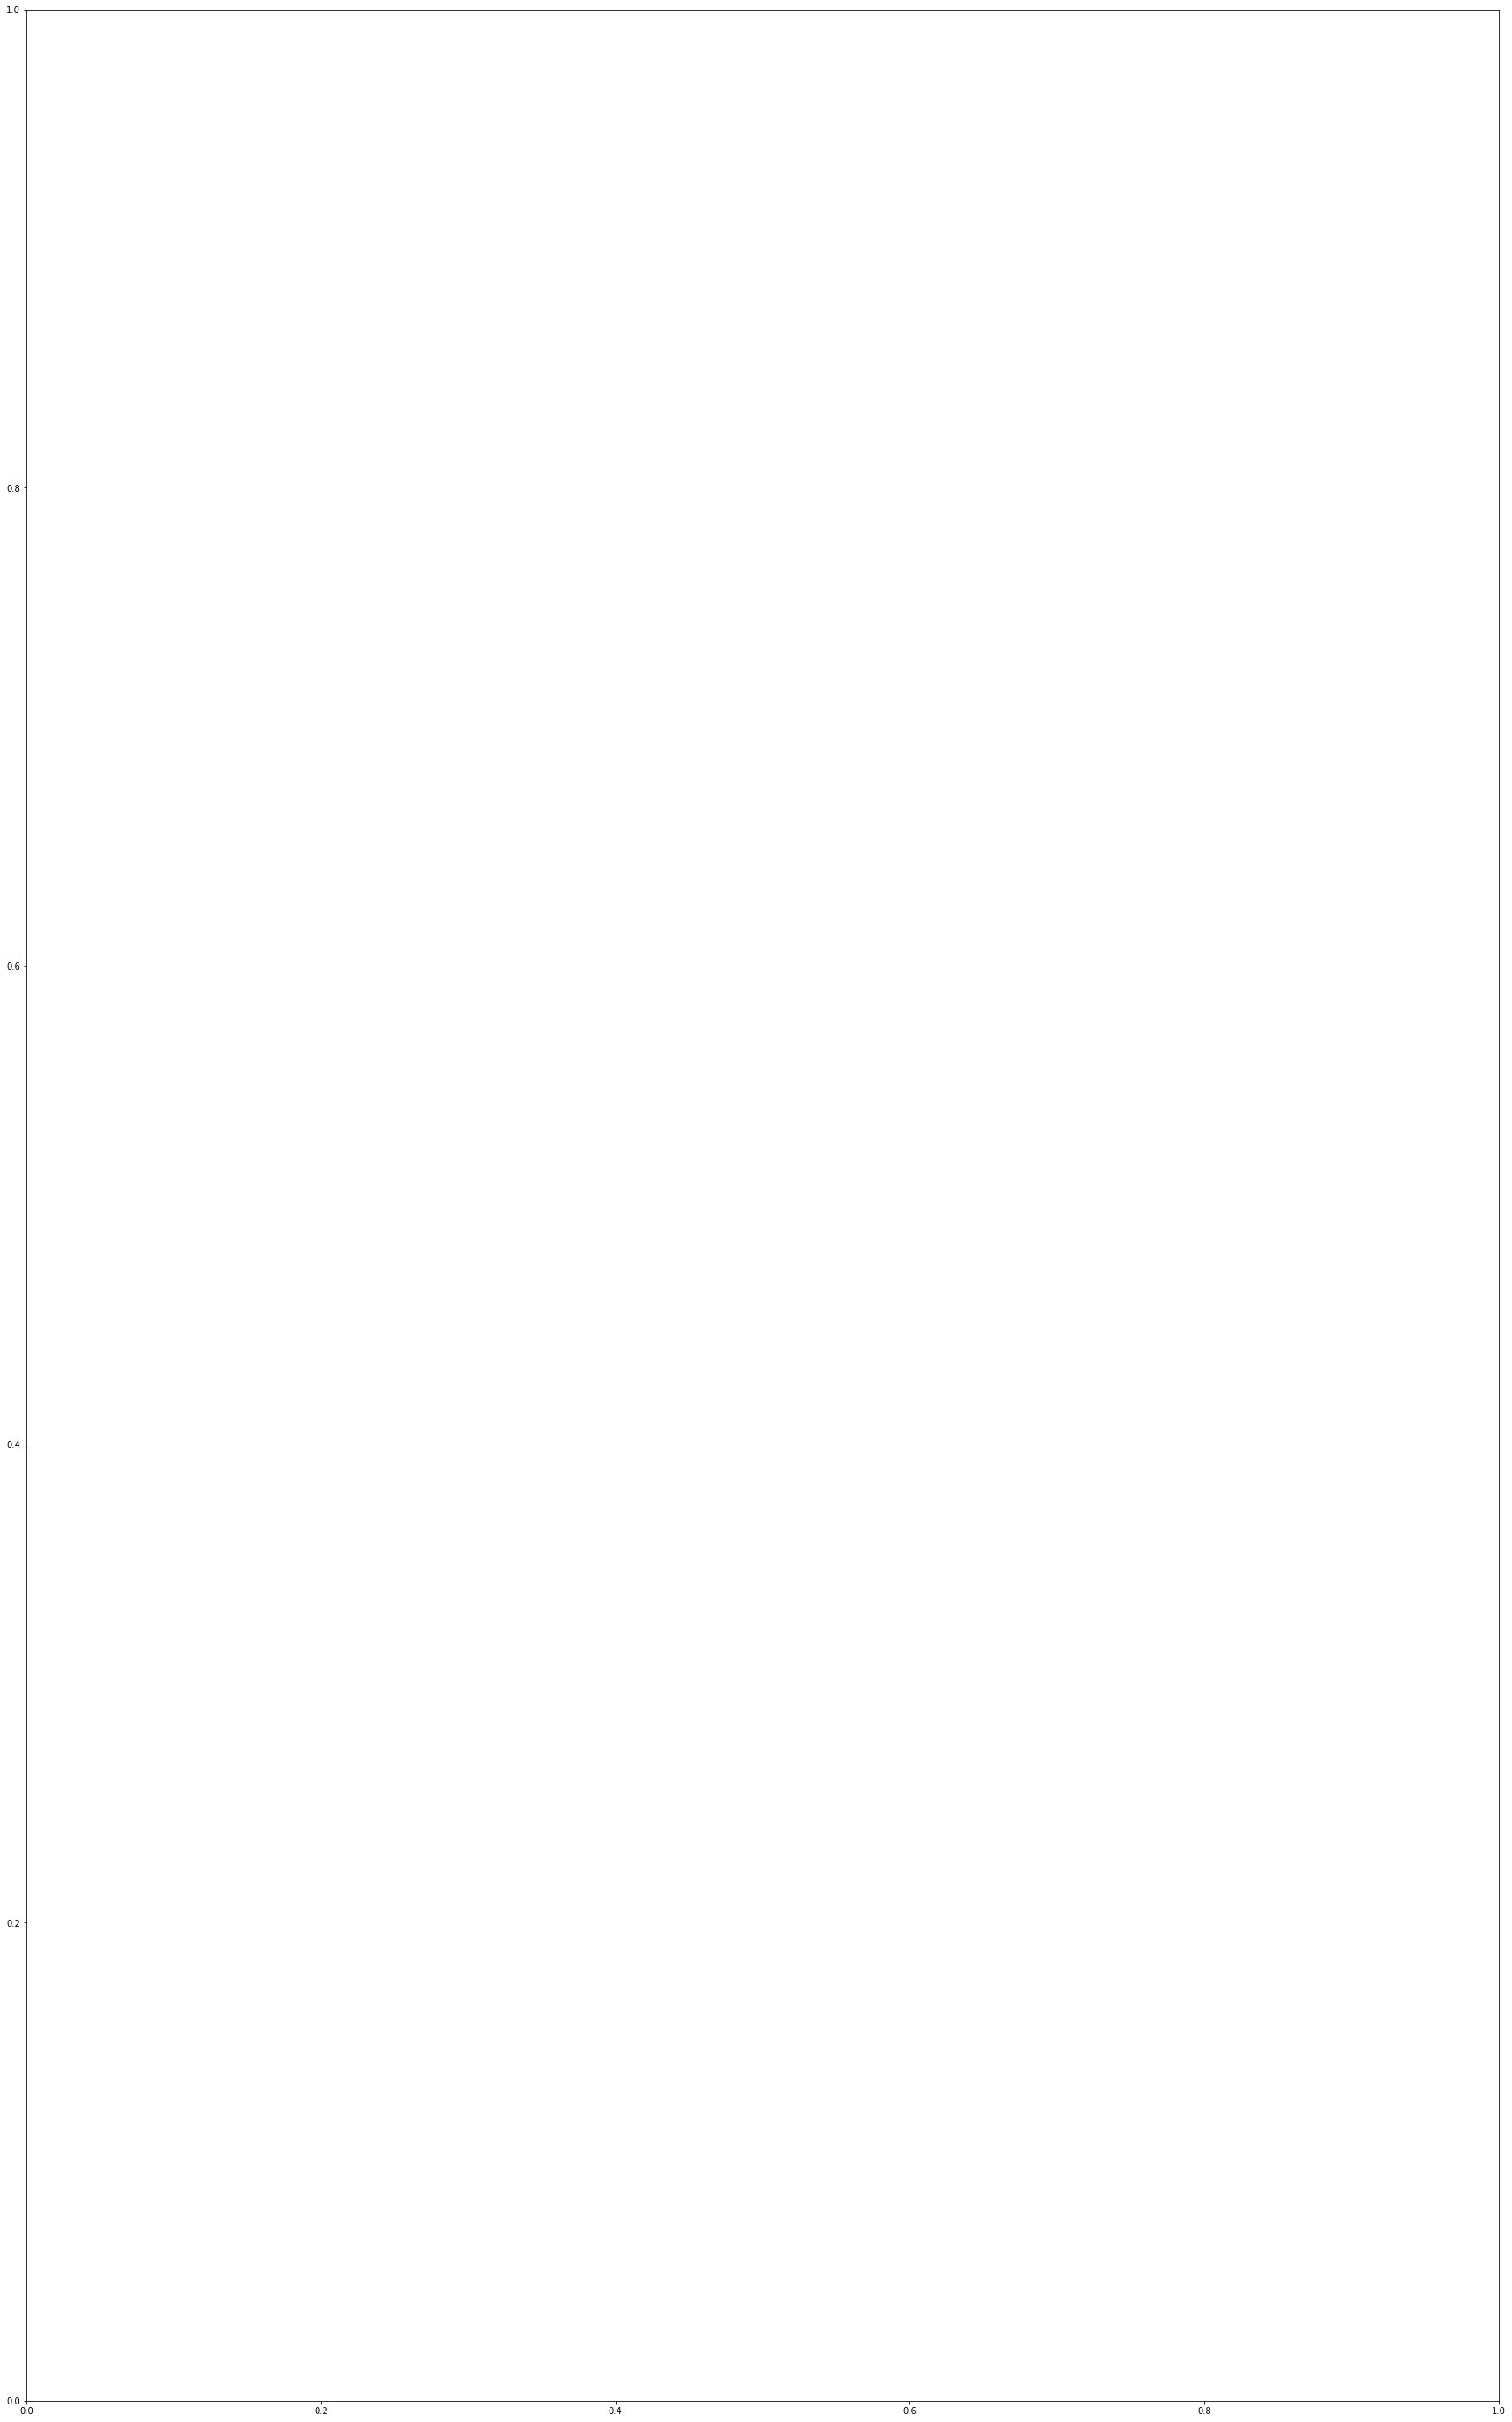

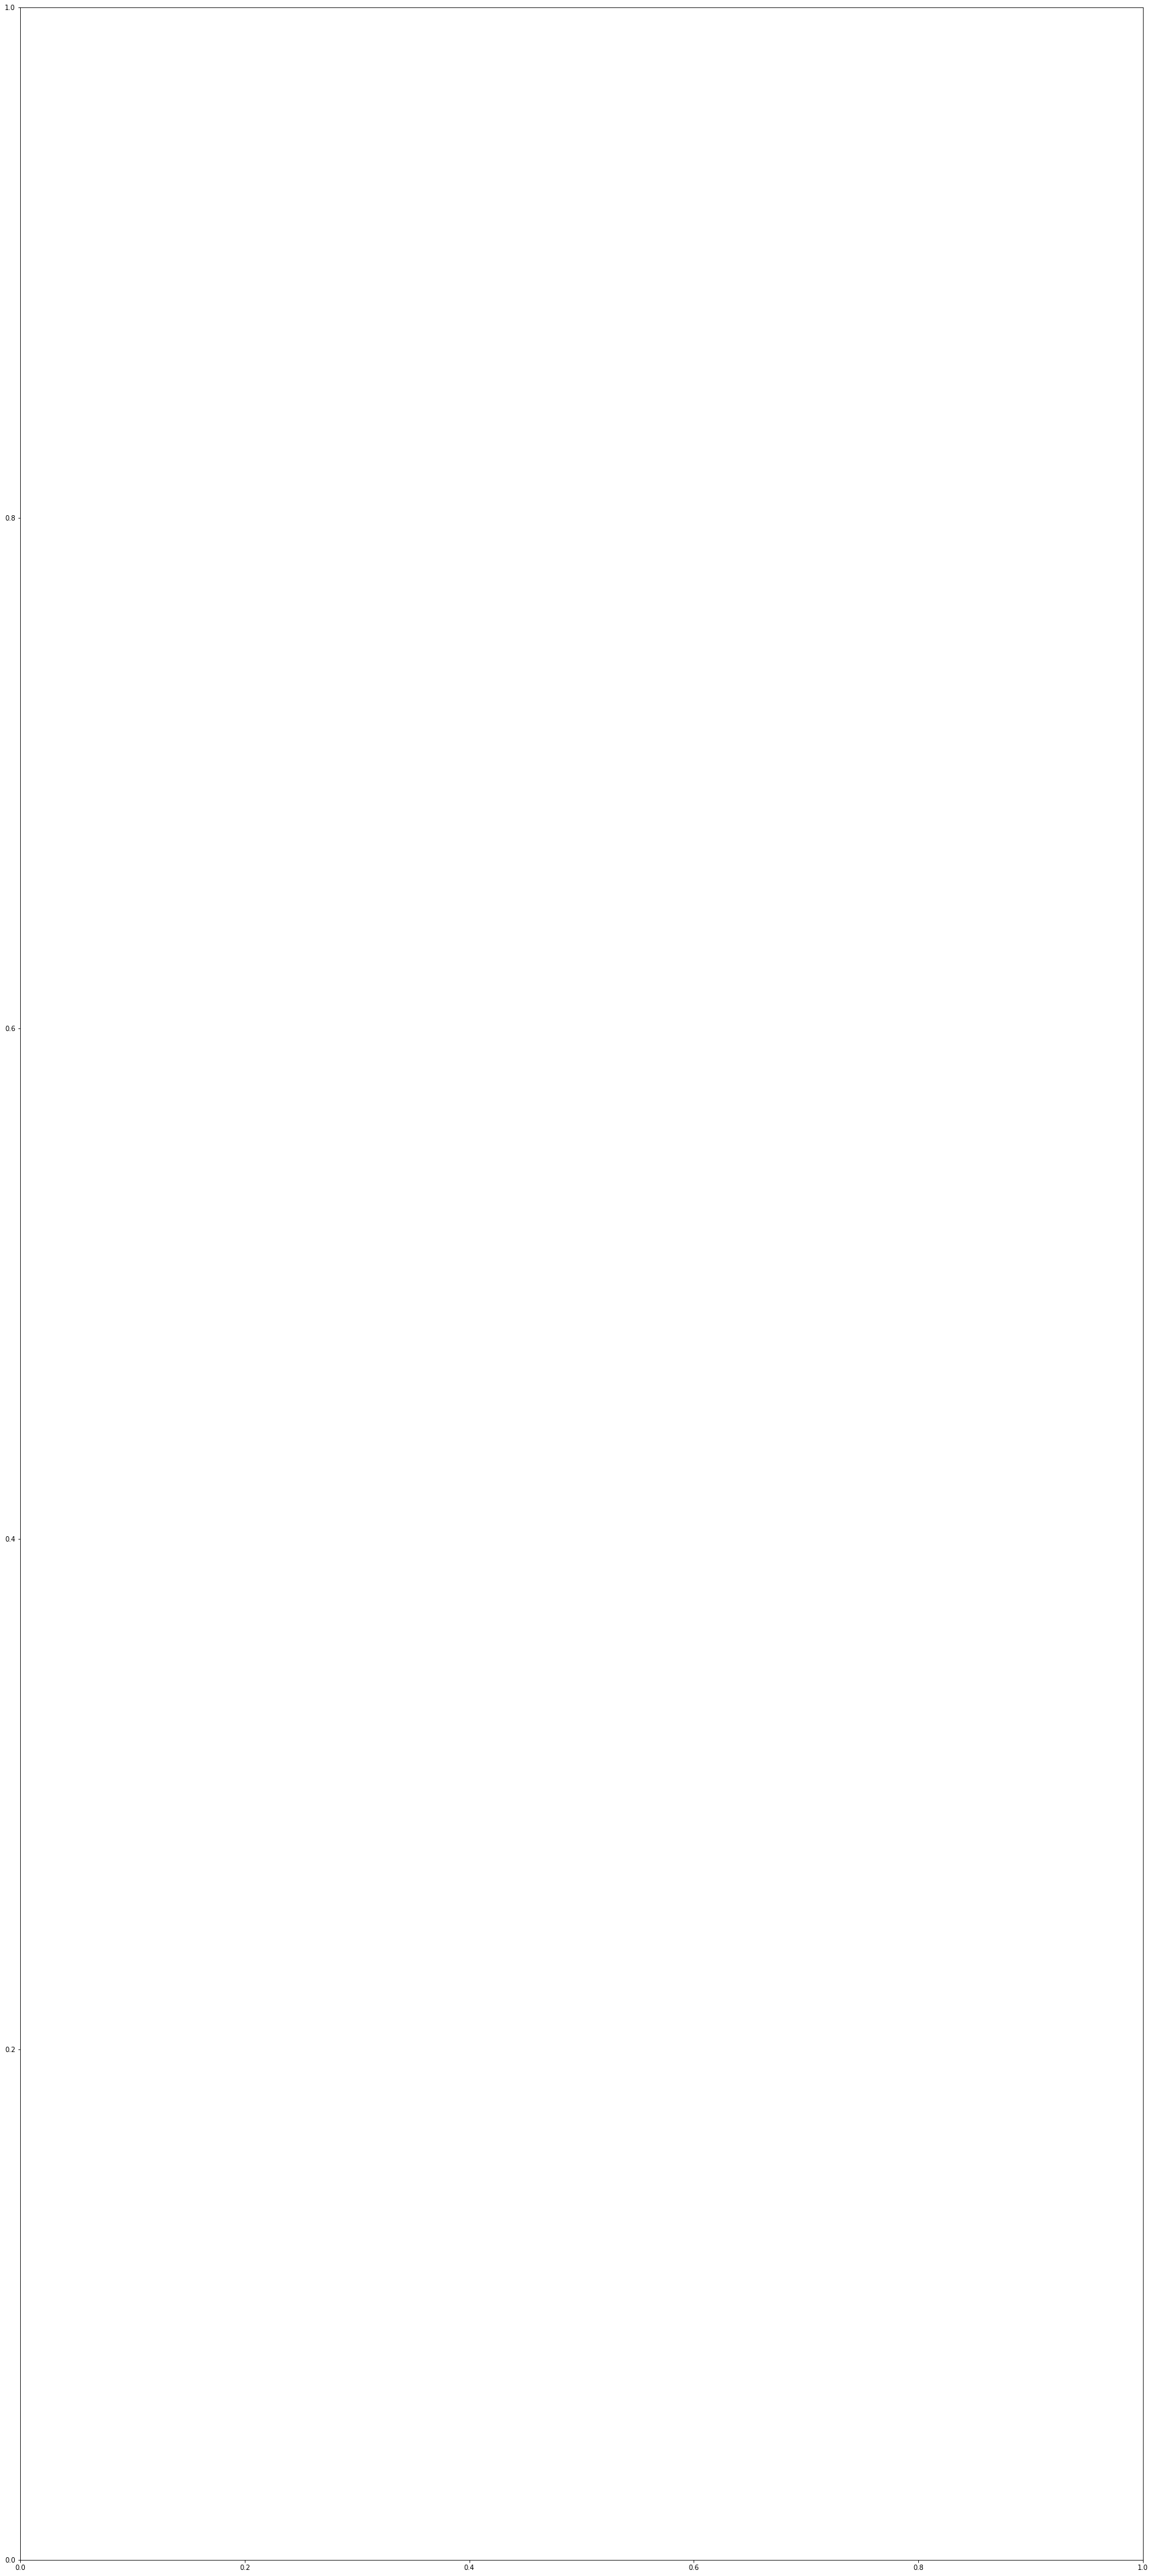

In [155]:
# plot the current groups - WITHOUT all genotypes
# new_cdict
for k in new_cdict.keys():
    plot_set_profile(new_cdict,k,"all")
    plt.clf()
    plt.cla()

In [181]:
zttpm.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.0,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.0,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.0,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418
5,Y104,1AB,6.0,W,21.0,gloriosa,54.385723,5.745473,0.0,17.707487,...,0.0,1.325587,20.929404,2.159383,7.363694,0.000000,2.504658,15.673893,0.0,0.000000
6,Y105,18,6.0,W,21.0,gloriosa,47.391406,8.458668,0.0,15.536940,...,0.0,7.491513,2.153592,6.520598,14.513037,2.782378,2.331412,20.726688,0.0,0.000000


In [185]:
test = plottpm_sgt(zttpm,1,"G")

In [186]:
test.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome
0,Y350,G,W,1.0,Yucal.01G003400.v2.1,97.947944,Ya
21744,Y358,G,W,9.0,YufilH1010492m.g,4.686639,Yf
21755,Y370,G,W,9.0,YufilH1010492m.g,4.719047,Yf
21754,Y369,G,W,5.0,YufilH1010492m.g,6.119154,Yf
21753,Y368,G,W,1.0,YufilH1010492m.g,6.137461,Yf


In [11]:
# rework plot_profile() to plot profiles by subgenome as well as treatment
def plot_profile(c,cpdf,axc,a,tf,log=False):
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat",style="subgenome")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat",style="subgenome")
    
    lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,lim,where=t>=xthresh,color="gray",alpha=0.3)
    a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=12)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=12)
    a[axc].set_title("Cluster "+str(c),fontsize=tf)

In [20]:
# rework plottpm similarly
def plottpm_sgt(tpm,c,gt):
    cinfo = allgt[gt]["clusters"]
    cinfo = cinfo[cinfo["cluster"]==c]
    cgenes = list(cinfo["GeneID"].unique())
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    # subset to just one genotype
    pgt = pwide[pwide["genotype"]==gt]
    plong = pd.melt(pgt,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    # add subgenome column
    sg = []
    for i in list(plong["GeneID"]):
        if i.startswith("Yucal"):
            sg.append("Ya")
        else:
            sg.append("Yf")
    plong["subgenome"] = sg
    return plong.sort_values(by=["treat","subgenome"],ascending=False)

In [13]:
def plottpm_all_sgt(tpm,c):
    cinfo = allgt["all"]["clusters"]
    cinfo = cinfo[cinfo["cluster"]==c]
    cgenes = list(cinfo["GeneID"].unique())
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    plong = pd.melt(pwide,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    # add subgenome column
    sg = []
    for i in list(plong["GeneID"]):
        if i.startswith("Yucal"):
            sg.append("Ya")
        else:
            sg.append("Yf")
    plong["subgenome"] = sg
    return plong

In [190]:
test.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome
0,Y350,G,W,1.0,Yucal.01G003400.v2.1,97.947944,Ya
21744,Y358,G,W,9.0,YufilH1010492m.g,4.686639,Yf
21755,Y370,G,W,9.0,YufilH1010492m.g,4.719047,Yf
21754,Y369,G,W,5.0,YufilH1010492m.g,6.119154,Yf
21753,Y368,G,W,1.0,YufilH1010492m.g,6.137461,Yf


In [191]:
test["logTPM"] = np.log1p(test["TPM"])

In [192]:
test.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome,logTPM
0,Y350,G,W,1.0,Yucal.01G003400.v2.1,97.947944,Ya,4.594594
21744,Y358,G,W,9.0,YufilH1010492m.g,4.686639,Yf,1.738119
21755,Y370,G,W,9.0,YufilH1010492m.g,4.719047,Yf,1.743802
21754,Y369,G,W,5.0,YufilH1010492m.g,6.119154,Yf,1.962789
21753,Y368,G,W,1.0,YufilH1010492m.g,6.137461,Yf,1.965357


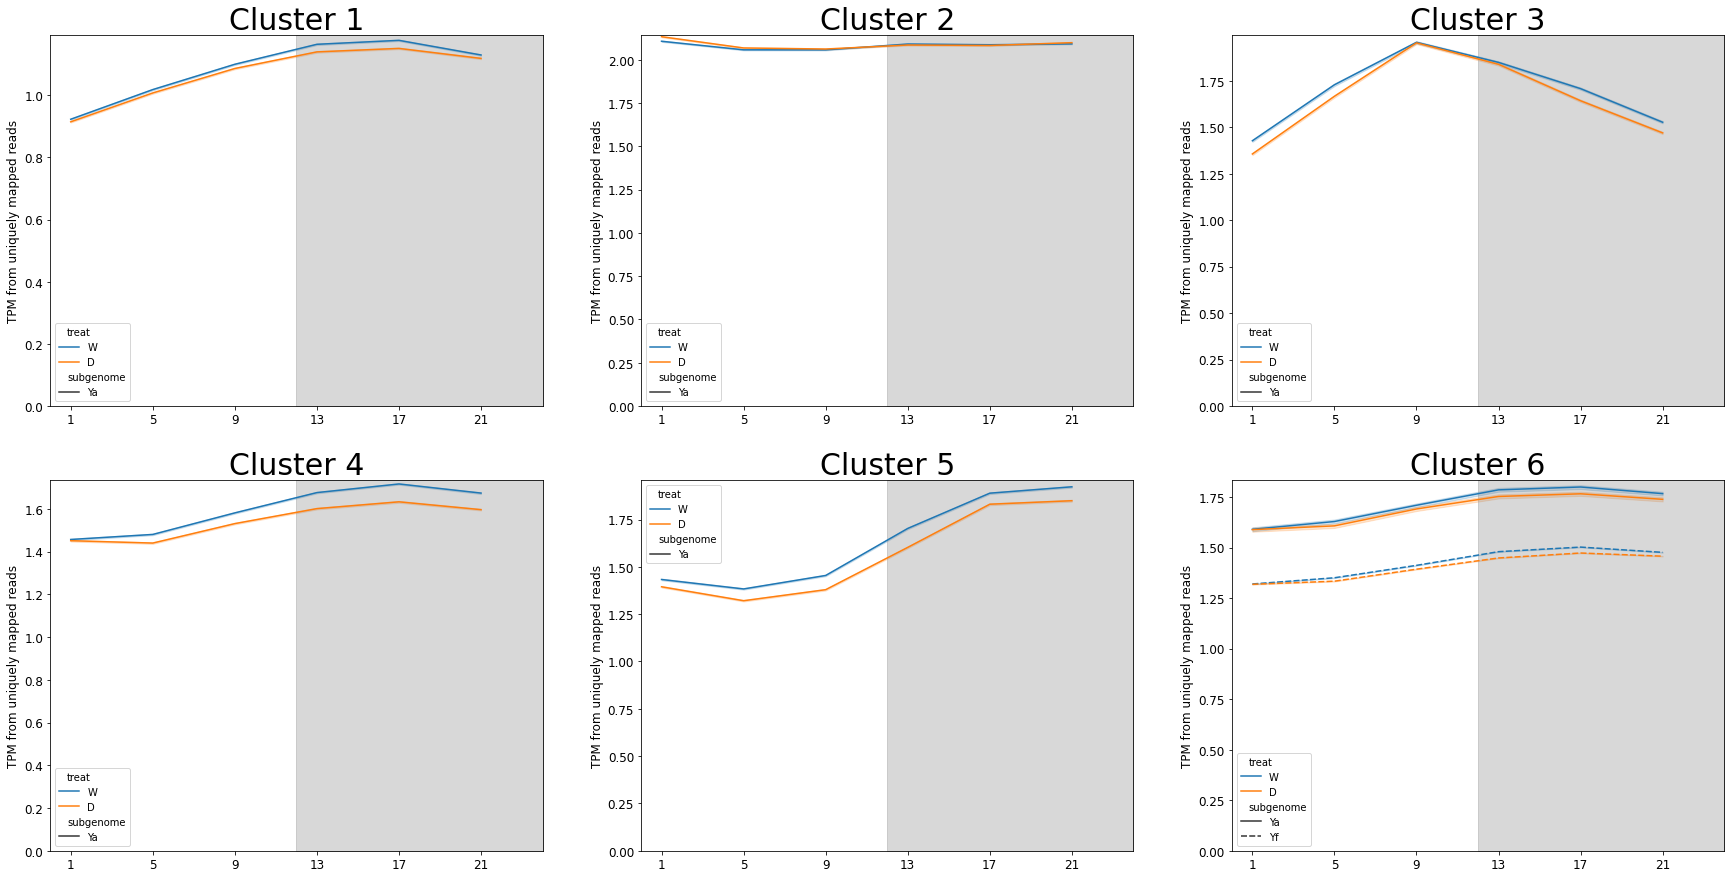

In [14]:
# re-plot all genotypes with logTPM
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(30,15))
plot_profile(1,plottpm_all_sgt(zttpm,1),(0,0),ax,30,log=True)
plot_profile(2,plottpm_all_sgt(zttpm,2),(0,1),ax,30,log=True)
plot_profile(3,plottpm_all_sgt(zttpm,3),(0,2),ax,30,log=True)
plot_profile(4,plottpm_all_sgt(zttpm,4),(1,0),ax,30,log=True)
plot_profile(5,plottpm_all_sgt(zttpm,5),(1,1),ax,30,log=True)
plot_profile(6,plottpm_all_sgt(zttpm,6),(1,2),ax,30,log=True)
plt.savefig("./genotype_profile_plots/profiles_allgt_logTPM.png",dpi=200,bbox_inches="tight")
plt.savefig("./genotype_profile_plots/profiles_allgt_logTPM.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./genotype_profile_plots/profiles_allgt_logTPM.svg",dpi=200,bbox_inches="tight")

In [50]:
allgt["all"].keys()

dict_keys(['clusters', 'CAMgenes', 'all_summary', 'CAM_summary'])

In [51]:
# are there truly no filamentosa genes in any cluster except c6 for all genotypes?
c_all_genes = allgt["all"]["clusters"]

In [52]:
c_all_genes.head()

,cluster,GeneID
0,1,Yucal.01G000100.v2.1
1,2,Yucal.01G000200.v2.1
2,2,Yucal.01G000400.v2.1
3,2,Yucal.01G000500.v2.1
4,1,Yucal.01G000600.v2.1


In [53]:
# create a subgenome column
sg = []
for i in list(c_all_genes["GeneID"]):
    if i.startswith("Yucal"):
        sg.append("Ya")
    else:
        sg.append("Yf")
c_all_genes["subgenome"] = sg

In [54]:
call_yf = c_all_genes[c_all_genes["subgenome"]=="Yf"]

In [55]:
call_yf["cluster"].unique()

array([6])

In [56]:
len(call_yf.index)

31805

In [60]:
c_all_genes.groupby(["subgenome","cluster"]).count().reset_index()

,subgenome,cluster,GeneID
0,Ya,1,12226
1,Ya,2,10371
2,Ya,3,1974
3,Ya,4,4055
4,Ya,5,3944
5,Ya,6,1029
6,Yf,6,31805


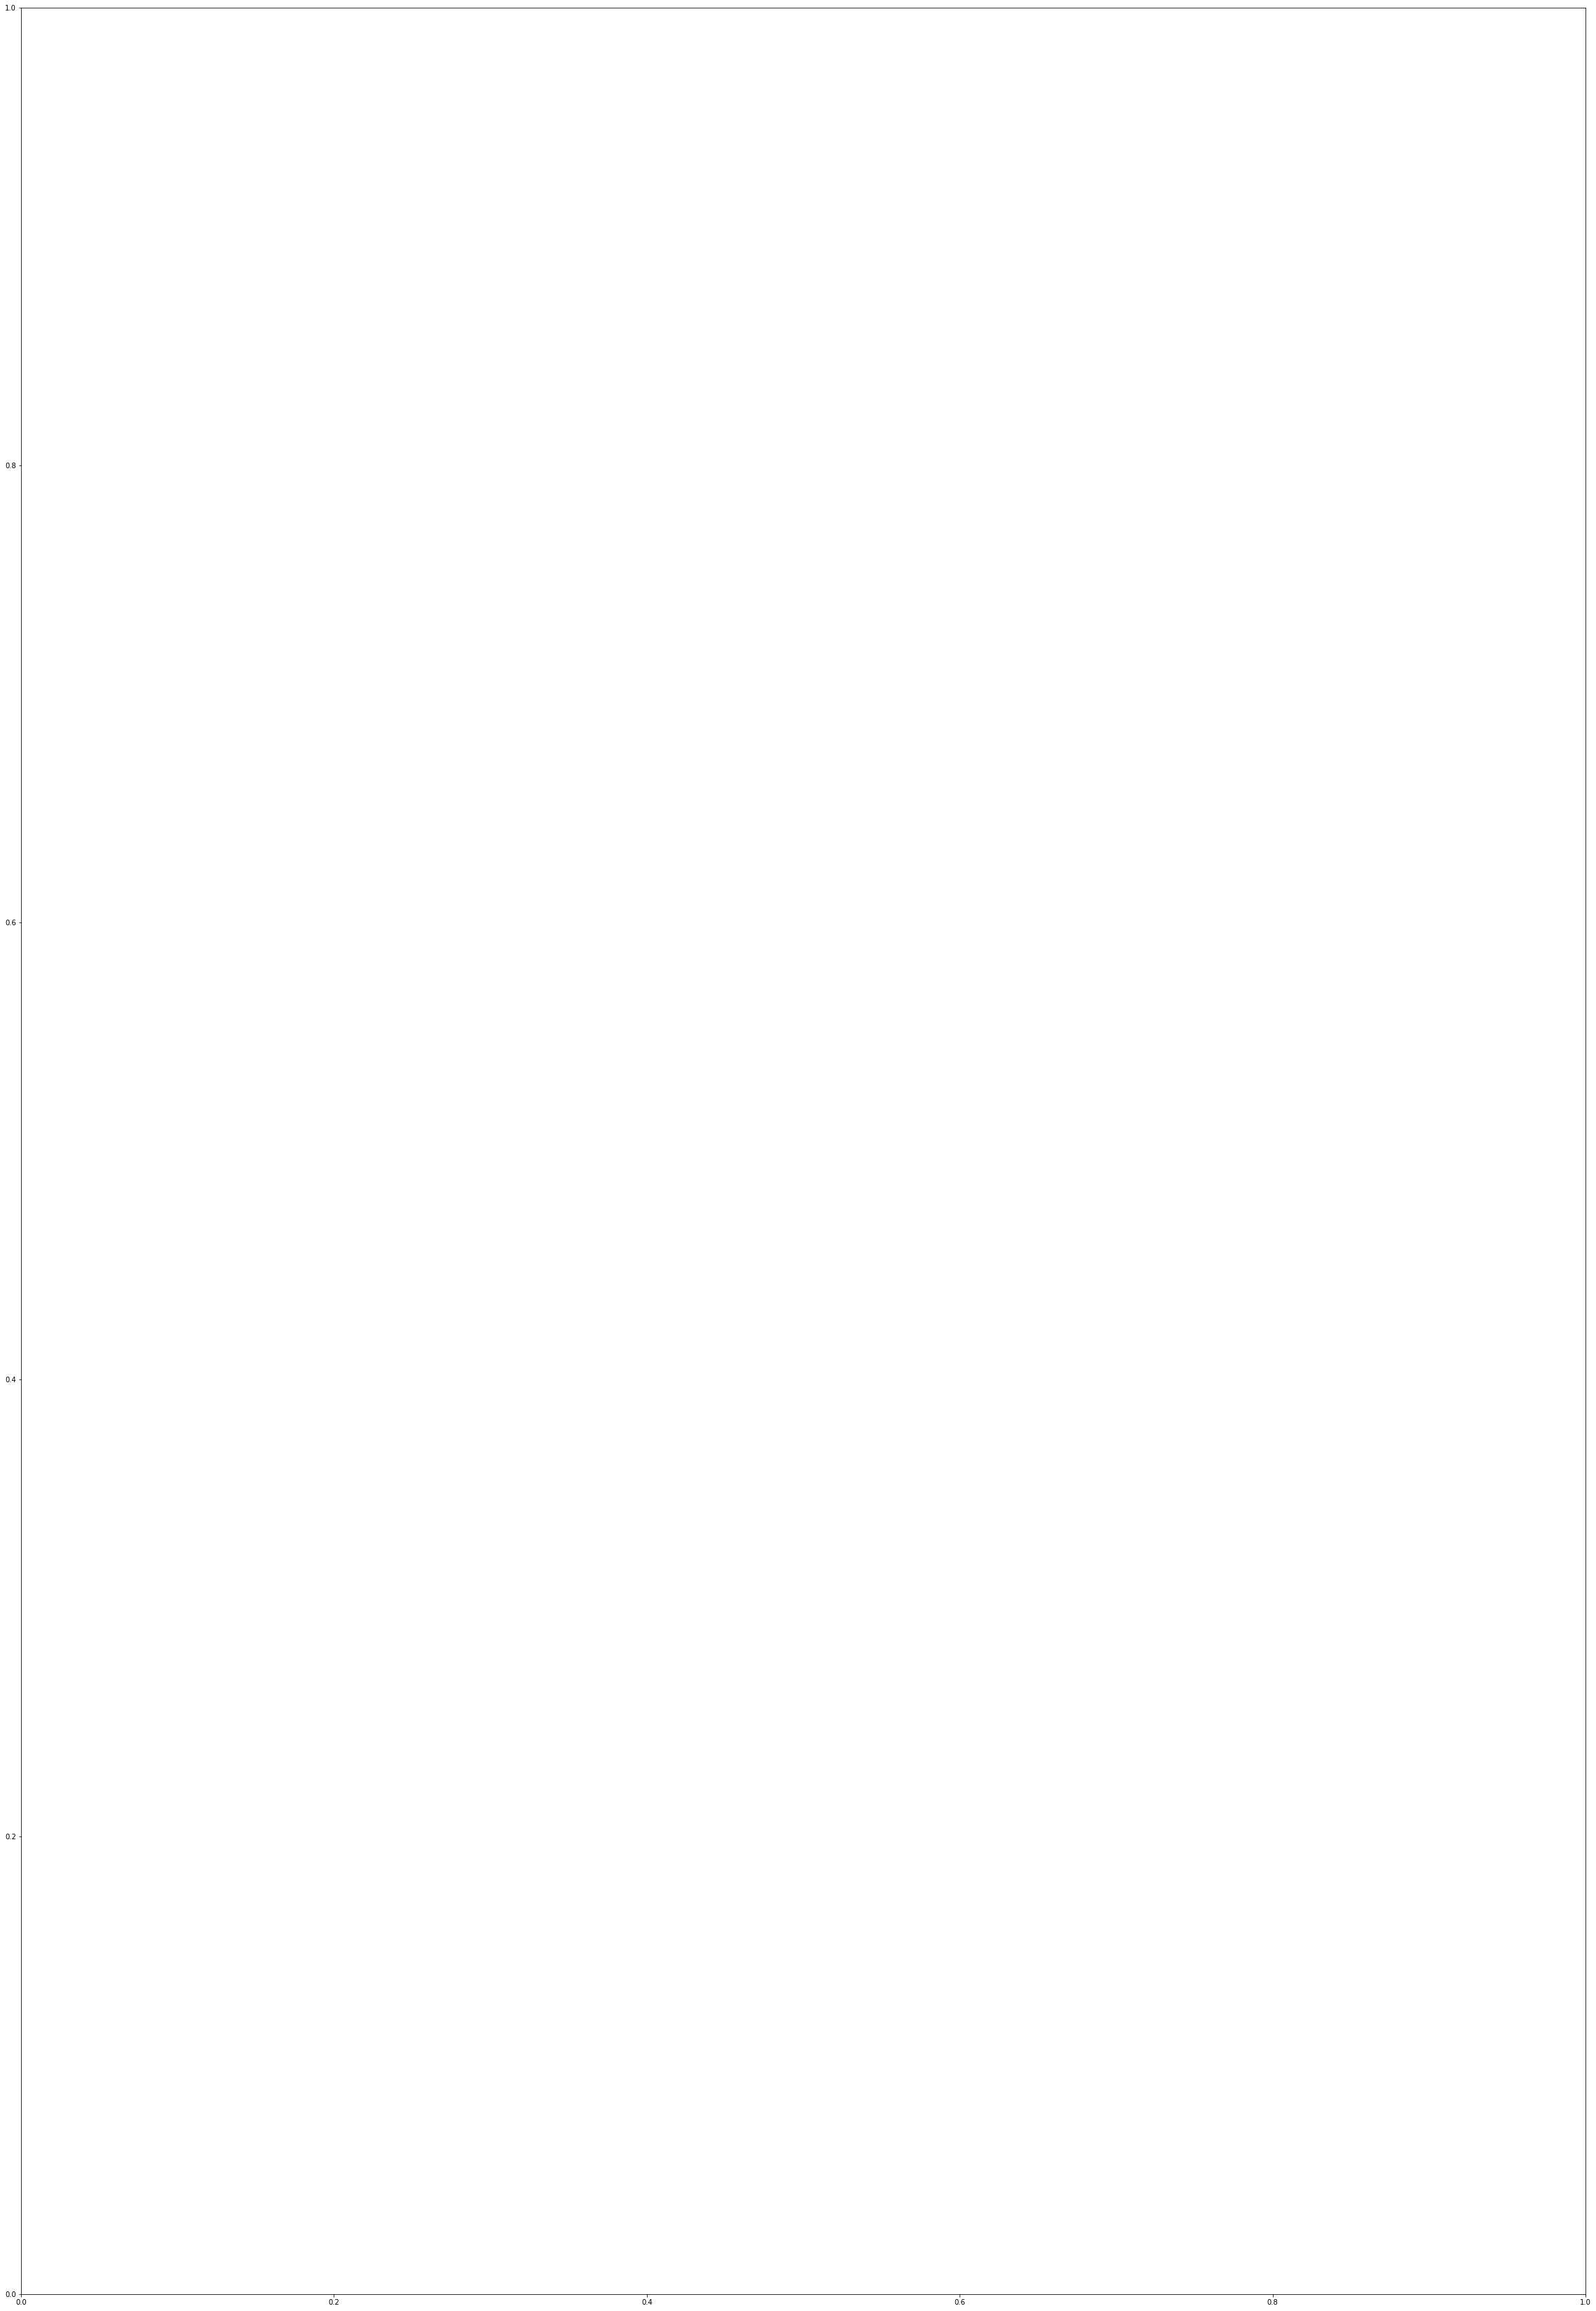

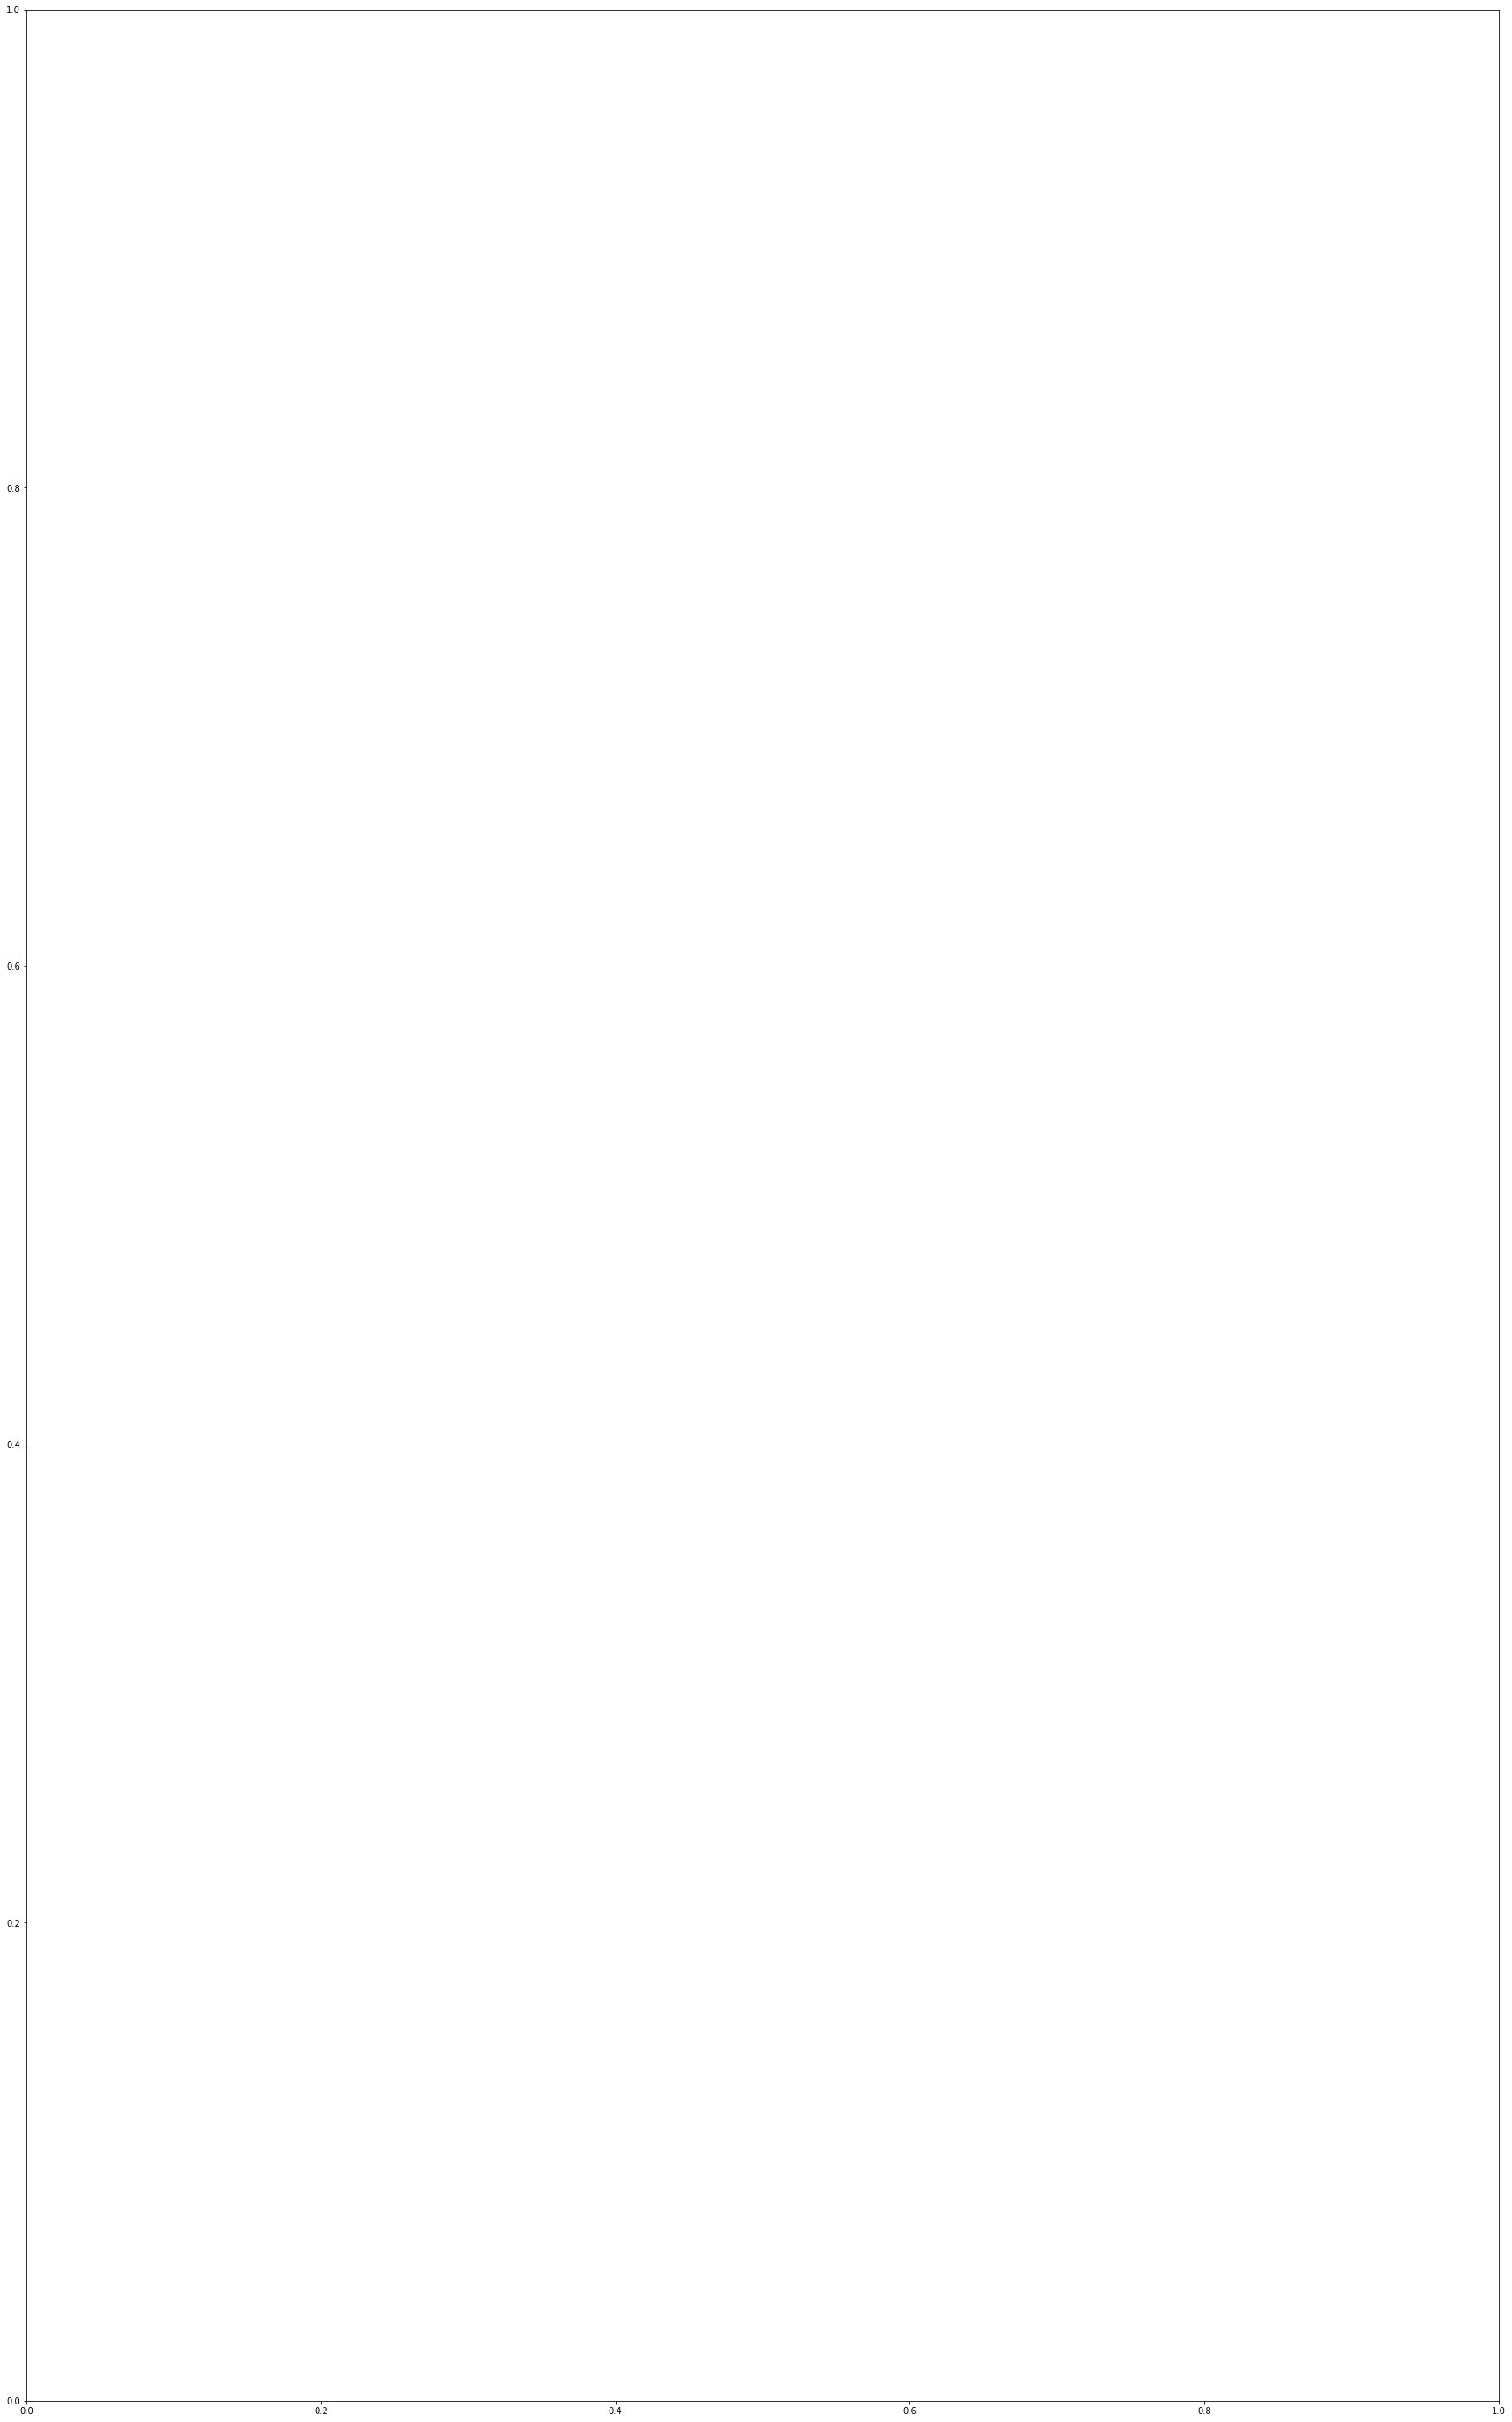

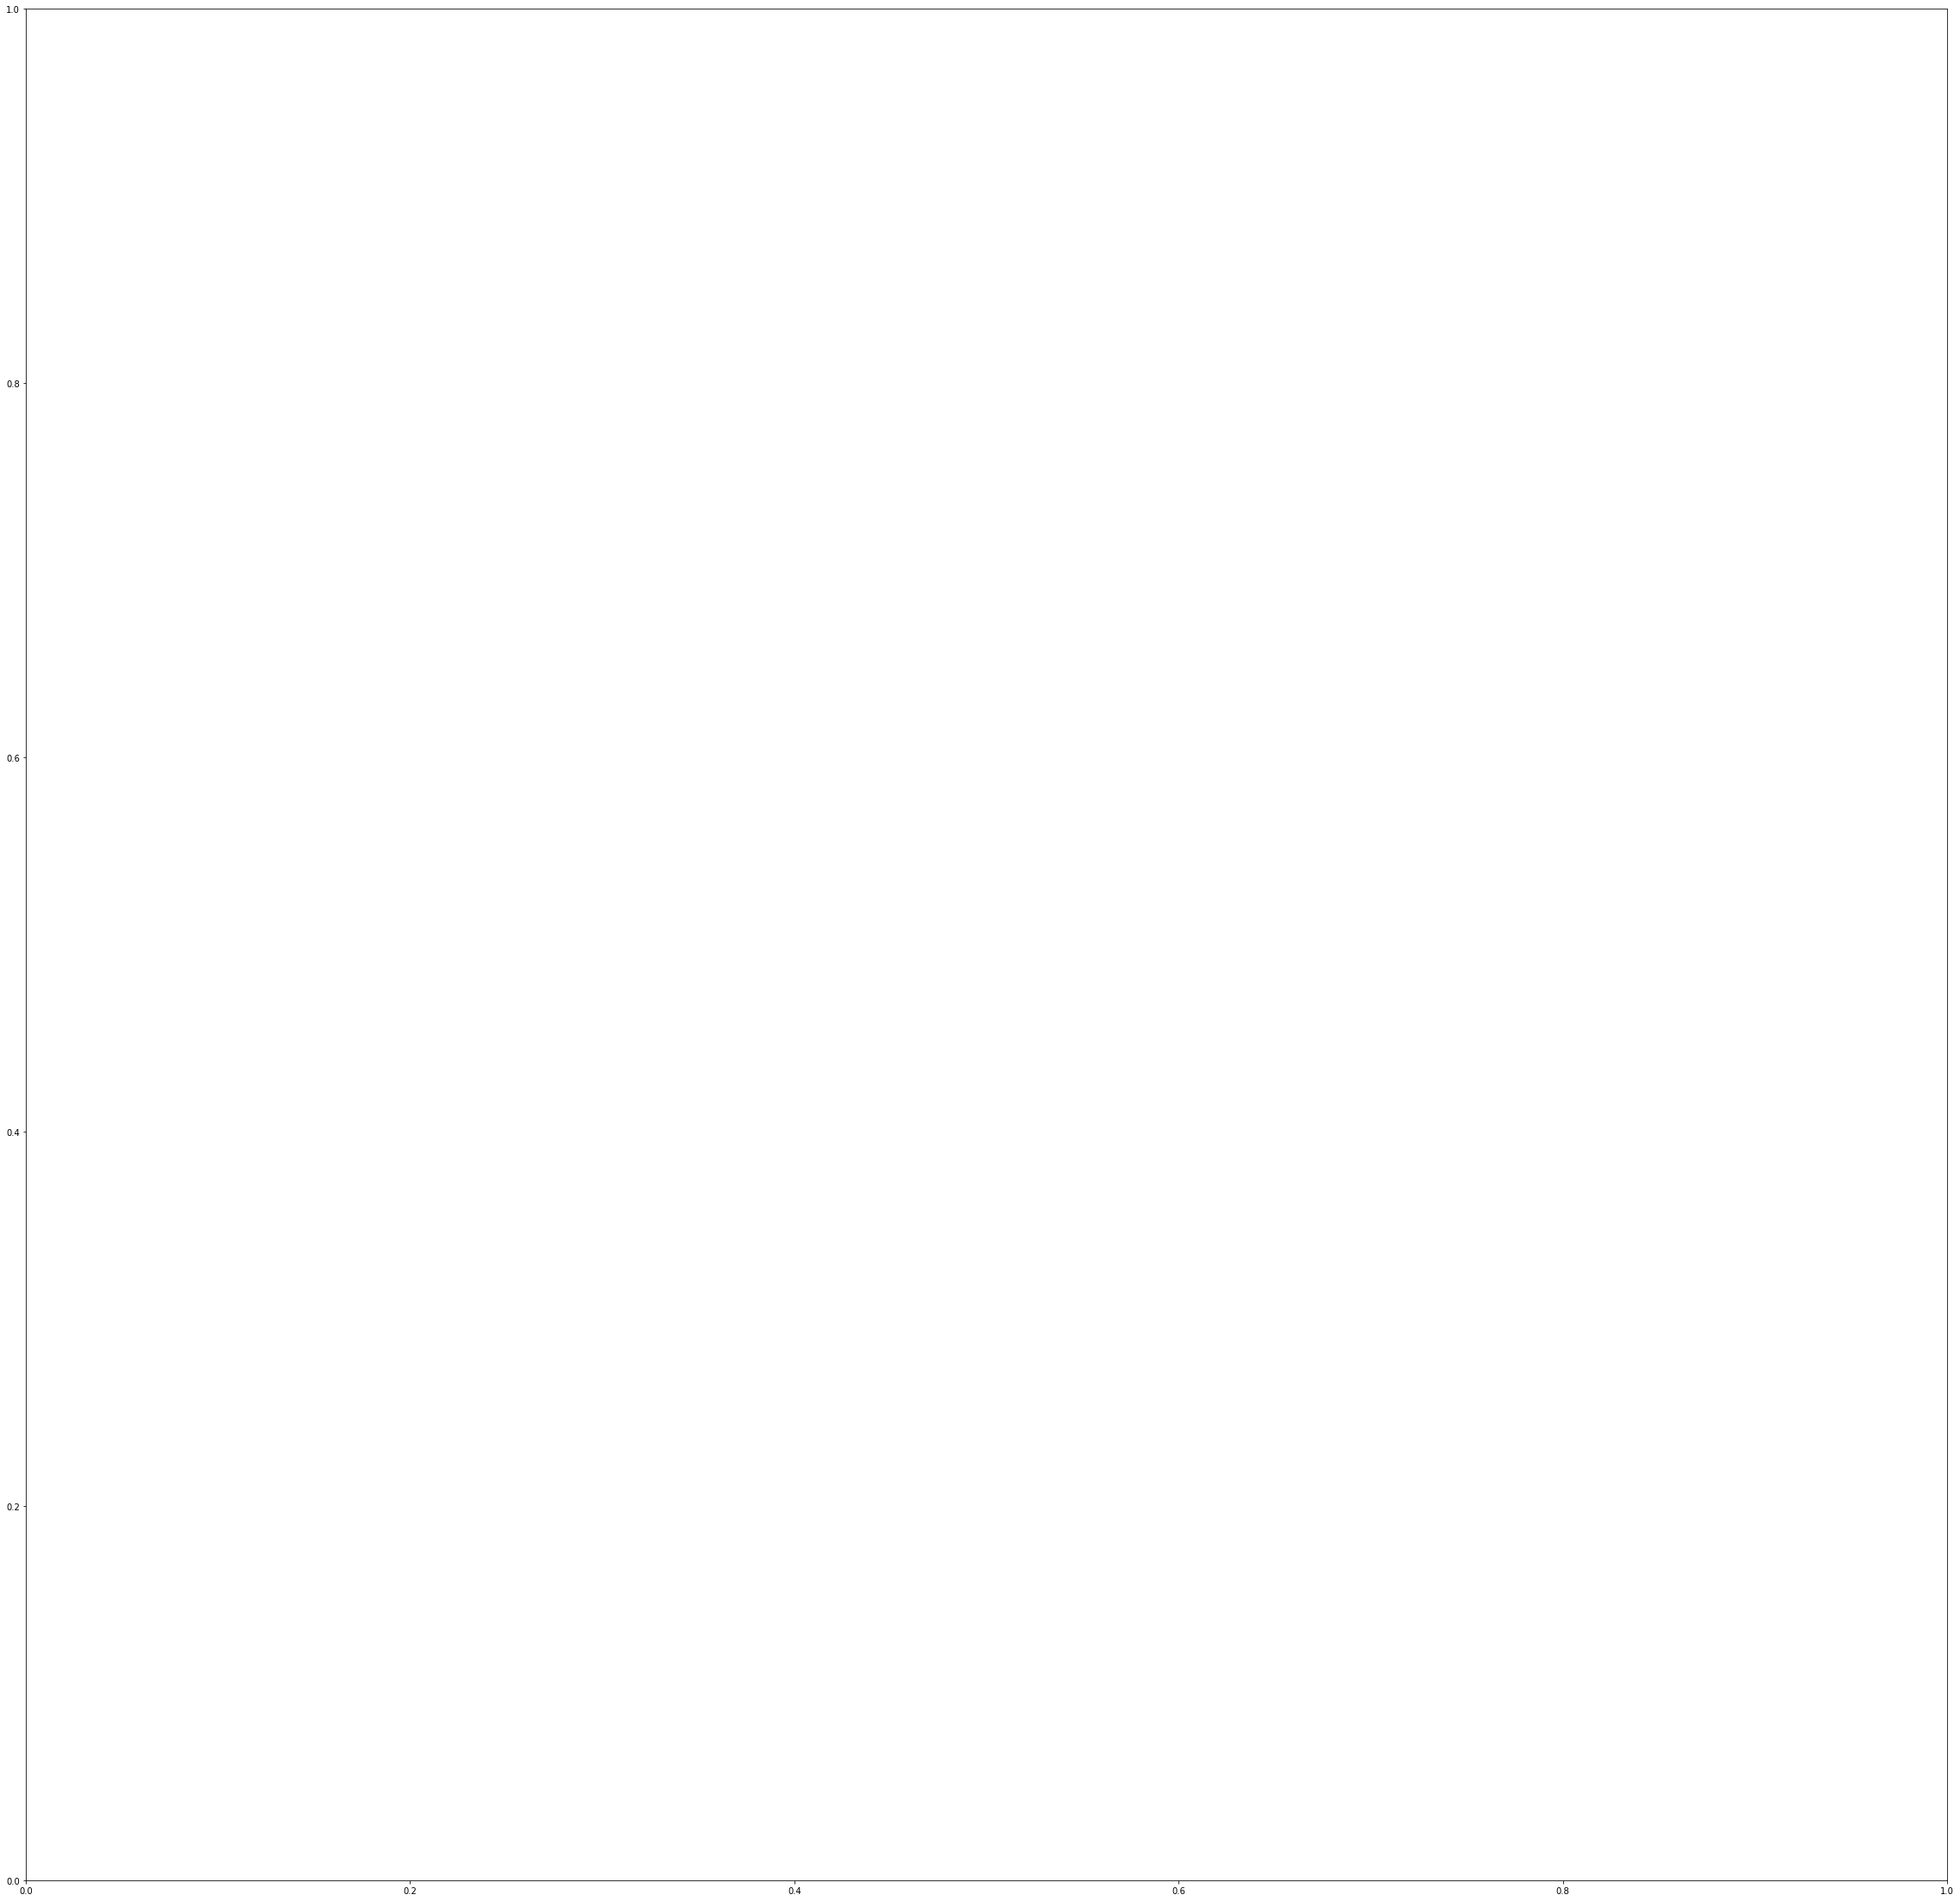

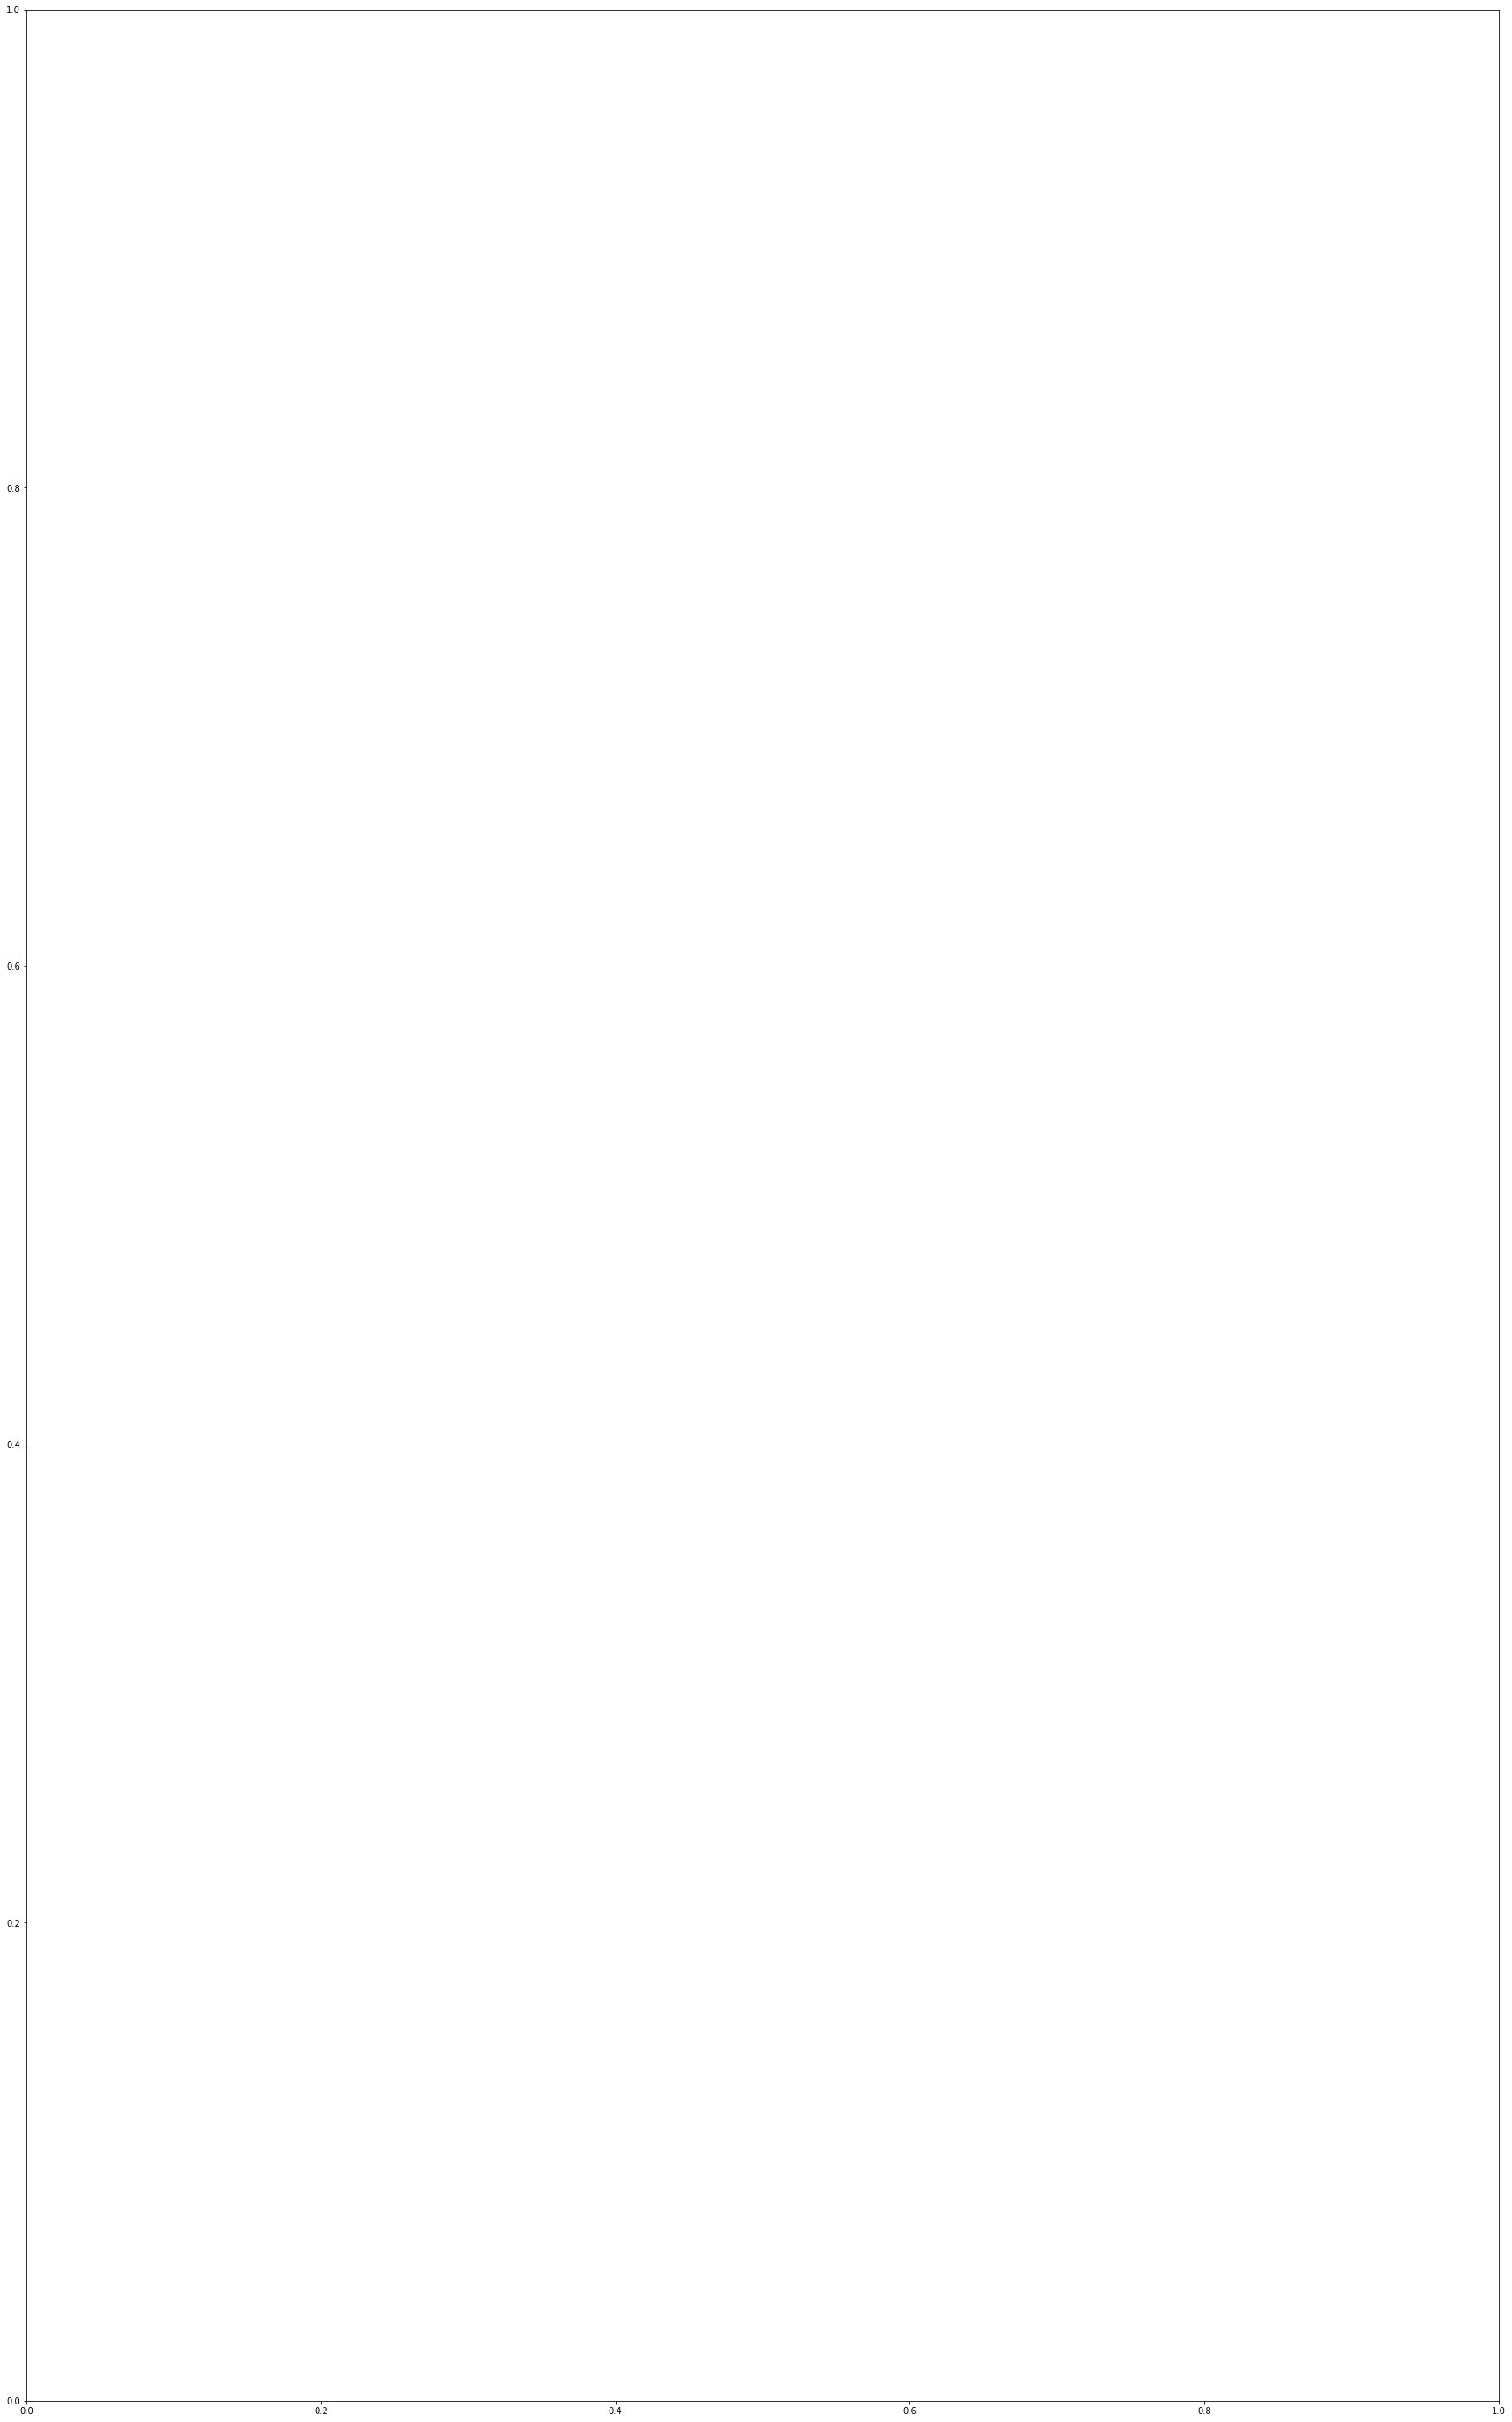

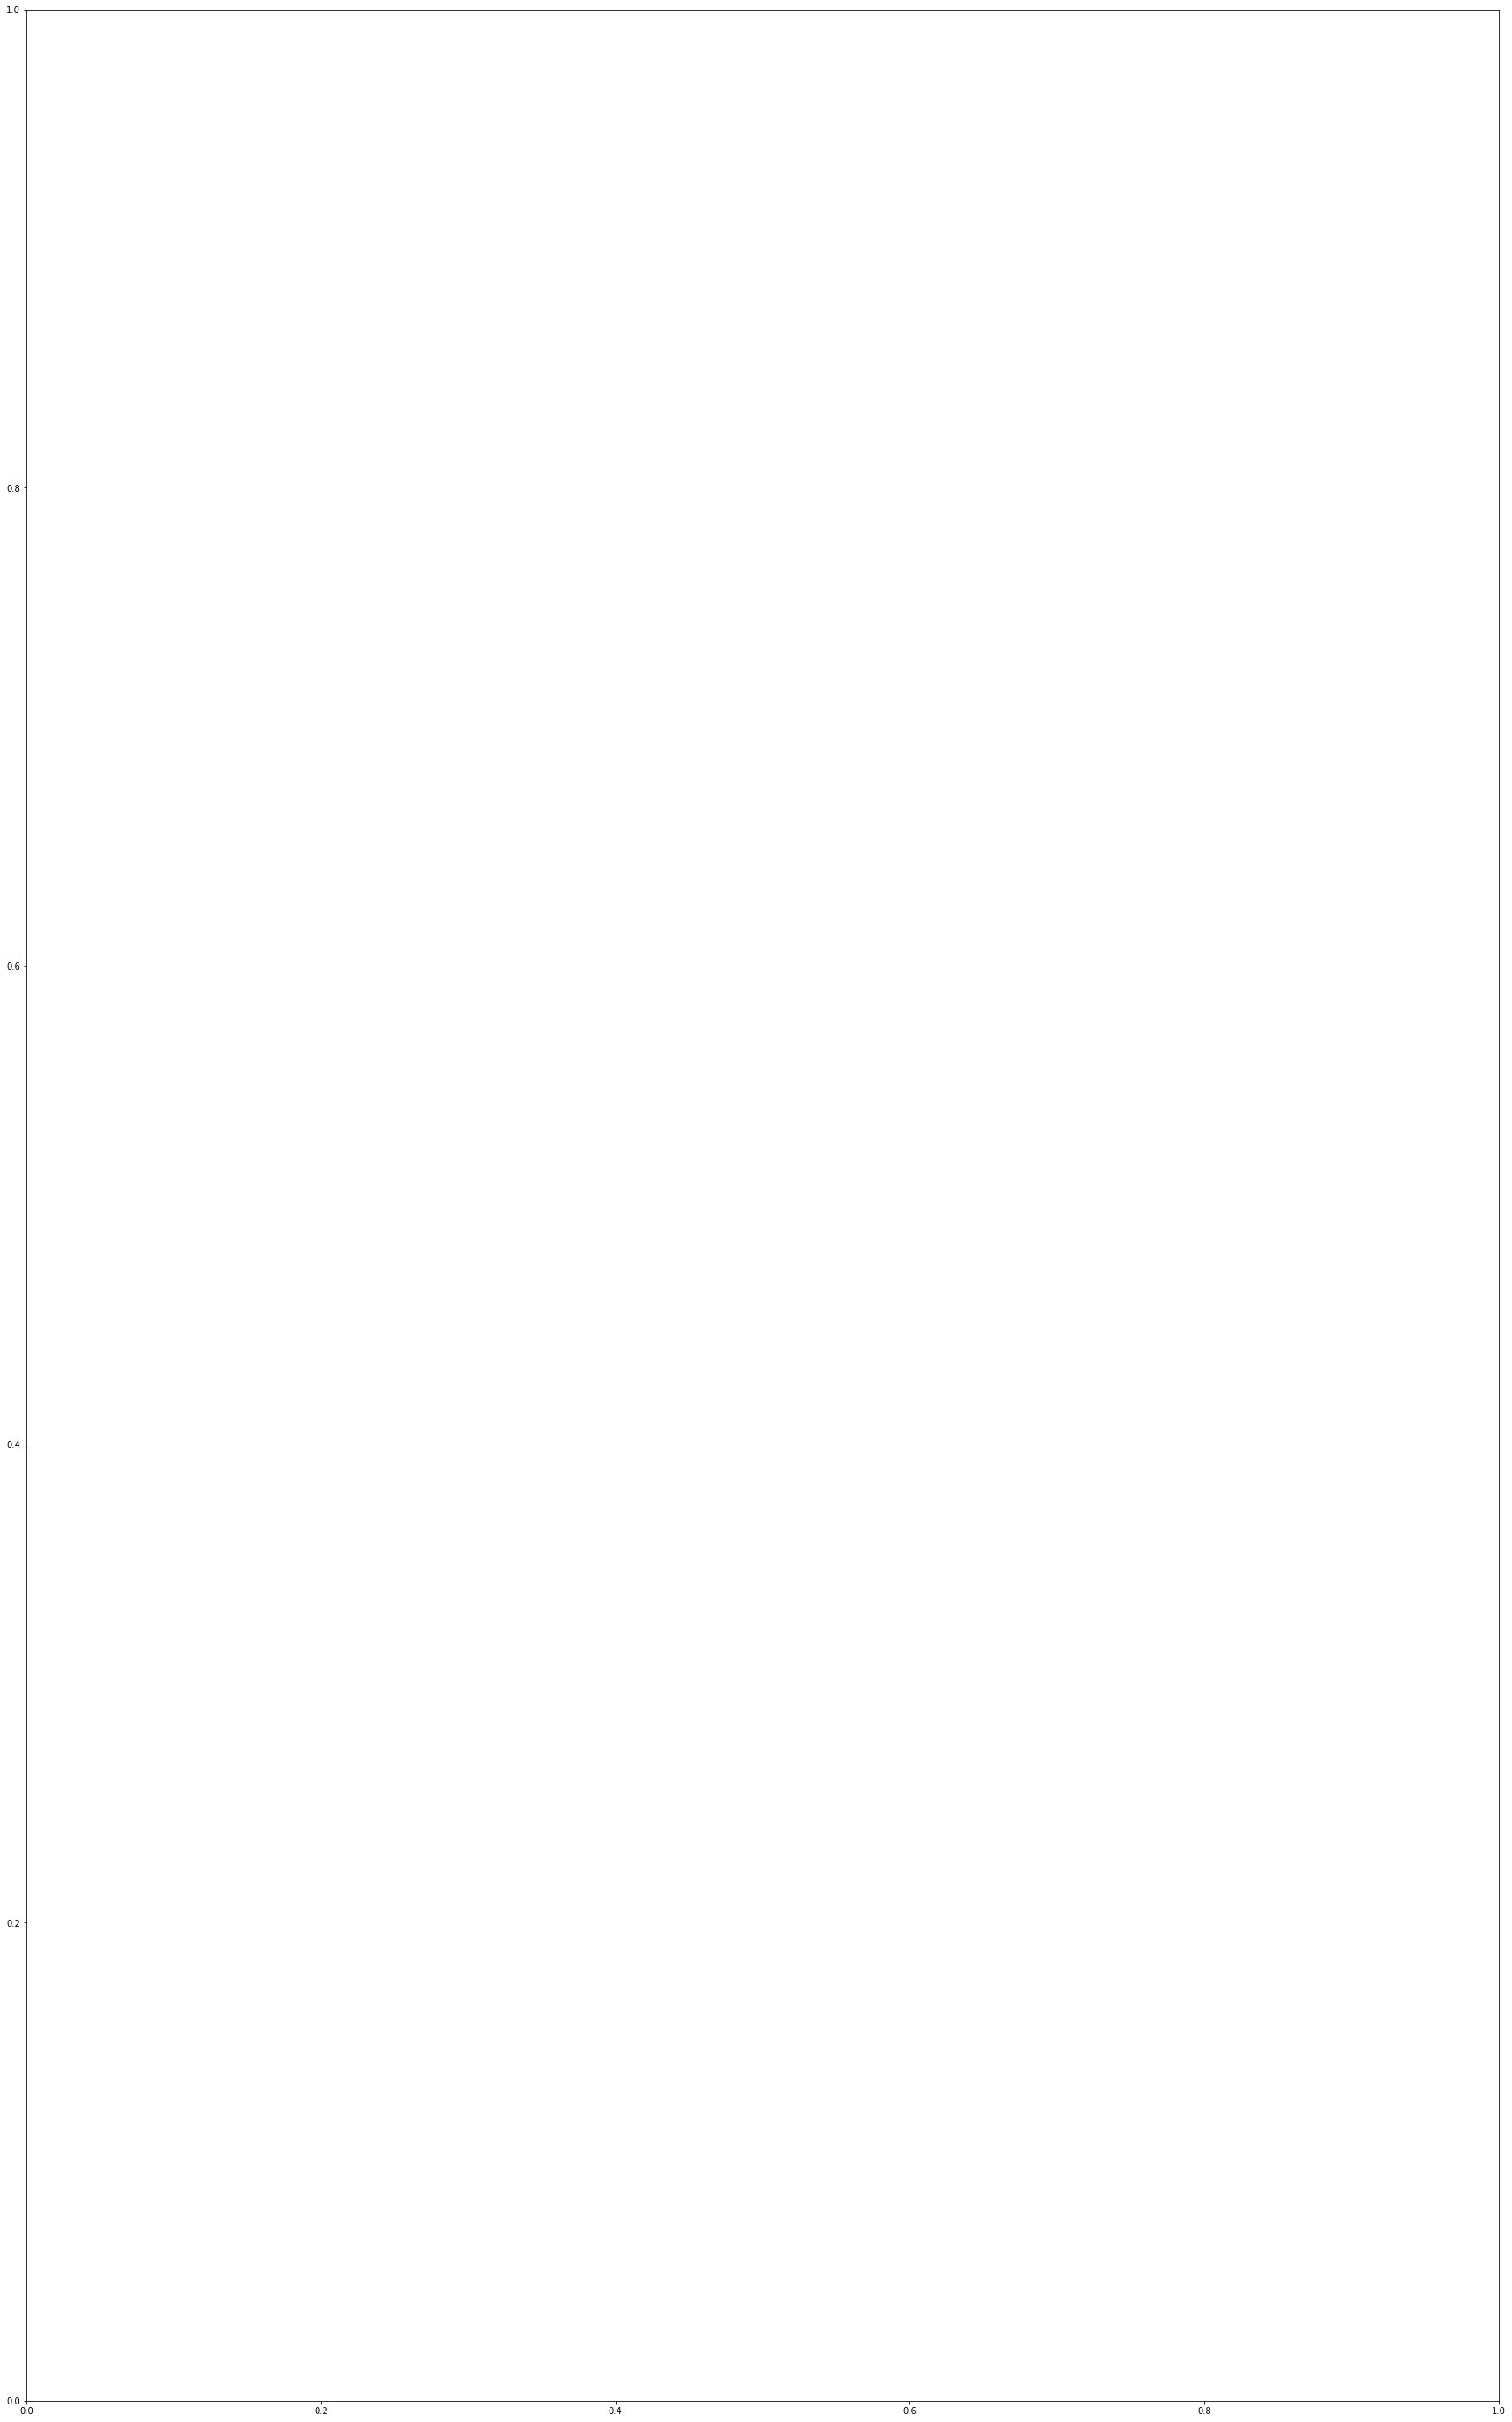

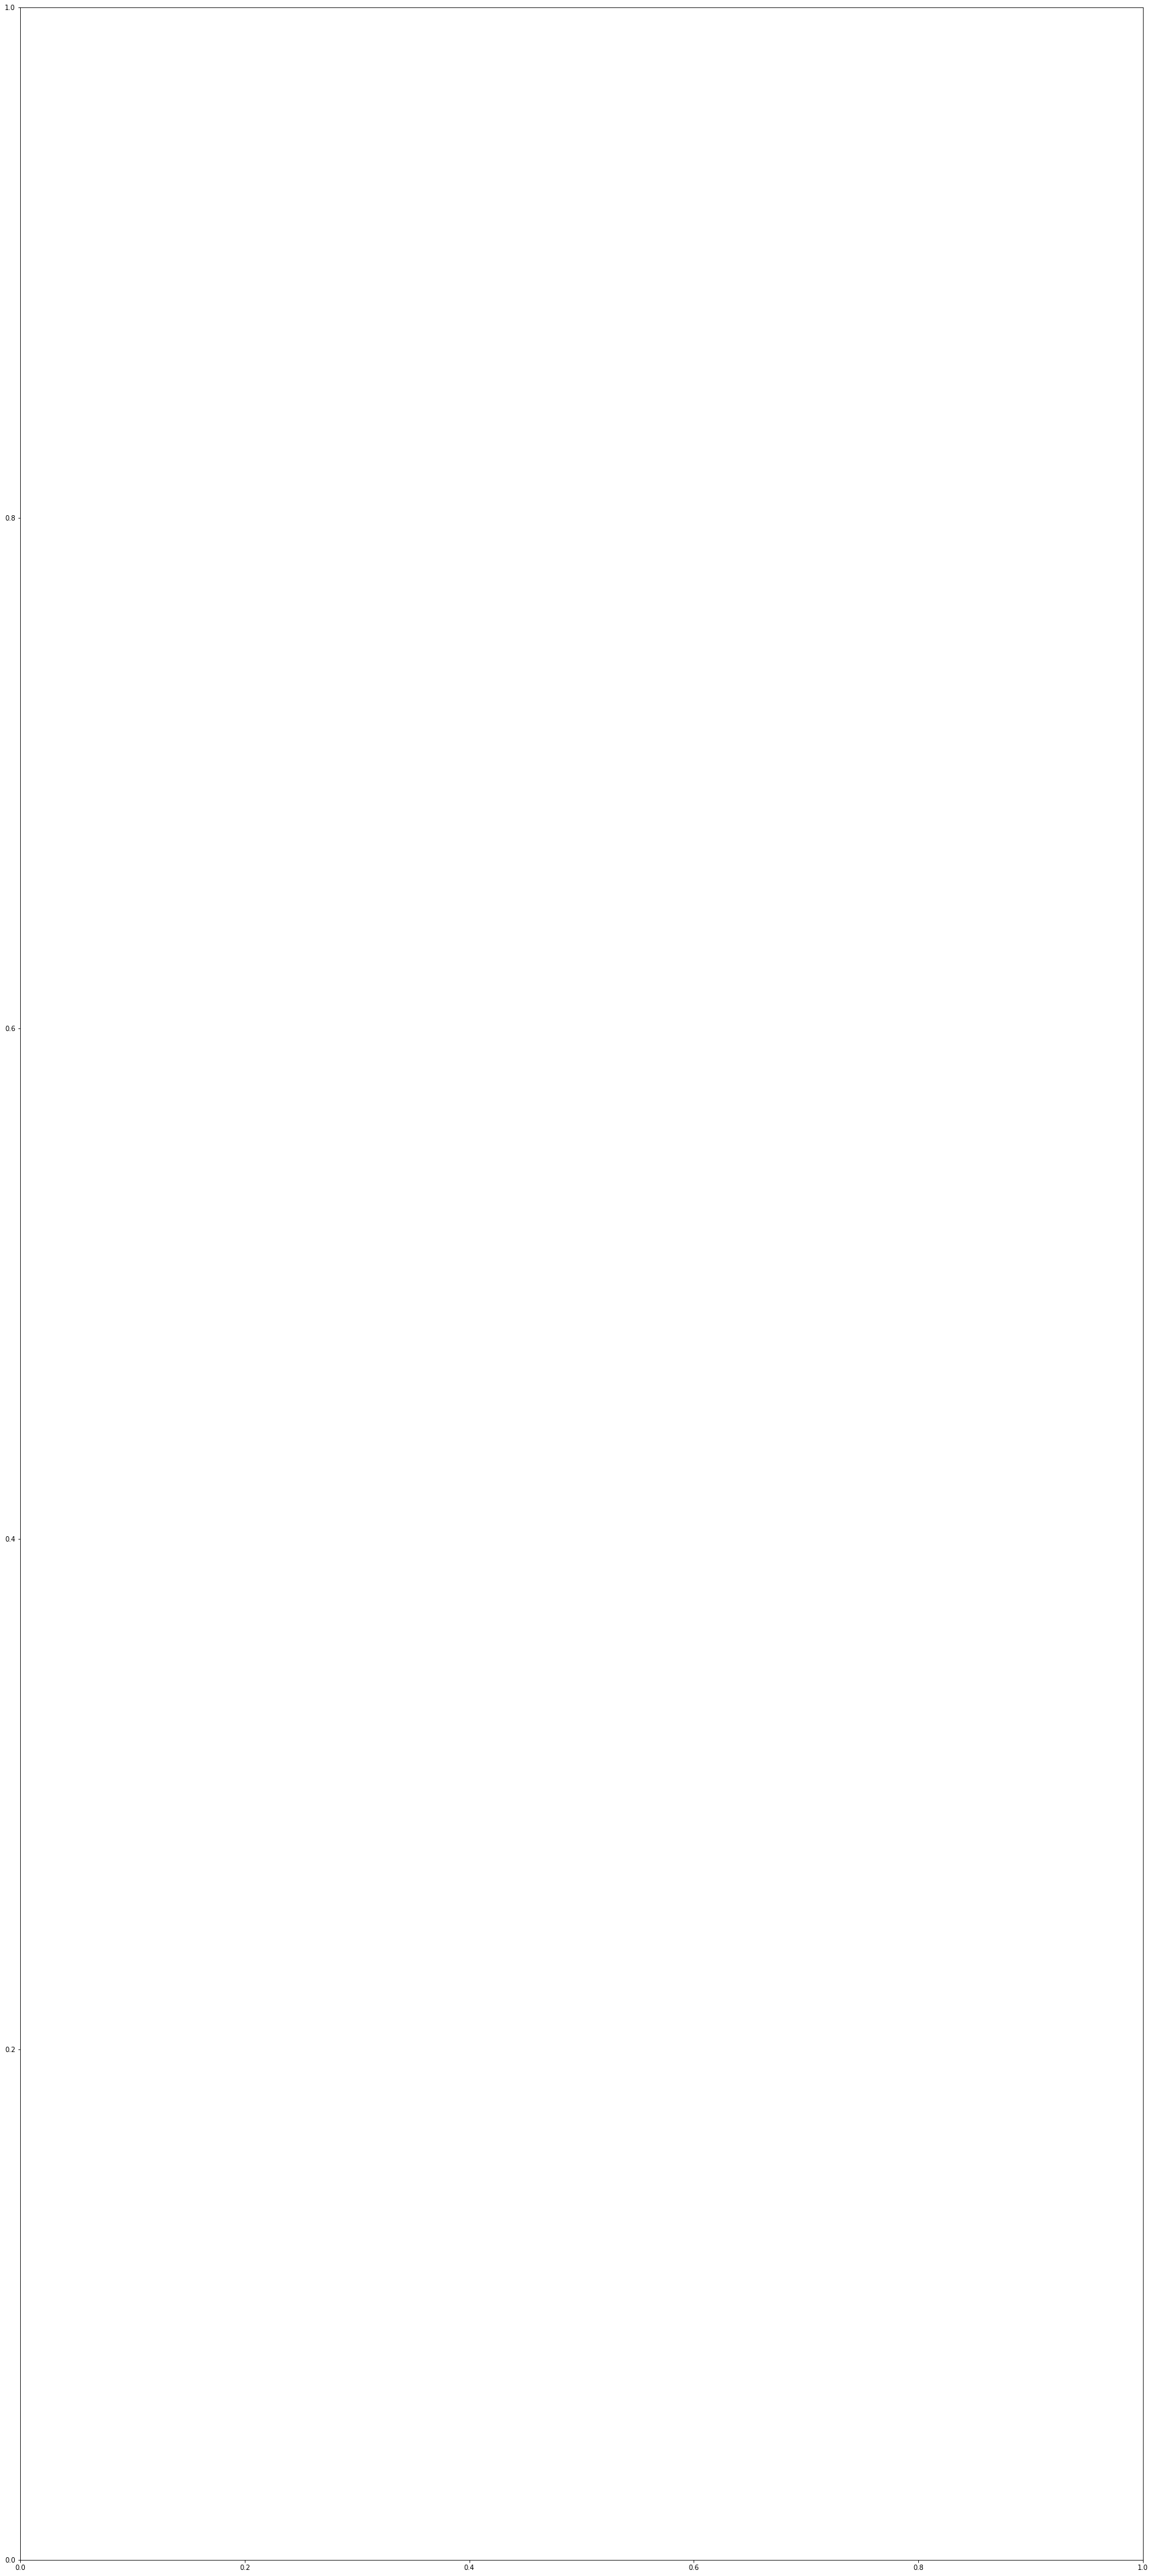

In [21]:
# plot cluster groups without all genotypes
# color by treatment, style by subgenome
# raw TPM
for k in new_cdict.keys():
    plot_set_profile(new_cdict,k,"all")
    plt.clf()
    plt.cla()

In [35]:
pd.DataFrame(new_cdict[1.0])

,55,2AB,G,19,46,1AB,45,18,56,53,48,70,Eudy,13,51,52,37
0,2,2,1,4,5,3,1,4,4,6,1,5,4,4,6,3,2
1,2,1,1,3,3,3,4,4,4,6,6,5,4,4,6,3,3


In [36]:
new_cdict[1.0]

{'55': 2,
 '2AB': [2, 1],
 'G': 1,
 '19': [4, 3],
 '46': [5, 3],
 '1AB': 3,
 '45': [1, 4],
 '18': 4,
 '56': 4,
 '53': 6,
 '48': [1, 6],
 '70': 5,
 'Eudy': 4,
 '13': 4,
 '51': 6,
 '52': 3,
 '37': [2, 3]}

In [37]:
plot.head()

,cluster,genotype,n_CAM_genes,n_all_genes
0,1,53,0,319
1,2,53,1,656
2,3,53,1,882
3,4,53,0,1071
4,5,53,0,428


In [39]:
# make a function to convert new_cdict into a sensible dataframe
## actually, just want to append a column to plot
plot["gtc"] = plot["genotype"]+"_"+plot["cluster"].astype(str)
plot.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc
0,1,53,0,319,53_1
1,2,53,1,656,53_2
2,3,53,1,882,53_3
3,4,53,0,1071,53_4
4,5,53,0,428,53_5


In [41]:
plotc = plot[plot["cluster"]!="Total"]

In [46]:
ztd = {}
# in this dict: key=gt_c, value=ZT of peak
for i in list(plotc["gtc"]):
    gt = i.split("_")[0]
    c = int(i.split("_")[1])
    for k,v in new_cdict.items():
        for j,h in v.items():
            if j==gt:
                if type(h)!=list:
                    if h==c:
                        ztd[i] = k
                elif c in h:
                    ztd[i] = k

In [48]:
plotc["ZTpeak"] = plotc["gtc"].map(ztd)
plotc.head()

/tmp/ipykernel_27384/1373471241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plotc["ZTpeak"] = plotc["gtc"].map(ztd)


,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0,319,53_1,5.0
1,2,53,1,656,53_2,21.0
2,3,53,1,882,53_3,17.0
3,4,53,0,1071,53_4,9.0
4,5,53,0,428,53_5,21.0


In [49]:
plotc.to_csv("./clusters_ngenes_gt_ztgroup.txt",sep="\t",header=True,index=False)

In [77]:
plotc.groupby("ZTpeak").count()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc
ZTpeak,,,,,
1.0,23,23,23,23,23
5.0,15,15,15,15,15
9.0,16,16,16,16,16
13.0,14,14,14,14,14
17.0,15,15,15,15,15
21.0,19,19,19,19,19
